In [ ]:
pip install shap

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])

0

# **Tahap Modeling**

## **Langkah 1: Import Library, Mount Google Drive, dan Setup**

####**Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, gc, json, time, pickle, random, joblib
import psutil
from datetime import datetime
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# Imbalanced-learn (untuk Borderline-SMOTE)
from imblearn.over_sampling import BorderlineSMOTE

# PyTorch untuk CVAE
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# TensorFlow/Keras untuk DNN Classifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Cek GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" PyTorch device: {device}")

# Cek TensorFlow GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" TensorFlow GPU tersedia: {len(gpus)} GPU")
else:
    print(" TensorFlow menggunakan CPU")
print(" Library Deep Learning berhasil di-import")

# Import Library untuk EFI (Ensemble Feature Importance)
# SHAP untuk feature importance
try:
    import shap
    print(" SHAP tersedia")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("SHAP berhasil diinstal.")

print("Library EFI berhasil di-import")


# Import Library Visualisasi
# Scikit-learn untuk dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Scipy untuk statistical tests
from scipy import stats
from scipy.stats import ks_2samp

print("Semua library berhasil diimport.")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")

 PyTorch device: cuda
 TensorFlow GPU tersedia: 1 GPU
 Library Deep Learning berhasil di-import
 SHAP tersedia
Library EFI berhasil di-import
Semua library berhasil diimport.
TensorFlow version : 2.19.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


####**Mount GDrive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


####**Setup Folder/Paths**

In [ ]:
# Baseline Paths (Read-only)
BASELINE_PROCESSED_DIR_IIOT = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Processed_Data/'
BASELINE_RESULTS_DIR_IIOT   = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/'
BASELINE_MODELS_DIR_IIOT    = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Models/'
BASELINE_EDA_DIR_IIOT       = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/'

# Framework Paths(Read-Write)
FRAMEWORK_BASE_DIR_IIOT        = '/content/drive/My Drive/Framework/CICIIoT2025/'
FRAMEWORK_CHECKPOINTS_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/'
FRAMEWORK_MODELS_DIR_IIOT      = '/content/drive/My Drive/Framework/CICIIoT2025/Models/'
FRAMEWORK_RESULTS_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Results/'

# Subdirektori untuk checkpoints
GIR_DIR_IIOT          = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/01_GIR/'
SEGMENTATION_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/'
CAFW_DIR_IIOT         = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/'
CVAE_DIR_IIOT         = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/04_CVAE/'
SMOTE_DIR_IIOT        = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/'
FINAL_DIR_IIOT        = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/'

# Subdirektori untuk results
CONFUSION_MATRIX_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Results/Confusion_Matrices/'
VISUALIZATION_DIR_IIOT    = '/content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/'

# Subdirektori untuk binary ovr
BINARY_BASE_DIR_IIOT    = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/'
BINARY_MODELS_DIR_IIOT  = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/'
BINARY_RESULTS_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/'
BINARY_CM_DIR_IIOT      = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Confusion_Matrices/'
BINARY_VIZ_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/'
BINARY_RF_DIR_IIOT      = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/RandomForest/'
BINARY_XGB_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/XGBoost/'
BINARY_LGB_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/LightGBM/'
BINARY_DNN_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/DNN/'

print("Path variables defined.")

# Membuat Semua Direktori
print("Membuat direktori framework...")

ALL_DIRS = [
    FRAMEWORK_BASE_DIR_IIOT,
    FRAMEWORK_CHECKPOINTS_DIR_IIOT,
    FRAMEWORK_MODELS_DIR_IIOT,
    FRAMEWORK_RESULTS_DIR_IIOT,
    GIR_DIR_IIOT,
    SEGMENTATION_DIR_IIOT,
    CAFW_DIR_IIOT,
    CVAE_DIR_IIOT,
    SMOTE_DIR_IIOT,
    FINAL_DIR_IIOT,
    CONFUSION_MATRIX_DIR_IIOT,
    VISUALIZATION_DIR_IIOT,
    BINARY_BASE_DIR_IIOT,
    BINARY_MODELS_DIR_IIOT,
    BINARY_RESULTS_DIR_IIOT,
    BINARY_CM_DIR_IIOT,
    BINARY_VIZ_DIR_IIOT,
    BINARY_RF_DIR_IIOT,
    BINARY_XGB_DIR_IIOT,
    BINARY_LGB_DIR_IIOT,
    BINARY_DNN_DIR_IIOT,
]

print("\nMembuat folder framework...")
print("-" * 50)
created  = 0
existing = 0
for d in ALL_DIRS:
    if not os.path.exists(d):
        os.makedirs(d)
        print(f"  [CREATED]  {d.split('CICIIoT2025/')[-1]}")
        created += 1
    else:
        print(f"  [EXISTS]   {d.split('CICIIoT2025/')[-1]}")
        existing += 1

print("-" * 50)
print(f"Folder dibuat   : {created}")
print(f"Folder sudah ada: {existing}")
print(f"Total folder    : {len(ALL_DIRS)}")

Path variables defined.
Membuat direktori framework...

Membuat folder framework...
--------------------------------------------------
  [EXISTS]   
  [EXISTS]   Checkpoints/
  [EXISTS]   Models/
  [EXISTS]   Results/
  [EXISTS]   Checkpoints/01_GIR/
  [EXISTS]   Checkpoints/02_Segmentation/
  [EXISTS]   Checkpoints/03_CAFW/
  [EXISTS]   Checkpoints/04_CVAE/
  [EXISTS]   Checkpoints/05_SMOTE/
  [EXISTS]   Checkpoints/06_Final/
  [EXISTS]   Results/Confusion_Matrices/
  [EXISTS]   Results/Visualizations/
  [EXISTS]   Binary/
  [EXISTS]   Binary/Models/
  [EXISTS]   Binary/Results/
  [EXISTS]   Binary/Results/Confusion_Matrices/
  [EXISTS]   Binary/Results/Visualizations/
  [EXISTS]   Binary/Models/RandomForest/
  [EXISTS]   Binary/Models/XGBoost/
  [EXISTS]   Binary/Models/LightGBM/
  [EXISTS]   Binary/Models/DNN/
--------------------------------------------------
Folder dibuat   : 0
Folder sudah ada: 21
Total folder    : 21


####**Setup Reproducibility (Seed)**

In [ ]:
# Definisi seed
SEED = 42

# Python random
import random
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Untuk multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# TensorFlow
tf.random.set_seed(SEED)

print(f" Semua random seeds diset ke: {SEED}")
print(" Reproducibility terjamin!")

 Semua random seeds diset ke: 42
 Reproducibility terjamin!


####**Definisi Label dan Mapping**

In [ ]:
LABEL_NAMES_IIOT = {
    0: 'Benign',
    1: 'Brute_Force',
    2: 'DDoS',
    3: 'DoS',
    4: 'MITM/Spoofing',
    5: 'Malware/Mirai',
    6: 'Recon',
    7: 'Web_Based'
}
NAME_TO_ENC_IIOT = {v: k for k, v in LABEL_NAMES_IIOT.items()}

CATEGORY_MAPPING_IIOT = {
    'Benign'        : ['benign'],
    'Brute_Force'   : ['bruteforce'],
    'DDoS'          : ['ddos'],
    'DoS'           : ['dos'],
    'MITM/Spoofing' : ['mitm'],
    'Malware/Mirai' : ['malware'],
    'Recon'         : ['recon'],
    'Web_Based'     : ['web']
}

N_CLASSES  = 8
N_FEATURES = 71

print("\nLabel mapping:")
print("-" * 40)
for enc, name in LABEL_NAMES_IIOT.items():
    print(f"  {enc} : {name}")


Label mapping:
----------------------------------------
  0 : Benign
  1 : Brute_Force
  2 : DDoS
  3 : DoS
  4 : MITM/Spoofing
  5 : Malware/Mirai
  6 : Recon
  7 : Web_Based


####**Verifikasi Baseline Files dan Informasi Sistem**

In [ ]:
print("\nVerifikasi baseline files...")
print("-" * 50)

baseline_files = {
    'X_train.npy'       : 'X_train',
    'X_test.npy'        : 'X_test',
    'y_train.npy'       : 'y_train',
    'y_test.npy'        : 'y_test',
    'scaler.pkl'        : 'Scaler',
    'label_encoder.pkl' : 'Label Encoder',
    'feature_names.json': 'Feature Names'
}

all_ok = True
for fname, label in baseline_files.items():
    fpath  = BASELINE_PROCESSED_DIR_IIOT + fname
    exists = os.path.exists(fpath)
    size   = f"{os.path.getsize(fpath)/1024/1024:.2f} MB" if exists else "N/A"
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {label:<16} | {fname:<22} | {size}")
    if not exists:
        all_ok = False

print("-" * 50)
if all_ok:
    print("Semua baseline files tersedia. Siap untuk Langkah 2.")
else:
    print("PERINGATAN: Ada baseline file yang tidak ditemukan.")

print("Informasi Sistem...")

# RAM
mem = psutil.virtual_memory()
print(f"\n RAM Sistem:")
print(f"  Total     : {mem.total / (1024**3):.2f} GB")
print(f"  Available : {mem.available / (1024**3):.2f} GB")
print(f"  Used      : {mem.used / (1024**3):.2f} GB ({mem.percent}%)")

# GPU (PyTorch)
if torch.cuda.is_available():
    print(f"\n GPU (PyTorch):")
    print(f"  Device Name : {torch.cuda.get_device_name(0)}")
    print(f"  Memory Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

# GPU (TensorFlow)
if gpus:
    print(f"\n GPU (TensorFlow):")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")

# Summary Langkah 1
print("\n" + "=" * 50)
print("Langkah 1 selesai.")
print("=" * 50)
print(f"Dataset    : CIC IIoT 2025")
print(f"N classes  : {N_CLASSES}")
print(f"N features : {N_FEATURES}")
print(f"Seed       : {SEED}")
print("Lanjut ke Langkah 2: Load Data + Validasi Distribusi")
print("=" * 50)


Verifikasi baseline files...
--------------------------------------------------
  [OK] X_train          | X_train.npy            | 209.24 MB
  [OK] X_test           | X_test.npy             | 24.55 MB
  [OK] y_train          | y_train.npy            | 2.95 MB
  [OK] y_test           | y_test.npy             | 0.35 MB
  [OK] Scaler           | scaler.pkl             | 0.00 MB
  [OK] Label Encoder    | label_encoder.pkl      | 0.00 MB
  [OK] Feature Names    | feature_names.json     | 0.00 MB
--------------------------------------------------
Semua baseline files tersedia. Siap untuk Langkah 2.
Informasi Sistem...

 RAM Sistem:
  Total     : 50.99 GB
  Available : 47.94 GB
  Used      : 2.45 GB (6.0%)

 GPU (PyTorch):
  Device Name : Tesla T4
  Memory Total: 14.56 GB

 GPU (TensorFlow):
  GPU 0: /physical_device:GPU:0

Langkah 1 selesai.
Dataset    : CIC IIoT 2025
N classes  : 8
N features : 71
Seed       : 42
Lanjut ke Langkah 2: Load Data + Validasi Distribusi


##**Langkah 2: Load Data Baseline**

####**2.1 Load Pre-Processed Data dari Model Baseline**

2.1.1 Load Data dari Baseline

In [ ]:
print("Memuat data dari baseline...")
print("-" * 50)

X_train = np.load(BASELINE_PROCESSED_DIR_IIOT + 'X_train.npy')
print(f"X_train loaded  : {X_train.shape}")

X_test = np.load(BASELINE_PROCESSED_DIR_IIOT + 'X_test.npy')
print(f"X_test loaded   : {X_test.shape}")

y_train = np.load(BASELINE_PROCESSED_DIR_IIOT + 'y_train.npy')
print(f"y_train loaded  : {y_train.shape}")

y_test = np.load(BASELINE_PROCESSED_DIR_IIOT + 'y_test.npy')
print(f"y_test loaded   : {y_test.shape}")

Memuat data dari baseline...
--------------------------------------------------
X_train loaded  : (386274, 71)
X_test loaded   : (45319, 71)
y_train loaded  : (386274,)
y_test loaded   : (45319,)


2.1.2 Load Nama Fitur

In [ ]:
with open(BASELINE_PROCESSED_DIR_IIOT + 'feature_names.json', 'r') as f:
    feature_names = json.load(f)

print(f"\nFeature names loaded : {len(feature_names)} features")
print(f"Contoh fitur pertama : {feature_names[:5]}")
print(f"Contoh fitur terakhir: {feature_names[-5:]}")


Feature names loaded : 71 features
Contoh fitur pertama : ['log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation', 'log_data-types_count']
Contoh fitur terakhir: ['network_ttl_std_deviation', 'network_window-size_avg', 'network_window-size_max', 'network_window-size_min', 'network_window-size_std_deviation']


2.1.3 Load Scaler dan Label Encoder

In [ ]:
with open(BASELINE_PROCESSED_DIR_IIOT + 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(BASELINE_PROCESSED_DIR_IIOT + 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print(f"\nScaler loaded        : {type(scaler).__name__}")
print(f"Label encoder loaded : {type(label_encoder).__name__}")


Scaler loaded        : StandardScaler
Label encoder loaded : LabelEncoder


####**2.2 Validasi Data**

2.2.1 Validasi Dimensi Data

In [ ]:
print("\nValidasi dimensi data...")
print("-" * 50)

assert X_train.shape[1] == N_FEATURES, \
    f"ERROR: X_train features {X_train.shape[1]} != {N_FEATURES}"
assert X_test.shape[1] == N_FEATURES, \
    f"ERROR: X_test features {X_test.shape[1]} != {N_FEATURES}"
assert X_train.shape[0] == y_train.shape[0], \
    f"ERROR: X_train rows {X_train.shape[0]} != y_train {y_train.shape[0]}"
assert X_test.shape[0] == y_test.shape[0], \
    f"ERROR: X_test rows {X_test.shape[0]} != y_test {y_test.shape[0]}"
assert len(feature_names) == N_FEATURES, \
    f"ERROR: feature_names length {len(feature_names)} != {N_FEATURES}"

print(f"X_train shape   : {X_train.shape}  -> OK")
print(f"X_test shape    : {X_test.shape}   -> OK")
print(f"y_train shape   : {y_train.shape}  -> OK")
print(f"y_test shape    : {y_test.shape}   -> OK")
print(f"Feature names   : {len(feature_names)}          -> OK")


Validasi dimensi data...
--------------------------------------------------
X_train shape   : (386274, 71)  -> OK
X_test shape    : (45319, 71)   -> OK
y_train shape   : (386274,)  -> OK
y_test shape    : (45319,)   -> OK
Feature names   : 71          -> OK


2.2.2 Validasi Label Encoding

In [ ]:
print("\nValidasi label encoding...")
print("-" * 50)

unique_train = np.unique(y_train)
unique_test  = np.unique(y_test)

print(f"Unique labels train : {unique_train}")
print(f"Unique labels test  : {unique_test}")

assert len(unique_train) == N_CLASSES, \
    f"ERROR: jumlah kelas train {len(unique_train)} != {N_CLASSES}"
assert len(unique_test) == N_CLASSES, \
    f"ERROR: jumlah kelas test {len(unique_test)} != {N_CLASSES}"

print("Semua label valid   : OK")


Validasi label encoding...
--------------------------------------------------
Unique labels train : [0 1 2 3 4 5 6 7]
Unique labels test  : [0 1 2 3 4 5 6 7]
Semua label valid   : OK


2.2.3 Validasi NaN dan Inf

In [ ]:
print("\nValidasi NaN dan Inf...")
print("-" * 50)

nan_train = np.isnan(X_train).sum()
nan_test  = np.isnan(X_test).sum()
inf_train = np.isinf(X_train).sum()
inf_test  = np.isinf(X_test).sum()

print(f"NaN X_train  : {nan_train}")
print(f"NaN X_test   : {nan_test}")
print(f"Inf X_train  : {inf_train}")
print(f"Inf X_test   : {inf_test}")

if nan_train + nan_test + inf_train + inf_test == 0:
    print("Data bersih dari NaN dan Inf : OK")
else:
    print("PERINGATAN: Ditemukan NaN atau Inf, perlu penanganan tambahan.")


Validasi NaN dan Inf...
--------------------------------------------------
NaN X_train  : 0
NaN X_test   : 0
Inf X_train  : 0
Inf X_test   : 0
Data bersih dari NaN dan Inf : OK


####**2.3 Cek Distribusi Kelas**

2.3.1 Distribusi Kelas - Train Set

In [ ]:
print("\nDistribusi kelas - Train set:")
print("-" * 55)

total_train = len(y_train)
counts_train = {}
for enc, name in LABEL_NAMES_IIOT.items():
    count = np.sum(y_train == enc)
    pct   = count / total_train * 100
    counts_train[name] = count
    print(f"  {enc} | {name:<16} | {count:>7,} | {pct:>6.2f}%")

print("-" * 55)
print(f"  Total train        : {total_train:>7,}")


Distribusi kelas - Train set:
-------------------------------------------------------
  0 | Benign           | 163,578 |  42.35%
  1 | Brute_Force      |   4,055 |   1.05%
  2 | DDoS             |  45,744 |  11.84%
  3 | DoS              |  49,107 |  12.71%
  4 | MITM/Spoofing    |  20,799 |   5.38%
  5 | Malware/Mirai    |  20,195 |   5.23%
  6 | Recon            |  76,067 |  19.69%
  7 | Web_Based        |   6,729 |   1.74%
-------------------------------------------------------
  Total train        : 386,274


2.3.2 Distribusi Kelas - Test Set

In [ ]:
print("\nDistribusi kelas - Test set:")
print("-" * 55)

total_test = len(y_test)
counts_test = {}
for enc, name in LABEL_NAMES_IIOT.items():
    count = np.sum(y_test == enc)
    pct   = count / total_test * 100
    counts_test[name] = count
    print(f"  {enc} | {name:<16} | {count:>7,} | {pct:>6.2f}%")

print("-" * 55)
print(f"  Total test         : {total_test:>7,}")


Distribusi kelas - Test set:
-------------------------------------------------------
  0 | Benign           |  15,734 |  34.72%
  1 | Brute_Force      |     571 |   1.26%
  2 | DDoS             |   6,097 |  13.45%
  3 | DoS              |   6,362 |  14.04%
  4 | MITM/Spoofing    |   2,750 |   6.07%
  5 | Malware/Mirai    |   2,773 |   6.12%
  6 | Recon            |  10,096 |  22.28%
  7 | Web_Based        |     936 |   2.07%
-------------------------------------------------------
  Total test         :  45,319


2.3.3 Imbalance Ratio

In [ ]:
print("\nAnalisis imbalance ratio - Train set:")
print("-" * 50)

max_class     = max(counts_train, key=counts_train.get)
min_class     = min(counts_train, key=counts_train.get)
max_count     = counts_train[max_class]
min_count     = counts_train[min_class]
imbalance_ratio = max_count / min_count

print(f"Kelas terbesar  : {max_class} ({max_count:,})")
print(f"Kelas terkecil  : {min_class} ({min_count:,})")
print(f"Imbalance ratio : 1:{imbalance_ratio:.1f}")


Analisis imbalance ratio - Train set:
--------------------------------------------------
Kelas terbesar  : Benign (163,578)
Kelas terkecil  : Brute_Force (4,055)
Imbalance ratio : 1:40.3


2.3.4 Verifikasi Time-Based Split (No Overlap)

In [ ]:
print("\nVerifikasi time-based split...")
print("-" * 50)

# Cek overlap berdasarkan data values (bukan index)
# Representasi sebagai set of tuples untuk cek identik
print("Mengecek overlap antara train dan test set...")
sample_size = min(10000, len(X_train), len(X_test))
X_train_sample = set(map(tuple, X_train[:sample_size]))
X_test_sample  = set(map(tuple, X_test[:sample_size]))
overlap        = X_train_sample.intersection(X_test_sample)

print(f"Sample yang dicek : {sample_size:,} dari masing-masing set")
print(f"Overlap ditemukan : {len(overlap)}")
if len(overlap) == 0:
    print("Verifikasi split  : OK (tidak ada data leakage)")
else:
    print(f"PERINGATAN        : {len(overlap)} sampel overlap terdeteksi")


Verifikasi time-based split...
--------------------------------------------------
Mengecek overlap antara train dan test set...
Sample yang dicek : 10,000 dari masing-masing set
Overlap ditemukan : 0
Verifikasi split  : OK (tidak ada data leakage)


2.3.5 Visualisasi Distribusi Kelas


Membuat visualisasi distribusi kelas...


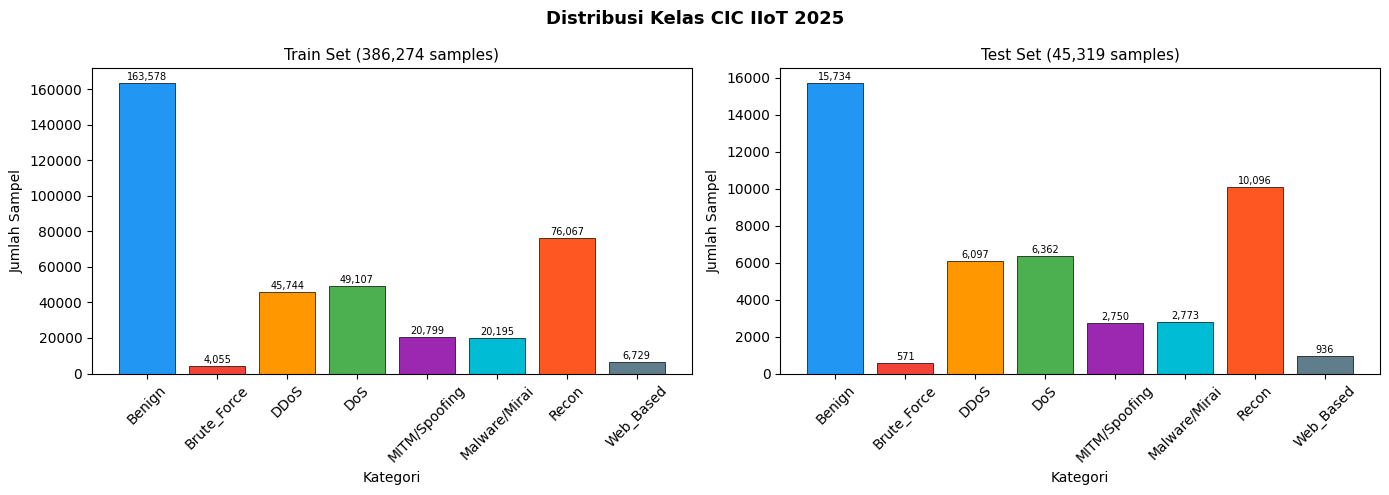

Visualisasi disimpan : /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/distribusi_kelas_iiot2025.png


In [ ]:
print("\nMembuat visualisasi distribusi kelas...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kelas CIC IIoT 2025', fontsize=13, fontweight='bold')

colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50',
          '#9C27B0', '#00BCD4', '#FF5722', '#607D8B']

# Train set
names_list  = list(counts_train.keys())
counts_list = list(counts_train.values())
bars = axes[0].bar(names_list, counts_list, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Train Set (386,274 samples)', fontsize=11)
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}', ha='center', va='bottom', fontsize=7)

# Test set
names_list_t  = list(counts_test.keys())
counts_list_t = list(counts_test.values())
bars2 = axes[1].bar(names_list_t, counts_list_t, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Test Set (45,319 samples)', fontsize=11)
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars2, counts_list_t):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
viz_path = VISUALIZATION_DIR_IIOT + 'distribusi_kelas_iiot2025.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualisasi disimpan : {viz_path}")

####**Ringkasan**

In [ ]:
distribusi_summary = {
    'train': {
        'total'  : int(total_train),
        'counts' : {k: int(v) for k, v in counts_train.items()},
        'percent': {k: round(v/total_train*100, 2) for k, v in counts_train.items()}
    },
    'test': {
        'total'  : int(total_test),
        'counts' : {k: int(v) for k, v in counts_test.items()},
        'percent': {k: round(v/total_test*100, 2) for k, v in counts_test.items()}
    },
    'imbalance_ratio': round(imbalance_ratio, 2),
    'max_class'      : max_class,
    'min_class'      : min_class
}

summary_path = FRAMEWORK_RESULTS_DIR_IIOT + 'distribusi_summary.json'
with open(summary_path, 'w') as f:
    json.dump(distribusi_summary, f, indent=4)

print(f"\nRingkasan distribusi disimpan : {summary_path}")

# Summary Langkah 2
print("\n" + "=" * 50)
print("Langkah 2 selesai.")
print("=" * 50)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Fitur   : {len(feature_names)}")
print(f"Kelas   : {N_CLASSES}")
print(f"Imbalance ratio : 1:{imbalance_ratio:.1f}")
print("Lanjut ke Langkah 3: Dynamic Threshold GIR")
print("=" * 50)


Ringkasan distribusi disimpan : /content/drive/My Drive/Framework/CICIIoT2025/Results/distribusi_summary.json

Langkah 2 selesai.
X_train : (386274, 71)
X_test  : (45319, 71)
y_train : (386274,)
y_test  : (45319,)
Fitur   : 71
Kelas   : 8
Imbalance ratio : 1:40.3
Lanjut ke Langkah 3: Dynamic Threshold GIR


## **Langkah 3: Dynamic Threshold GIR (DT-GIR) Calculation**

####**3.1 Perhitungan GIR Per Kategori**

In [ ]:
print("GIR Formula:")
print("Rumus: GIR_i = (w_maj * n_maj) / (w_min * n_i)")
print("w_maj = 1 -> tidak memberi bobot tambahan ke mayoritas")
print("w_min = 2 -> prioritas 2x ke kelas minoritas")
print("n_maj = jumlah sampel kelas terbesar di train set")
print("n_i   = jumlah sampel kelas ke-i di train set")

W_MAJ = 1.0
W_MIN = 2.0
n_maj = max(counts_train.values())
cat_maj = max(counts_train, key=counts_train.get)

print(f"\nParameter GIR:")
print(f"  w_maj        = {W_MAJ}")
print(f"  w_min        = {W_MIN}")
print(f"  n_majoritas  = {n_maj:,} ({cat_maj})")

gir_rows = []
for name, count in counts_train.items():
    gir     = (W_MAJ * n_maj) / (W_MIN * count)
    log_gir = np.log10(gir)
    gir_rows.append({
        'Kategori'   : name,
        'Train_Count': count,
        'Train_Pct'  : count / total_train * 100,
        'GIR'        : round(gir, 4),
        'Log_GIR'    : round(log_gir, 4),
    })

gir_df = pd.DataFrame(gir_rows).sort_values('GIR', ascending=True).reset_index(drop=True)

print(f"\nNilai GIR per Kategori (diurutkan dari kecil ke besar):")
print(f"\n  {'No':<4} {'Kategori':<18} {'Train Count':>12} {'Train %':>9} {'GIR':>10} {'Log10(GIR)':>11}")
print(f"  {'-'*4} {'-'*18} {'-'*12} {'-'*9} {'-'*10} {'-'*11}")
for i, row in gir_df.iterrows():
    print(f"  {i:<4} {row['Kategori']:<18} {row['Train_Count']:>12,} "
          f"{row['Train_Pct']:>8.4f}% {row['GIR']:>10.4f} {row['Log_GIR']:>11.4f}")

print(f"\nRentang GIR:")
print(f"  GIR minimum  : {gir_df['GIR'].min():.4f} ({gir_df.iloc[0]['Kategori']})")
print(f"  GIR maksimum : {gir_df['GIR'].max():.4f} ({gir_df.iloc[-1]['Kategori']})")
print(f"  Rasio max/min: {gir_df['GIR'].max() / gir_df['GIR'].min():.1f}x")

GIR Formula:
Rumus: GIR_i = (w_maj * n_maj) / (w_min * n_i)
w_maj = 1 -> tidak memberi bobot tambahan ke mayoritas
w_min = 2 -> prioritas 2x ke kelas minoritas
n_maj = jumlah sampel kelas terbesar di train set
n_i   = jumlah sampel kelas ke-i di train set

Parameter GIR:
  w_maj        = 1.0
  w_min        = 2.0
  n_majoritas  = 163,578 (Benign)

Nilai GIR per Kategori (diurutkan dari kecil ke besar):

  No   Kategori            Train Count   Train %        GIR  Log10(GIR)
  ---- ------------------ ------------ --------- ---------- -----------
  0    Benign                  163,578  42.3477%     0.5000     -0.3010
  1    Recon                    76,067  19.6925%     1.0752      0.0315
  2    DoS                      49,107  12.7130%     1.6655      0.2216
  3    DDoS                     45,744  11.8424%     1.7880      0.2524
  4    MITM/Spoofing            20,799   5.3845%     3.9324      0.5947
  5    Malware/Mirai            20,195   5.2282%     4.0500      0.6075
  6    Web_Based  

####**3.2 Dynamic Threshold - Metode Elbow (Gap Analysis)**

Pendekatan:
Karena GIR mencakup beberapa order of magnitude, kita bekerja
di ruang log10 agar gap antar kelas proporsional.

Algoritma Elbow/Gap:
1. Ambil nilai Log10(GIR) yang sudah diurutkan
2. Hitung gap antara setiap pasangan GIR berurutan
3. Temukan 2 gap terbesar -> itulah posisi threshold alami
4. Threshold = geometric mean dari dua nilai di sisi gap tersebut

(dalam ruang log: midpoint, lalu konversi kembali ke GIR)

In [ ]:
print("\nMetode Elbow/Gap di ruang Log10(GIR):")
print("-" * 50)

log_gir_values  = gir_df['Log_GIR'].values
gir_values_arr  = gir_df['GIR'].values
category_labels = gir_df['Kategori'].tolist()

gaps = []
for i in range(len(log_gir_values) - 1):
    gap = log_gir_values[i + 1] - log_gir_values[i]
    gaps.append({
        'index'       : i,
        'left_cat'    : category_labels[i],
        'right_cat'   : category_labels[i + 1],
        'left_log_gir': log_gir_values[i],
        'right_log_gir': log_gir_values[i + 1],
        'left_gir'    : gir_values_arr[i],
        'right_gir'   : gir_values_arr[i + 1],
        'gap_log'     : round(gap, 6),
    })

gaps_df = pd.DataFrame(gaps).sort_values('gap_log', ascending=False)

print(f"\n  {'Rank':<5} {'Antara':<36} {'Gap Log10':>10} {'GIR Kiri':>10} {'GIR Kanan':>10}")
print(f"  {'-'*5} {'-'*36} {'-'*10} {'-'*10} {'-'*10}")
for rank, (_, row) in enumerate(gaps_df.iterrows(), 1):
    between = f"{row['left_cat']} | {row['right_cat']}"
    print(f"  {rank:<5} {between:<36} {row['gap_log']:>10.6f} "
          f"{row['left_gir']:>10.4f} {row['right_gir']:>10.4f}")

top2_gaps    = gaps_df.head(2).sort_values('index')
gap_positions = top2_gaps['index'].tolist()
print(f"\n2 gap terbesar di posisi index: {gap_positions}")

thresholds_log = []
thresholds_gir = []
for _, gap_row in top2_gaps.iterrows():
    t_log = (gap_row['left_log_gir'] + gap_row['right_log_gir']) / 2
    t_gir = 10 ** t_log
    thresholds_log.append(round(t_log, 6))
    thresholds_gir.append(round(t_gir, 4))

thresholds_log.sort()
thresholds_gir.sort()
T1_ELBOW_LOG = thresholds_log[0]
T2_ELBOW_LOG = thresholds_log[1]
T1_ELBOW_GIR = thresholds_gir[0]
T2_ELBOW_GIR = thresholds_gir[1]

print(f"\nThreshold hasil Elbow/Gap Method:")
print(f"  T1 (Dominant vs Moderate) : GIR = {T1_ELBOW_GIR:.4f} (Log10 = {T1_ELBOW_LOG:.4f})")
print(f"  T2 (Moderate vs Critical) : GIR = {T2_ELBOW_GIR:.4f} (Log10 = {T2_ELBOW_LOG:.4f})")

def assign_segment_elbow(gir_val, t1, t2):
    if gir_val <= t1:
        return 'Dominant'
    elif gir_val <= t2:
        return 'Moderate'
    else:
        return 'Critical'

gir_df['Segment_Elbow'] = gir_df['GIR'].apply(
    lambda g: assign_segment_elbow(g, T1_ELBOW_GIR, T2_ELBOW_GIR)
)

print(f"\nHasil segmentasi Elbow:")
for _, row in gir_df.iterrows():
    print(f"  {row['Kategori']:<18} GIR={row['GIR']:>8.4f}  -> {row['Segment_Elbow']}")


Metode Elbow/Gap di ruang Log10(GIR):
--------------------------------------------------

  Rank  Antara                                Gap Log10   GIR Kiri  GIR Kanan
  ----- ------------------------------------ ---------- ---------- ----------
  1     Malware/Mirai | Web_Based              0.477200     4.0500    12.1547
  2     DDoS | MITM/Spoofing                   0.342300     1.7880     3.9324
  3     Benign | Recon                         0.332500     0.5000     1.0752
  4     Web_Based | Brute_Force                0.220000    12.1547    20.1699
  5     Recon | DoS                            0.190100     1.0752     1.6655
  6     DoS | DDoS                             0.030800     1.6655     1.7880
  7     MITM/Spoofing | Malware/Mirai          0.012800     3.9324     4.0500

2 gap terbesar di posisi index: [3, 5]

Threshold hasil Elbow/Gap Method:
  T1 (Dominant vs Moderate) : GIR = 2.6519 (Log10 = 0.4235)
  T2 (Moderate vs Critical) : GIR = 7.0162 (Log10 = 0.8461)

Hasil segme

####**3.3 Dynamic Threshold - Validasi Dengan Kmeans + Silhouette**

In [ ]:
from sklearn.cluster      import KMeans
from sklearn.metrics      import silhouette_score
from sklearn.preprocessing import StandardScaler as SKStandardScaler
print("\nMencari k optimal dengan Silhouette Score:")
print(f"\n  {'k':<4} {'Silhouette Score':>18} {'Inertia':>12} {'Keterangan'}")
print(f"  {'-'*4} {'-'*18} {'-'*12} {'-'*20}")

X_gir = log_gir_values.reshape(-1, 1)
kmeans_results = {}

for k in [2, 3, 4]:
    km         = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels_k   = km.fit_predict(X_gir)
    sil_score  = silhouette_score(X_gir, labels_k) if k > 1 else 0.0
    inertia    = km.inertia_
    note       = "(target framework)" if k == 3 else ""
    print(f"  {k:<4} {sil_score:>18.6f} {inertia:>12.6f} {note}")
    kmeans_results[k] = {
        'model'      : km,
        'labels'     : labels_k,
        'silhouette' : sil_score,
        'inertia'    : inertia,
    }

best_k = max(kmeans_results, key=lambda k: kmeans_results[k]['silhouette'])
print(f"\nk terbaik berdasarkan Silhouette Score: k = {best_k}")

km3     = kmeans_results[3]['model']
labels3 = kmeans_results[3]['labels']
sil3    = kmeans_results[3]['silhouette']

centroids     = km3.cluster_centers_.flatten()
cluster_order = np.argsort(centroids)
cluster_to_segment = {
    cluster_order[0]: 'Dominant',
    cluster_order[1]: 'Moderate',
    cluster_order[2]: 'Critical',
}

gir_df['Segment_KMeans'] = [cluster_to_segment[lbl] for lbl in labels3]
print(f"\nHasil segmentasi KMeans (k=3, silhouette={sil3:.4f}):")
for _, row in gir_df.iterrows():
    print(f"  {row['Kategori']:<18} Log_GIR={row['Log_GIR']:>7.4f} -> {row['Segment_KMeans']}")

sorted_centroids = np.sort(centroids)
T1_KMEANS_LOG = (sorted_centroids[0] + sorted_centroids[1]) / 2
T2_KMEANS_LOG = (sorted_centroids[1] + sorted_centroids[2]) / 2
T1_KMEANS_GIR = round(10 ** T1_KMEANS_LOG, 4)
T2_KMEANS_GIR = round(10 ** T2_KMEANS_LOG, 4)

print(f"\nCentroid KMeans (Log10 space): {sorted_centroids.round(4).tolist()}")
print(f"Threshold hasil KMeans:")
print(f"  T1 (Dominant vs Moderate) : GIR = {T1_KMEANS_GIR:.4f} (Log10 = {T1_KMEANS_LOG:.4f})")
print(f"  T2 (Moderate vs Critical) : GIR = {T2_KMEANS_GIR:.4f} (Log10 = {T2_KMEANS_LOG:.4f})")


Mencari k optimal dengan Silhouette Score:

  k      Silhouette Score      Inertia Keterangan
  ---- ------------------ ------------ --------------------
  2              0.533698     0.570593 
  3              0.487892     0.212603 (target framework)
  4              0.612902     0.052910 

k terbaik berdasarkan Silhouette Score: k = 4

Hasil segmentasi KMeans (k=3, silhouette=0.4879):
  Benign             Log_GIR=-0.3010 -> Dominant
  Recon              Log_GIR= 0.0315 -> Dominant
  DoS                Log_GIR= 0.2216 -> Moderate
  DDoS               Log_GIR= 0.2524 -> Moderate
  MITM/Spoofing      Log_GIR= 0.5947 -> Moderate
  Malware/Mirai      Log_GIR= 0.6075 -> Moderate
  Web_Based          Log_GIR= 1.0847 -> Critical
  Brute_Force        Log_GIR= 1.3047 -> Critical

Centroid KMeans (Log10 space): [-0.1348, 0.419, 1.1947]
Threshold hasil KMeans:
  T1 (Dominant vs Moderate) : GIR = 1.3872 (Log10 = 0.1421)
  T2 (Moderate vs Critical) : GIR = 6.4103 (Log10 = 0.8069)


####**3.4 Komparasi dan Pemilihan Threshold Final**

In [ ]:
print("\nPerbandingan threshold dua metode:")
print(f"\n  {'Metode':<22} {'T1 (Dom/Mod)':>14} {'T2 (Mod/Crit)':>14} {'Sil Score':>10}")
print(f"  {'-'*22} {'-'*14} {'-'*14} {'-'*10}")
print(f"  {'Elbow/Gap':<22} {T1_ELBOW_GIR:>14.4f} {T2_ELBOW_GIR:>14.4f} {'N/A':>10}")
print(f"  {'KMeans (k=3)':<22} {T1_KMEANS_GIR:>14.4f} {T2_KMEANS_GIR:>14.4f} {sil3:>10.4f}")

agree_all = all(
    gir_df['Segment_Elbow'].iloc[i] == gir_df['Segment_KMeans'].iloc[i]
    for i in range(len(gir_df))
)
print(f"\nKonsistensi kedua metode: {'YA (semua kelas sama)' if agree_all else 'TIDAK (ada perbedaan)'}")

if not agree_all:
    print("\nPerbedaan segmentasi:")
    for _, row in gir_df.iterrows():
        if row['Segment_Elbow'] != row['Segment_KMeans']:
            print(f"  {row['Kategori']:<18} Elbow={row['Segment_Elbow']}  KMeans={row['Segment_KMeans']}")

if agree_all:
    T1_FINAL_LOG = (T1_ELBOW_LOG + T1_KMEANS_LOG) / 2
    T2_FINAL_LOG = (T2_ELBOW_LOG + T2_KMEANS_LOG) / 2
    method_used  = "Rata-rata Elbow + KMeans (kedua metode konsisten)"
else:
    T1_FINAL_LOG = T1_KMEANS_LOG
    T2_FINAL_LOG = T2_KMEANS_LOG
    method_used  = "KMeans (dipilih karena ada perbedaan, silhouette lebih valid)"

T1_FINAL_GIR = round(10 ** T1_FINAL_LOG, 4)
T2_FINAL_GIR = round(10 ** T2_FINAL_LOG, 4)

print(f"\nThreshold FINAL yang digunakan:")
print(f"  Metode                    : {method_used}")
print(f"  T1 (Dominant vs Moderate) : GIR = {T1_FINAL_GIR:.4f} (Log10 = {T1_FINAL_LOG:.6f})")
print(f"  T2 (Moderate vs Critical) : GIR = {T2_FINAL_GIR:.4f} (Log10 = {T2_FINAL_LOG:.6f})")

def assign_segment_final(gir_val, t1, t2):
    if gir_val <= t1:
        return 'Dominant'
    elif gir_val <= t2:
        return 'Moderate'
    else:
        return 'Critical'

gir_df['Segment_Final'] = gir_df['GIR'].apply(
    lambda g: assign_segment_final(g, T1_FINAL_GIR, T2_FINAL_GIR)
)


Perbandingan threshold dua metode:

  Metode                   T1 (Dom/Mod)  T2 (Mod/Crit)  Sil Score
  ---------------------- -------------- -------------- ----------
  Elbow/Gap                      2.6519         7.0162        N/A
  KMeans (k=3)                   1.3872         6.4103     0.4879

Konsistensi kedua metode: TIDAK (ada perbedaan)

Perbedaan segmentasi:
  DoS                Elbow=Dominant  KMeans=Moderate
  DDoS               Elbow=Dominant  KMeans=Moderate

Threshold FINAL yang digunakan:
  Metode                    : KMeans (dipilih karena ada perbedaan, silhouette lebih valid)
  T1 (Dominant vs Moderate) : GIR = 1.3872 (Log10 = 0.142150)
  T2 (Moderate vs Critical) : GIR = 6.4103 (Log10 = 0.806875)


####**3.5 Hasil Kategorisasi Final**

In [ ]:
dominant_cats = gir_df[gir_df['Segment_Final'] == 'Dominant']['Kategori'].tolist()
moderate_cats = gir_df[gir_df['Segment_Final'] == 'Moderate']['Kategori'].tolist()
critical_cats = gir_df[gir_df['Segment_Final'] == 'Critical']['Kategori'].tolist()

total_dominant = int(gir_df[gir_df['Segment_Final'] == 'Dominant']['Train_Count'].sum())
total_moderate = int(gir_df[gir_df['Segment_Final'] == 'Moderate']['Train_Count'].sum())
total_critical = int(gir_df[gir_df['Segment_Final'] == 'Critical']['Train_Count'].sum())
total_all_     = total_dominant + total_moderate + total_critical

print(f"\nKelompok DOMINANT (GIR <= {T1_FINAL_GIR:.4f}) -> tidak perlu augmentasi")
print(f"  {'Kategori':<18} {'Train Count':>12} {'Train %':>9} {'GIR':>10}")
print(f"  {'-'*18} {'-'*12} {'-'*9} {'-'*10}")
for _, row in gir_df[gir_df['Segment_Final'] == 'Dominant'].iterrows():
    print(f"  {row['Kategori']:<18} {row['Train_Count']:>12,} {row['Train_Pct']:>8.4f}% {row['GIR']:>10.4f}")
print(f"  Subtotal: {total_dominant:,} ({total_dominant/total_all_*100:.2f}%)")

print(f"\nKelompok MODERATE ({T1_FINAL_GIR:.4f} < GIR <= {T2_FINAL_GIR:.4f}) -> augmentasi CVAE")
print(f"  {'Kategori':<18} {'Train Count':>12} {'Train %':>9} {'GIR':>10}")
print(f"  {'-'*18} {'-'*12} {'-'*9} {'-'*10}")
for _, row in gir_df[gir_df['Segment_Final'] == 'Moderate'].iterrows():
    print(f"  {row['Kategori']:<18} {row['Train_Count']:>12,} {row['Train_Pct']:>8.4f}% {row['GIR']:>10.4f}")
print(f"  Subtotal: {total_moderate:,} ({total_moderate/total_all_*100:.2f}%)")

print(f"\nKelompok CRITICAL (GIR > {T2_FINAL_GIR:.4f}) -> augmentasi Borderline-SMOTE")
print(f"  {'Kategori':<18} {'Train Count':>12} {'Train %':>9} {'GIR':>10}")
print(f"  {'-'*18} {'-'*12} {'-'*9} {'-'*10}")
for _, row in gir_df[gir_df['Segment_Final'] == 'Critical'].iterrows():
    print(f"  {row['Kategori']:<18} {row['Train_Count']:>12,} {row['Train_Pct']:>8.4f}% {row['GIR']:>10.4f}")
print(f"  Subtotal: {total_critical:,} ({total_critical/total_all_*100:.2f}%)")

print(f"\nRingkasan segmentasi:")
print(f"  Dominant : {len(dominant_cats)} kelas -> {dominant_cats}")
print(f"  Moderate : {len(moderate_cats)} kelas -> {moderate_cats}")
print(f"  Critical : {len(critical_cats)} kelas -> {critical_cats}")


Kelompok DOMINANT (GIR <= 1.3872) -> tidak perlu augmentasi
  Kategori            Train Count   Train %        GIR
  ------------------ ------------ --------- ----------
  Benign                  163,578  42.3477%     0.5000
  Recon                    76,067  19.6925%     1.0752
  Subtotal: 239,645 (62.04%)

Kelompok MODERATE (1.3872 < GIR <= 6.4103) -> augmentasi CVAE
  Kategori            Train Count   Train %        GIR
  ------------------ ------------ --------- ----------
  DoS                      49,107  12.7130%     1.6655
  DDoS                     45,744  11.8424%     1.7880
  MITM/Spoofing            20,799   5.3845%     3.9324
  Malware/Mirai            20,195   5.2282%     4.0500
  Subtotal: 135,845 (35.17%)

Kelompok CRITICAL (GIR > 6.4103) -> augmentasi Borderline-SMOTE
  Kategori            Train Count   Train %        GIR
  ------------------ ------------ --------- ----------
  Web_Based                 6,729   1.7420%    12.1547
  Brute_Force               4,055   1.

####**3.6 Visualisasi GIR dan Threshold**


Membuat visualisasi GIR dan threshold...


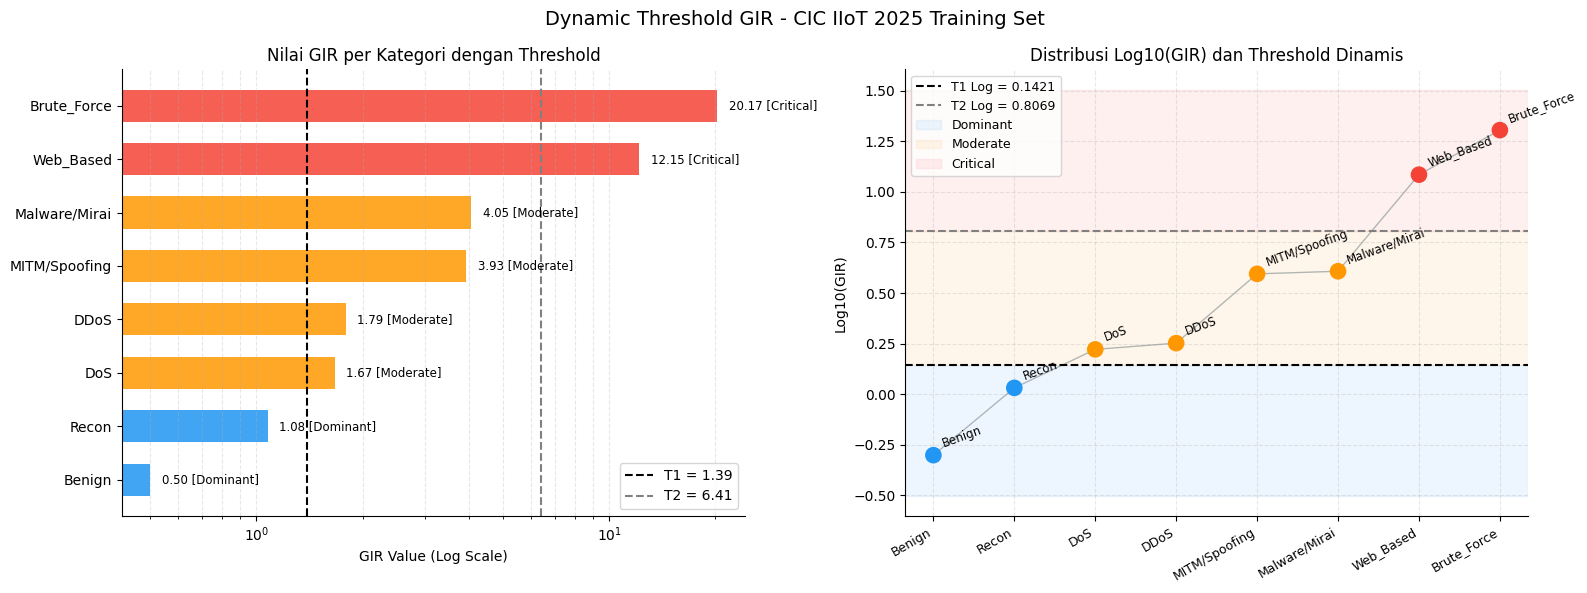

  Plot tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/langkah3_gir_threshold.png


In [ ]:
print("\nMembuat visualisasi GIR dan threshold...")

SEGMENT_COLORS = {
    'Dominant' : '#2196F3',
    'Moderate' : '#FF9800',
    'Critical' : '#F44336',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dynamic Threshold GIR - CIC IIoT 2025 Training Set', fontsize=14)

plot_cats = gir_df['Kategori'].tolist()
plot_girs = gir_df['GIR'].tolist()
plot_segs = gir_df['Segment_Final'].tolist()
bar_colors = [SEGMENT_COLORS[s] for s in plot_segs]

# Plot 1: GIR Bar + Threshold Lines (skala log)
ax1   = axes[0]
bars1 = ax1.barh(plot_cats, plot_girs, color=bar_colors, height=0.6, alpha=0.85)
ax1.axvline(x=T1_FINAL_GIR, color='black', linestyle='--', linewidth=1.5,
            label=f'T1 = {T1_FINAL_GIR:.2f}')
ax1.axvline(x=T2_FINAL_GIR, color='gray', linestyle='--', linewidth=1.5,
            label=f'T2 = {T2_FINAL_GIR:.2f}')
ax1.set_xscale('log')
ax1.set_xlabel('GIR Value (Log Scale)')
ax1.set_title('Nilai GIR per Kategori dengan Threshold')
ax1.grid(axis='x', alpha=0.3, linestyle='--', which='both')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(fontsize=10)
for bar, val, seg in zip(bars1, plot_girs, plot_segs):
    ax1.text(
        bar.get_width() * 1.08,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f} [{seg}]',
        va='center', ha='left', fontsize=8.5
    )

# Plot 2: Gap Analysis di Log Space
ax2 = axes[1]
x_pos          = np.arange(len(log_gir_values))
colors_scatter = [SEGMENT_COLORS[s] for s in gir_df['Segment_Final'].tolist()]
ax2.scatter(x_pos, log_gir_values, c=colors_scatter, s=120, zorder=5)
ax2.plot(x_pos, log_gir_values, color='#7F8C8D', linewidth=1.0, linestyle='-', alpha=0.6)

for i, (cat, log_g) in enumerate(zip(plot_cats, log_gir_values)):
    ax2.annotate(cat, xy=(i, log_g), xytext=(5, 6),
                 textcoords='offset points', fontsize=8.5, rotation=20)

ax2.axhline(y=T1_FINAL_LOG, color='black', linestyle='--', linewidth=1.5,
            label=f'T1 Log = {T1_FINAL_LOG:.4f}')
ax2.axhline(y=T2_FINAL_LOG, color='gray', linestyle='--', linewidth=1.5,
            label=f'T2 Log = {T2_FINAL_LOG:.4f}')
ax2.axhspan(log_gir_values[0] - 0.2, T1_FINAL_LOG, alpha=0.08, color='#2196F3', label='Dominant')
ax2.axhspan(T1_FINAL_LOG, T2_FINAL_LOG,             alpha=0.08, color='#FF9800', label='Moderate')
ax2.axhspan(T2_FINAL_LOG, log_gir_values[-1] + 0.2, alpha=0.08, color='#F44336', label='Critical')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(plot_cats, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Log10(GIR)')
ax2.set_title('Distribusi Log10(GIR) dan Threshold Dinamis')
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(fontsize=9, loc='upper left')

plt.tight_layout()
gir_path = VISUALIZATION_DIR_IIOT + 'langkah3_gir_threshold.png'
plt.savefig(gir_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot tersimpan: {gir_path}")

####**3.7 Visualisasi Silhouette dan Gap Analysis**


Membuat visualisasi silhouette dan gap analysis...


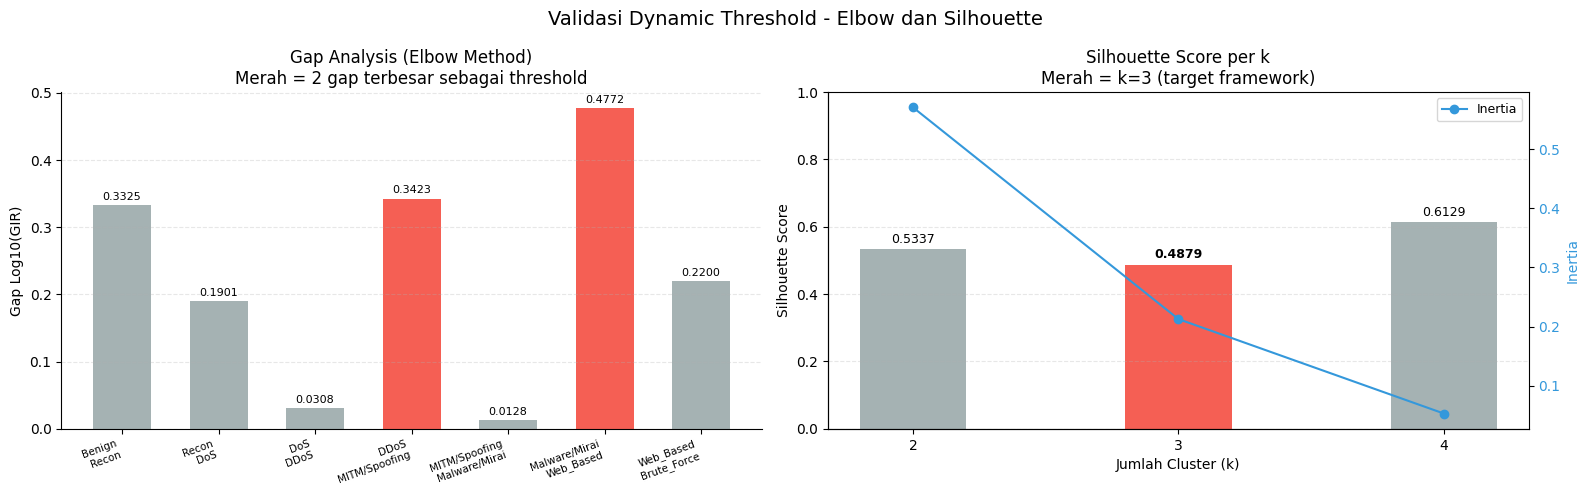

  Plot tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/langkah3_silhouette_gap.png


In [ ]:
print("\nMembuat visualisasi silhouette dan gap analysis...")

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle('Validasi Dynamic Threshold - Elbow dan Silhouette', fontsize=14)

# Plot 1: Gap (Elbow) di log space
ax_gap = axes2[0]
gap_indices = list(range(len(gaps)))
gap_values  = [g['gap_log'] for g in gaps]
gap_labels  = [f"{g['left_cat']}\n{g['right_cat']}" for g in gaps]

sorted_gap_vals  = sorted(gap_values, reverse=True)
top2_threshold_v = sorted_gap_vals[1]
gap_bar_colors   = ['#F44336' if gv >= top2_threshold_v else '#95A5A6' for gv in gap_values]

bars_gap = ax_gap.bar(gap_indices, gap_values, color=gap_bar_colors, alpha=0.85, width=0.6)
ax_gap.set_xticks(gap_indices)
ax_gap.set_xticklabels(gap_labels, fontsize=7.5, rotation=20, ha='right')
ax_gap.set_ylabel('Gap Log10(GIR)')
ax_gap.set_title('Gap Analysis (Elbow Method)\nMerah = 2 gap terbesar sebagai threshold')
ax_gap.grid(axis='y', alpha=0.3, linestyle='--')
ax_gap.spines['top'].set_visible(False)
ax_gap.spines['right'].set_visible(False)
for bar, val in zip(bars_gap, gap_values):
    ax_gap.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Silhouette Score vs k
ax_sil  = axes2[1]
k_values    = sorted(kmeans_results.keys())
sil_scores  = [kmeans_results[k]['silhouette'] for k in k_values]
inertias    = [kmeans_results[k]['inertia']    for k in k_values]
color_bars2 = ['#F44336' if k == 3 else '#95A5A6' for k in k_values]

bars_sil = ax_sil.bar(k_values, sil_scores, color=color_bars2, alpha=0.85, width=0.4)
ax_sil.set_xlabel('Jumlah Cluster (k)')
ax_sil.set_ylabel('Silhouette Score')
ax_sil.set_title('Silhouette Score per k\nMerah = k=3 (target framework)')
ax_sil.set_xticks(k_values)
ax_sil.set_ylim(0, 1.0)
ax_sil.grid(axis='y', alpha=0.3, linestyle='--')
ax_sil.spines['top'].set_visible(False)
ax_sil.spines['right'].set_visible(False)
for bar, k, sil in zip(bars_sil, k_values, sil_scores):
    ax_sil.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{sil:.4f}', ha='center', va='bottom', fontsize=9,
                fontweight='bold' if k == 3 else 'normal')

ax_sil2 = ax_sil.twinx()
ax_sil2.plot(k_values, inertias, color='#3498DB', marker='o', linewidth=1.5,
             markersize=6, label='Inertia')
ax_sil2.set_ylabel('Inertia', color='#3498DB')
ax_sil2.tick_params(axis='y', labelcolor='#3498DB')
ax_sil2.legend(fontsize=9, loc='upper right')

plt.tight_layout()
sil_path = VISUALIZATION_DIR_IIOT + 'langkah3_silhouette_gap.png'
plt.savefig(sil_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot tersimpan: {sil_path}")


####**3.8 Save Checkpoint Langkah 3**

In [ ]:
print("\nMenyimpan checkpoint Langkah 3...")

gir_results = {}
for _, row in gir_df.iterrows():
    gir_results[row['Kategori']] = {
        'train_count'   : int(row['Train_Count']),
        'train_pct'     : float(row['Train_Pct']),
        'gir'           : float(row['GIR']),
        'log_gir'       : float(row['Log_GIR']),
        'segment_elbow' : row['Segment_Elbow'],
        'segment_kmeans': row['Segment_KMeans'],
        'segment_final' : row['Segment_Final'],
    }

checkpoint_l3 = {
    'langkah'    : 3,
    'status'     : 'SELESAI',
    'gir_params' : {'w_maj': W_MAJ, 'w_min': W_MIN, 'n_majoritas': int(n_maj)},
    'gir_results': gir_results,
    'threshold_elbow': {
        'T1_GIR': T1_ELBOW_GIR, 'T2_GIR': T2_ELBOW_GIR,
        'T1_LOG': T1_ELBOW_LOG, 'T2_LOG': T2_ELBOW_LOG,
    },
    'threshold_kmeans': {
        'T1_GIR': T1_KMEANS_GIR, 'T2_GIR': T2_KMEANS_GIR,
        'T1_LOG': T1_KMEANS_LOG, 'T2_LOG': T2_KMEANS_LOG,
        'silhouette_k3': float(sil3), 'best_k': int(best_k),
        'centroids_log': sorted_centroids.tolist(),
    },
    'threshold_final': {
        'T1_GIR': T1_FINAL_GIR, 'T2_GIR': T2_FINAL_GIR,
        'T1_LOG': T1_FINAL_LOG, 'T2_LOG': T2_FINAL_LOG,
        'method_used': method_used, 'both_agree': bool(agree_all),
    },
    'segmentasi_final': {
        'Dominant': {
            'kategori': dominant_cats, 'total_samples': total_dominant,
            'pct': round(total_dominant/total_all_*100, 4),
            'aksi': 'Tidak perlu augmentasi',
        },
        'Moderate': {
            'kategori': moderate_cats, 'total_samples': total_moderate,
            'pct': round(total_moderate/total_all_*100, 4),
            'aksi': 'Augmentasi CVAE (Langkah 6)',
        },
        'Critical': {
            'kategori': critical_cats, 'total_samples': total_critical,
            'pct': round(total_critical/total_all_*100, 4),
            'aksi': 'Augmentasi Borderline-SMOTE (Langkah 7)',
        },
    },
}

ckpt_path = GIR_DIR_IIOT + 'langkah3_checkpoint.json'
with open(ckpt_path, 'w') as f:
    json.dump(checkpoint_l3, f, indent=4)
print(f"  Checkpoint tersimpan: {ckpt_path}")

csv_path = GIR_DIR_IIOT + 'langkah3_gir_values.csv'
gir_df.to_csv(csv_path, index=False)
print(f"  GIR table tersimpan : {csv_path}")


Menyimpan checkpoint Langkah 3...
  Checkpoint tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/01_GIR/langkah3_checkpoint.json
  GIR table tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/01_GIR/langkah3_gir_values.csv


####**3.9 Ringkasan**

In [ ]:
print("LANGKAH 3 SELESAI")
print("=" * 60)
print(f"\nHasil Dynamic Threshold GIR:")
print(f"  Metode   : Elbow/Gap + KMeans (k=3) + Silhouette validation")
print(f"  T1 final : {T1_FINAL_GIR:.4f} (Dominant vs Moderate)")
print(f"  T2 final : {T2_FINAL_GIR:.4f} (Moderate vs Critical)")
print(f"  Sil Score: {sil3:.4f} (k=3)")
print(f"\nSegmentasi final:")
print(f"  Dominant : {dominant_cats} ({len(dominant_cats)} kelas)")
print(f"  Moderate : {moderate_cats} ({len(moderate_cats)} kelas)")
print(f"  Critical : {critical_cats} ({len(critical_cats)} kelas)")
print("\nLangkah berikutnya: LANGKAH 4 -> Category Segmentation")
print("=" * 60)

LANGKAH 3 SELESAI

Hasil Dynamic Threshold GIR:
  Metode   : Elbow/Gap + KMeans (k=3) + Silhouette validation
  T1 final : 1.3872 (Dominant vs Moderate)
  T2 final : 6.4103 (Moderate vs Critical)
  Sil Score: 0.4879 (k=3)

Segmentasi final:
  Dominant : ['Benign', 'Recon'] (2 kelas)
  Moderate : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai'] (4 kelas)
  Critical : ['Web_Based', 'Brute_Force'] (2 kelas)

Langkah berikutnya: LANGKAH 4 -> Category Segmentation


## **Langkah 4: Category Segmentation**

####**4.1 Verifikasi Variabel dari Langkah 3**

In [ ]:
print("Verifikasi variabel dari Langkah 3")

print("Segmentasi kategori:")
print(f"  Dominant : {dominant_cats}")
print(f"  Moderate : {moderate_cats}")
print(f"  Critical : {critical_cats}")
print(f"\nThreshold GIR Final:")
print(f"  T1 (Dominant/Moderate) : {T1_FINAL_GIR:.4f}")
print(f"  T2 (Moderate/Critical) : {T2_FINAL_GIR:.4f}")
print(f"\nUkuran data utama:")
print(f"  X_train shape : {X_train.shape}")
print(f"  y_train shape : {y_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_test shape  : {y_test.shape}")
print(f"\nLabel mapping:")
for enc, name in LABEL_NAMES_IIOT.items():
    count = np.sum(y_train == enc)
    print(f"  {enc}: {name} -> {count:,} samples")
print(f"\nPath segmentasi: {SEGMENTATION_DIR_IIOT}")
os.makedirs(SEGMENTATION_DIR_IIOT, exist_ok=True)
print("  Folder siap.")
mem = psutil.virtual_memory()
print(f"\nRAM tersisa sebelum segmentasi: {mem.available / 1024**3:.2f} GB")

Verifikasi variabel dari Langkah 3
Segmentasi kategori:
  Dominant : ['Benign', 'Recon']
  Moderate : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai']
  Critical : ['Web_Based', 'Brute_Force']

Threshold GIR Final:
  T1 (Dominant/Moderate) : 1.3872
  T2 (Moderate/Critical) : 6.4103

Ukuran data utama:
  X_train shape : (386274, 71)
  y_train shape : (386274,)
  X_test shape  : (45319, 71)
  y_test shape  : (45319,)

Label mapping:
  0: Benign -> 163,578 samples
  1: Brute_Force -> 4,055 samples
  2: DDoS -> 45,744 samples
  3: DoS -> 49,107 samples
  4: MITM/Spoofing -> 20,799 samples
  5: Malware/Mirai -> 20,195 samples
  6: Recon -> 76,067 samples
  7: Web_Based -> 6,729 samples

Path segmentasi: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/
  Folder siap.

RAM tersisa sebelum segmentasi: 47.52 GB


####**4.2 Membuat Mapping Label ke Segmen**

In [ ]:
print("Membuat mapping label ke segmen")

LABEL_TO_SEGMENT = {}
for enc, name in LABEL_NAMES_IIOT.items():
    if name in dominant_cats:
        LABEL_TO_SEGMENT[enc] = 'dominant'
    elif name in moderate_cats:
        LABEL_TO_SEGMENT[enc] = 'moderate'
    elif name in critical_cats:
        LABEL_TO_SEGMENT[enc] = 'critical'
    else:
        LABEL_TO_SEGMENT[enc] = 'unknown'

print("\nMapping encoded label -> segmen:")
for enc, seg in LABEL_TO_SEGMENT.items():
    name = LABEL_NAMES_IIOT[enc]
    print(f"  {enc} ({name}) -> {seg.upper()}")

dominant_labels = [k for k, v in LABEL_TO_SEGMENT.items() if v == 'dominant']
moderate_labels = [k for k, v in LABEL_TO_SEGMENT.items() if v == 'moderate']
critical_labels = [k for k, v in LABEL_TO_SEGMENT.items() if v == 'critical']

print(f"\nEncoded labels per segmen:")
print(f"  Dominant : {dominant_labels} -> {[LABEL_NAMES_IIOT[l] for l in dominant_labels]}")
print(f"  Moderate : {moderate_labels} -> {[LABEL_NAMES_IIOT[l] for l in moderate_labels]}")
print(f"  Critical : {critical_labels} -> {[LABEL_NAMES_IIOT[l] for l in critical_labels]}")

Membuat mapping label ke segmen

Mapping encoded label -> segmen:
  0 (Benign) -> DOMINANT
  1 (Brute_Force) -> CRITICAL
  2 (DDoS) -> MODERATE
  3 (DoS) -> MODERATE
  4 (MITM/Spoofing) -> MODERATE
  5 (Malware/Mirai) -> MODERATE
  6 (Recon) -> DOMINANT
  7 (Web_Based) -> CRITICAL

Encoded labels per segmen:
  Dominant : [0, 6] -> ['Benign', 'Recon']
  Moderate : [2, 3, 4, 5] -> ['DDoS', 'DoS', 'MITM/Spoofing', 'Malware/Mirai']
  Critical : [1, 7] -> ['Brute_Force', 'Web_Based']


####**4.3 Membuat Boolean Mask per Segmen**

In [ ]:
print("Membuat boolean mask per segmen")

start_time = time.time()

mask_dominant = np.isin(y_train, dominant_labels)
mask_moderate = np.isin(y_train, moderate_labels)
mask_critical = np.isin(y_train, critical_labels)

elapsed = time.time() - start_time
print(f"Mask berhasil dibuat dalam {elapsed:.2f} detik")

n_dominant = mask_dominant.sum()
n_moderate = mask_moderate.sum()
n_critical = mask_critical.sum()
n_total    = len(y_train)

print(f"\nJumlah samples per segmen:")
print(f"  Dominant : {n_dominant:,} ({n_dominant/n_total*100:.2f}%)")
print(f"  Moderate : {n_moderate:,} ({n_moderate/n_total*100:.2f}%)")
print(f"  Critical : {n_critical:,} ({n_critical/n_total*100:.2f}%)")
print(f"  Total    : {n_dominant + n_moderate + n_critical:,}")
print(f"  Expected : {n_total:,}")

assert (n_dominant + n_moderate + n_critical) == n_total, \
    "ERROR: Total segmen tidak sama dengan total data!"
print("\nValidasi: Total segmen = Total data [OK]")

Membuat boolean mask per segmen
Mask berhasil dibuat dalam 0.01 detik

Jumlah samples per segmen:
  Dominant : 239,645 (62.04%)
  Moderate : 135,845 (35.17%)
  Critical : 10,784 (2.79%)
  Total    : 386,274
  Expected : 386,274

Validasi: Total segmen = Total data [OK]


####**4.4 Split Data per Segmen**

In [ ]:
print("Split X_train dan y_train per segmen")

n_features = len(feature_names)

print("Memproses segmen DOMINANT...")
start = time.time()
X_dominant = X_train[mask_dominant]
y_dominant = y_train[mask_dominant]
print(f"  X_dominant shape : {X_dominant.shape}")
print(f"  y_dominant shape : {y_dominant.shape}")
print(f"  Selesai dalam    : {time.time()-start:.2f} detik")
print("  Distribusi kelas di DOMINANT:")
for lbl in dominant_labels:
    cnt = np.sum(y_dominant == lbl)
    print(f"    {LABEL_NAMES_IIOT[lbl]}: {cnt:,}")

print("\nMemproses segmen MODERATE...")
start = time.time()
X_moderate = X_train[mask_moderate]
y_moderate = y_train[mask_moderate]
print(f"  X_moderate shape : {X_moderate.shape}")
print(f"  y_moderate shape : {y_moderate.shape}")
print(f"  Selesai dalam    : {time.time()-start:.2f} detik")
print("  Distribusi kelas di MODERATE:")
for lbl in moderate_labels:
    cnt = np.sum(y_moderate == lbl)
    print(f"    {LABEL_NAMES_IIOT[lbl]}: {cnt:,}")

print("\nMemproses segmen CRITICAL...")
start = time.time()
X_critical = X_train[mask_critical]
y_critical = y_train[mask_critical]
print(f"  X_critical shape : {X_critical.shape}")
print(f"  y_critical shape : {y_critical.shape}")
print(f"  Selesai dalam    : {time.time()-start:.2f} detik")
print("  Distribusi kelas di CRITICAL:")
for lbl in critical_labels:
    cnt = np.sum(y_critical == lbl)
    print(f"    {LABEL_NAMES_IIOT[lbl]}: {cnt:,}")

Split X_train dan y_train per segmen
Memproses segmen DOMINANT...
  X_dominant shape : (239645, 71)
  y_dominant shape : (239645,)
  Selesai dalam    : 0.08 detik
  Distribusi kelas di DOMINANT:
    Benign: 163,578
    Recon: 76,067

Memproses segmen MODERATE...
  X_moderate shape : (135845, 71)
  y_moderate shape : (135845,)
  Selesai dalam    : 0.04 detik
  Distribusi kelas di MODERATE:
    DDoS: 45,744
    DoS: 49,107
    MITM/Spoofing: 20,799
    Malware/Mirai: 20,195

Memproses segmen CRITICAL...
  X_critical shape : (10784, 71)
  y_critical shape : (10784,)
  Selesai dalam    : 0.00 detik
  Distribusi kelas di CRITICAL:
    Brute_Force: 4,055
    Web_Based: 6,729


####**4.5 Menyimpan Segmen ke Disk**

In [ ]:
print("Menyimpan segmen ke disk")

def save_segment(X, y, segment_name, save_dir):
    path_X   = os.path.join(save_dir, f'X_{segment_name}.npy')
    path_y   = os.path.join(save_dir, f'y_{segment_name}.npy')
    start    = time.time()
    np.save(path_X, X)
    np.save(path_y, y)
    elapsed  = time.time() - start
    size_X   = os.path.getsize(path_X) / 1024**2
    size_y   = os.path.getsize(path_y) / 1024**2
    print(f"  [{segment_name.upper()}] Tersimpan dalam {elapsed:.2f} detik")
    print(f"    X -> {path_X} ({size_X:.2f} MB)")
    print(f"    y -> {path_y} ({size_y:.2f} MB)")
    return path_X, path_y

save_segment(X_dominant, y_dominant, 'dominant', SEGMENTATION_DIR_IIOT)
save_segment(X_moderate, y_moderate, 'moderate', SEGMENTATION_DIR_IIOT)
save_segment(X_critical, y_critical, 'critical', SEGMENTATION_DIR_IIOT)

np.save(os.path.join(SEGMENTATION_DIR_IIOT, 'mask_dominant.npy'), mask_dominant)
np.save(os.path.join(SEGMENTATION_DIR_IIOT, 'mask_moderate.npy'), mask_moderate)
np.save(os.path.join(SEGMENTATION_DIR_IIOT, 'mask_critical.npy'), mask_critical)
print("\n  Mask juga tersimpan.")

Menyimpan segmen ke disk
  [DOMINANT] Tersimpan dalam 0.19 detik
    X -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/X_dominant.npy (129.81 MB)
    y -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/y_dominant.npy (1.83 MB)
  [MODERATE] Tersimpan dalam 0.11 detik
    X -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/X_moderate.npy (73.59 MB)
    y -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/y_moderate.npy (1.04 MB)
  [CRITICAL] Tersimpan dalam 0.02 detik
    X -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/X_critical.npy (5.84 MB)
    y -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/y_critical.npy (0.08 MB)

  Mask juga tersimpan.


####**4.6 Menyimpan Metadata Segmentasi**

In [ ]:
print("Menyimpan metadata segmentasi")

segmentation_metadata = {
    'threshold': {'T1_GIR': float(T1_FINAL_GIR), 'T2_GIR': float(T2_FINAL_GIR)},
    'segments': {
        'dominant': {
            'categories': dominant_cats, 'encoded_labels': dominant_labels,
            'n_samples': int(n_dominant),
            'pct_of_train': float(round(n_dominant/n_total*100, 4)),
            'class_counts': {LABEL_NAMES_IIOT[lbl]: int(np.sum(y_dominant == lbl))
                             for lbl in dominant_labels}
        },
        'moderate': {
            'categories': moderate_cats, 'encoded_labels': moderate_labels,
            'n_samples': int(n_moderate),
            'pct_of_train': float(round(n_moderate/n_total*100, 4)),
            'class_counts': {LABEL_NAMES_IIOT[lbl]: int(np.sum(y_moderate == lbl))
                             for lbl in moderate_labels}
        },
        'critical': {
            'categories': critical_cats, 'encoded_labels': critical_labels,
            'n_samples': int(n_critical),
            'pct_of_train': float(round(n_critical/n_total*100, 4)),
            'class_counts': {LABEL_NAMES_IIOT[lbl]: int(np.sum(y_critical == lbl))
                             for lbl in critical_labels}
        },
    },
    'total_train_samples': int(n_total),
    'n_features'         : int(n_features),
    'label_to_segment'   : {str(k): v for k, v in LABEL_TO_SEGMENT.items()},
}

meta_path = os.path.join(SEGMENTATION_DIR_IIOT, 'segmentation_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(segmentation_metadata, f, indent=4)
print(f"  Metadata tersimpan: {meta_path}")

Menyimpan metadata segmentasi
  Metadata tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/segmentation_metadata.json


####**4.7 Validasi Setelah Simpan (Load Ulang Dan Cek)**

In [ ]:
print("\nValidasi setelah simpan...")
for seg, X_ref, y_ref in [
    ('dominant', X_dominant, y_dominant),
    ('moderate', X_moderate, y_moderate),
    ('critical', X_critical, y_critical),
]:
    X_check  = np.load(os.path.join(SEGMENTATION_DIR_IIOT, f'X_{seg}.npy'))
    y_check  = np.load(os.path.join(SEGMENTATION_DIR_IIOT, f'y_{seg}.npy'))
    shape_ok = (X_check.shape == X_ref.shape) and (y_check.shape == y_ref.shape)
    val_ok   = np.allclose(X_check[:100], X_ref[:100])
    lbl_ok   = np.array_equal(y_check[:100], y_ref[:100])
    status   = "OK" if (shape_ok and val_ok and lbl_ok) else "FAIL"
    print(f"  [{seg.upper()}] Shape {X_check.shape} | Nilai [OK={val_ok}] | Label [OK={lbl_ok}] -> {status}")
    del X_check, y_check

print("\nValidasi selesai.")


Validasi setelah simpan...
  [DOMINANT] Shape (239645, 71) | Nilai [OK=True] | Label [OK=True] -> OK
  [MODERATE] Shape (135845, 71) | Nilai [OK=True] | Label [OK=True] -> OK
  [CRITICAL] Shape (10784, 71) | Nilai [OK=True] | Label [OK=True] -> OK

Validasi selesai.


####**4.8 Visualisasi Segmentasi**

Membuat visualisasi segmentasi...


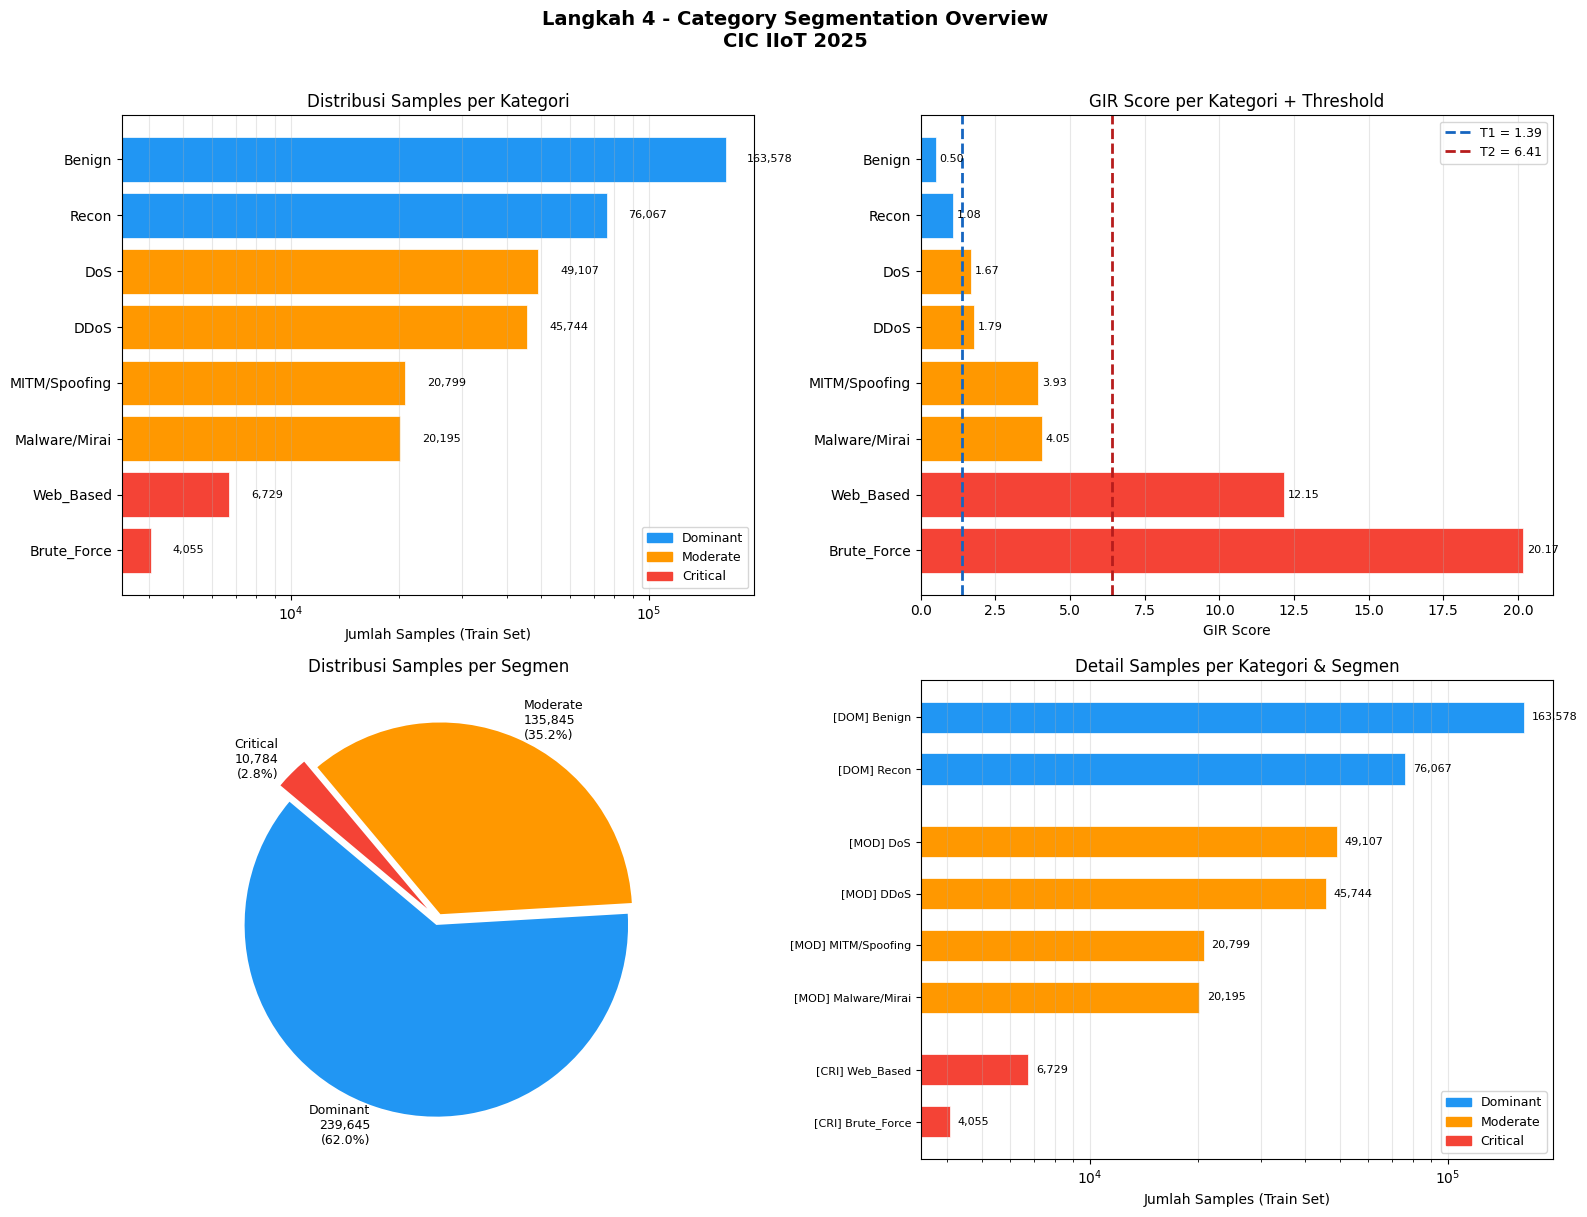

  Gambar 1 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah4_Segmentation_Overview.png


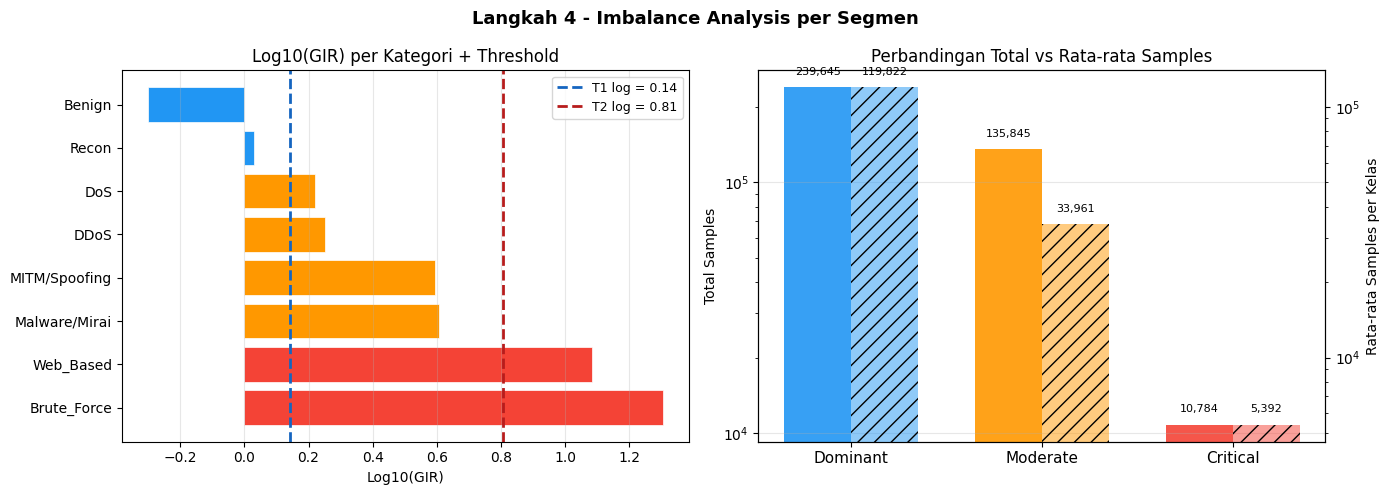

  Gambar 2 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah4_Segmentation_Imbalance.png


In [ ]:
print("Membuat visualisasi segmentasi...")

seg_colors = {'dominant': '#2196F3', 'moderate': '#FF9800', 'critical': '#F44336'}
NAME_TO_ENC_IIOT_local = NAME_TO_ENC_IIOT

all_class_data = []
for enc, name in LABEL_NAMES_IIOT.items():
    seg   = LABEL_TO_SEGMENT[enc]
    count = int(np.sum(y_train == enc))
    gir   = float(gir_df[gir_df['Kategori'] == name]['GIR'].values[0]) \
            if name in gir_df['Kategori'].values else 0.0
    log_g = float(gir_df[gir_df['Kategori'] == name]['Log_GIR'].values[0]) \
            if name in gir_df['Kategori'].values else 0.0
    all_class_data.append({'name': name, 'enc': enc, 'segment': seg,
                           'count': count, 'gir': gir, 'log_gir': log_g})

all_class_df = pd.DataFrame(all_class_data).sort_values('count', ascending=False)

legend_patches = [
    mpatches.Patch(color=seg_colors['dominant'], label='Dominant'),
    mpatches.Patch(color=seg_colors['moderate'], label='Moderate'),
    mpatches.Patch(color=seg_colors['critical'], label='Critical'),
]

# Figure 1: Overview 4-panel
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Langkah 4 - Category Segmentation Overview\nCIC IIoT 2025',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Distribusi samples per kelas
ax1       = axes[0, 0]
bc        = [seg_colors[row['segment']] for _, row in all_class_df.iterrows()]
bars_p1   = ax1.barh(all_class_df['name'], all_class_df['count'],
                     color=bc, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Jumlah Samples (Train Set)')
ax1.set_title('Distribusi Samples per Kategori')
ax1.set_xscale('log')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, which='both')
for bar, cnt in zip(bars_p1, all_class_df['count']):
    ax1.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height()/2,
             f'{cnt:,}', va='center', fontsize=8)
ax1.legend(handles=legend_patches, loc='lower right', fontsize=9)

# Panel 2: GIR per kelas dengan threshold lines
ax2         = axes[0, 1]
gir_sorted2 = all_class_df.sort_values('gir', ascending=True)
bc2         = [seg_colors[row['segment']] for _, row in gir_sorted2.iterrows()]
ax2.barh(gir_sorted2['name'], gir_sorted2['gir'], color=bc2, edgecolor='white', linewidth=0.5)
ax2.axvline(x=T1_FINAL_GIR, color='#1565C0', linestyle='--', linewidth=2,
            label=f'T1 = {T1_FINAL_GIR:.2f}')
ax2.axvline(x=T2_FINAL_GIR, color='#B71C1C', linestyle='--', linewidth=2,
            label=f'T2 = {T2_FINAL_GIR:.2f}')
ax2.set_xlabel('GIR Score')
ax2.set_title('GIR Score per Kategori + Threshold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.legend(fontsize=9)
for i, (_, row) in enumerate(gir_sorted2.iterrows()):
    ax2.text(row['gir'] + T2_FINAL_GIR * 0.02, i,
             f'{row["gir"]:.2f}', va='center', fontsize=8)

# Panel 3: Pie chart
ax3          = axes[1, 0]
seg_totals   = {'Dominant': n_dominant, 'Moderate': n_moderate, 'Critical': n_critical}
seg_lbl_pie  = [f"{k}\n{v:,}\n({v/n_total*100:.1f}%)" for k, v in seg_totals.items()]
seg_sizes    = list(seg_totals.values())
seg_pie_col  = [seg_colors['dominant'], seg_colors['moderate'], seg_colors['critical']]
ax3.pie(seg_sizes, labels=seg_lbl_pie, colors=seg_pie_col,
        explode=(0.03, 0.03, 0.08), textprops={'fontsize': 9}, startangle=140)
ax3.set_title('Distribusi Samples per Segmen')

# Panel 4: Detail samples per kategori & segmen
ax4        = axes[1, 1]
seg_order  = ['Dominant', 'Moderate', 'Critical']
seg_cat_nm = {'Dominant': dominant_cats, 'Moderate': moderate_cats, 'Critical': critical_cats}
y_pos = 0
yticks_pos, yticks_lab = [], []
for seg_name in seg_order:
    cats  = seg_cat_nm[seg_name]
    color = seg_colors[seg_name.lower()]
    for cat in cats:
        enc = NAME_TO_ENC_IIOT[cat]
        cnt = int(np.sum(y_train == enc))
        ax4.barh(y_pos, cnt, height=0.6, color=color, edgecolor='white', linewidth=0.5)
        ax4.text(cnt * 1.05, y_pos, f'{cnt:,}', va='center', fontsize=8)
        yticks_pos.append(y_pos)
        yticks_lab.append(f'[{seg_name[:3].upper()}] {cat}')
        y_pos += 1
    y_pos += 0.4
ax4.set_yticks(yticks_pos)
ax4.set_yticklabels(yticks_lab, fontsize=8)
ax4.set_xlabel('Jumlah Samples (Train Set)')
ax4.set_title('Detail Samples per Kategori & Segmen')
ax4.set_xscale('log')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3, which='both')
ax4.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
fig_path1 = VISUALIZATION_DIR_IIOT + 'Langkah4_Segmentation_Overview.png'
plt.savefig(fig_path1, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Gambar 1 tersimpan: {fig_path1}")

# Figure 2: Imbalance analysis
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Langkah 4 - Imbalance Analysis per Segmen', fontsize=13, fontweight='bold')

ax_l       = axes2[0]
gir_s2     = all_class_df.sort_values('log_gir', ascending=True)
bc_l       = [seg_colors[row['segment']] for _, row in gir_s2.iterrows()]
ax_l.barh(gir_s2['name'], gir_s2['log_gir'], color=bc_l, edgecolor='white', linewidth=0.5)
ax_l.axvline(x=T1_FINAL_LOG, color='#1565C0', linestyle='--', linewidth=2,
             label=f'T1 log = {T1_FINAL_LOG:.2f}')
ax_l.axvline(x=T2_FINAL_LOG, color='#B71C1C', linestyle='--', linewidth=2,
             label=f'T2 log = {T2_FINAL_LOG:.2f}')
ax_l.set_xlabel('Log10(GIR)')
ax_l.set_title('Log10(GIR) per Kategori + Threshold')
ax_l.invert_yaxis()
ax_l.grid(axis='x', alpha=0.3)
ax_l.legend(fontsize=9)

ax_r = axes2[1]
seg_summary = pd.DataFrame([
    {'Segmen': 'Dominant', 'Jumlah Kelas': len(dominant_cats),
     'Total Samples': n_dominant, 'Rata2 per Kelas': n_dominant // max(1, len(dominant_cats))},
    {'Segmen': 'Moderate', 'Jumlah Kelas': len(moderate_cats),
     'Total Samples': n_moderate, 'Rata2 per Kelas': n_moderate // max(1, len(moderate_cats))},
    {'Segmen': 'Critical', 'Jumlah Kelas': len(critical_cats),
     'Total Samples': n_critical, 'Rata2 per Kelas': n_critical // max(1, len(critical_cats))},
])
x   = np.arange(len(seg_summary))
w   = 0.35
pie_cols = [seg_colors['dominant'], seg_colors['moderate'], seg_colors['critical']]
bt  = ax_r.bar(x - w/2, seg_summary['Total Samples'],   width=w, color=pie_cols, alpha=0.9)
ax_r2 = ax_r.twinx()
ba  = ax_r2.bar(x + w/2, seg_summary['Rata2 per Kelas'], width=w, color=pie_cols, alpha=0.5, hatch='//')
ax_r.set_xticks(x)
ax_r.set_xticklabels(seg_summary['Segmen'], fontsize=11)
ax_r.set_ylabel('Total Samples')
ax_r2.set_ylabel('Rata-rata Samples per Kelas')
ax_r.set_title('Perbandingan Total vs Rata-rata Samples')
ax_r.set_yscale('log')
ax_r2.set_yscale('log')
ax_r.grid(axis='y', alpha=0.3)
for bar in bt:
    ax_r.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
              f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in ba:
    ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
               f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig_path2 = VISUALIZATION_DIR_IIOT + 'Langkah4_Segmentation_Imbalance.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Gambar 2 tersimpan: {fig_path2}")

####**4.9 Ringkasan**

In [ ]:
print(f"Hasil segmentasi X_train ({n_total:,} samples):")
print(f"  {'Segmen':<12} {'Kelas':<20} {'Samples':>10} {'Persen':>8}")
print(f"  {'-'*55}")
for seg_name, labels, n_seg in [
    ('DOMINANT', dominant_labels, n_dominant),
    ('MODERATE', moderate_labels, n_moderate),
    ('CRITICAL', critical_labels, n_critical),
]:
    for i, lbl in enumerate(labels):
        cnt      = int(np.sum(y_train == lbl))
        cat_name = LABEL_NAMES_IIOT[lbl]
        prefix   = seg_name if i == 0 else ''
        print(f"  {prefix:<12} {cat_name:<20} {cnt:>10,} {cnt/n_total*100:>7.2f}%")
    if seg_name != 'CRITICAL':
        print(f"  {'':12} {'Subtotal':.^20} {n_seg:>10,} {n_seg/n_total*100:>7.2f}%")
        print(f"  {'-'*55}")

print(f"\n  {'':12} {'TOTAL':.^20} {n_total:>10,} {'100.00%':>8}")
print(f"\nFile tersimpan di: {SEGMENTATION_DIR_IIOT}")

del mask_dominant, mask_moderate, mask_critical
gc.collect()

mem = psutil.virtual_memory()
print(f"\nRAM tersisa setelah Langkah 4: {mem.available / 1024**3:.2f} GB")
print("Mask sementara dihapus dari RAM. gc.collect() selesai.")
print("\nLangkah 4 selesai. Siap lanjut ke Langkah 5 (CAFW).")
print("=" * 60)

Hasil segmentasi X_train (386,274 samples):
  Segmen       Kelas                   Samples   Persen
  -------------------------------------------------------
  DOMINANT     Benign                  163,578   42.35%
               Recon                    76,067   19.69%
               ......Subtotal......    239,645   62.04%
  -------------------------------------------------------
  MODERATE     DDoS                     45,744   11.84%
               DoS                      49,107   12.71%
               MITM/Spoofing            20,799    5.38%
               Malware/Mirai            20,195    5.23%
               ......Subtotal......    135,845   35.17%
  -------------------------------------------------------
  CRITICAL     Brute_Force               4,055    1.05%
               Web_Based                 6,729    1.74%

               .......TOTAL........    386,274  100.00%

File tersimpan di: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/

RAM tersisa s

## **Langkah 5: Category-Aware Feature Weighting (CAFW)**

####**5.1 Setup dan Verifikasi**

In [ ]:
# Konfigurasi CAFW
EPSILON          = 1e-5    # Optimal epsilon dari FIGS paper (Sec 6.4)
TOP_K            = 30      # Top-K features per kategori
N_DISC_TRAIN     = 40000   # Max samples per kelas untuk discriminator training
N_SENSITIVITY    = 5000    # Samples untuk sensitivity analysis
N_RF_TRAIN       = 20000   # Max total samples untuk RF training
N_SHAP_BG        = 500     # Background samples untuk SHAP
N_SHAP_EXPLAIN   = 1500    # Samples untuk SHAP explanation
DISC_EPOCHS      = 50      # Max epochs discriminator
DISC_BATCH       = 512     # Batch size discriminator
RF_N_EST         = 100     # N estimators RandomForest
RANDOM_STATE     = 42

# EFI weights
W_DISC = 0.4
W_SHAP = 0.3
W_RF   = 0.3

print(f"\nKonfigurasi CAFW:")
print(f"  epsilon               : {EPSILON}")
print(f"  Top-K features        : {TOP_K}")
print(f"  Max disc train/class  : {N_DISC_TRAIN:,}")
print(f"  Sensitivity samples   : {N_SENSITIVITY:,}")
print(f"  RF total samples      : {N_RF_TRAIN:,}")
print(f"  SHAP background       : {N_SHAP_BG:,}")
print(f"  SHAP explain          : {N_SHAP_EXPLAIN:,}")
print(f"  EFI weights           : Disc={W_DISC}, SHAP={W_SHAP}, RF={W_RF}")

# Kategori target: hanya yang akan diaugmentasi
TARGET_CATS = moderate_cats + critical_cats
print(f"\nKategori target : {TARGET_CATS}")
print(f"  Moderate : {moderate_cats}")
print(f"  Critical : {critical_cats}")

# Verifikasi data di memory
print(f"\nVerifikasi data:")
print(f"  X_train    : {X_train.shape}")
print(f"  y_train    : {y_train.shape}")
print(f"  X_moderate : {X_moderate.shape}")
print(f"  y_moderate : {y_moderate.shape}")
print(f"  X_critical : {X_critical.shape}")
print(f"  y_critical : {y_critical.shape}")

os.makedirs(CAFW_DIR_IIOT, exist_ok=True)
mem = psutil.virtual_memory()
print(f"\nRAM tersisa sebelum CAFW: {mem.available / 1024**3:.2f} GB")


Konfigurasi CAFW:
  epsilon               : 1e-05
  Top-K features        : 30
  Max disc train/class  : 40,000
  Sensitivity samples   : 5,000
  RF total samples      : 20,000
  SHAP background       : 500
  SHAP explain          : 1,500
  EFI weights           : Disc=0.4, SHAP=0.3, RF=0.3

Kategori target : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai', 'Web_Based', 'Brute_Force']
  Moderate : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai']
  Critical : ['Web_Based', 'Brute_Force']

Verifikasi data:
  X_train    : (386274, 71)
  y_train    : (386274,)
  X_moderate : (135845, 71)
  y_moderate : (135845,)
  X_critical : (10784, 71)
  y_critical : (10784,)

RAM tersisa sebelum CAFW: 47.08 GB


####**5.2 Definisi Fungsi-Fungsi Bantu**

In [ ]:
print("Mendefinisikan fungsi bantu")

def build_discriminator(input_dim):
    inp = tf.keras.Input(shape=(input_dim,))
    x   = layers.Dense(256)(inp)
    x   = layers.Lambda(lambda t: tf.nn.leaky_relu(t, alpha=0.2))(x)
    x   = layers.Dense(128)(x)
    x   = layers.Lambda(lambda t: tf.nn.leaky_relu(t, alpha=0.2))(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def prepare_binary_data(X_pos, X_all, y_all, cat_encoded, n_per_class, seed=42):
    rng    = np.random.default_rng(seed)
    n_pos  = min(len(X_pos), n_per_class)
    idx_p  = rng.choice(len(X_pos), size=n_pos, replace=False)
    X_p    = X_pos[idx_p].astype(np.float32)
    y_p    = np.ones(n_pos, dtype=np.float32)
    X_neg_pool = X_all[y_all != cat_encoded]
    n_neg  = min(len(X_neg_pool), n_per_class)
    idx_n  = rng.choice(len(X_neg_pool), size=n_neg, replace=False)
    X_n    = X_neg_pool[idx_n].astype(np.float32)
    y_n    = np.zeros(n_neg, dtype=np.float32)
    del X_neg_pool
    gc.collect()
    X_bin  = np.vstack([X_p, X_n])
    y_bin  = np.concatenate([y_p, y_n])
    shuf   = rng.permutation(len(X_bin))
    return X_bin[shuf], y_bin[shuf], X_p

def train_discriminator_model(X_bin, y_bin, n_feat, epochs=50, batch_size=512):
    disc    = build_discriminator(n_feat)
    es      = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                            restore_best_weights=True, verbose=0)
    history = disc.fit(X_bin, y_bin, epochs=epochs, batch_size=batch_size,
                       validation_split=0.15, callbacks=[es], verbose=0)
    return disc, history

def compute_sensitivity_importance(disc_model, X_sample, epsilon=1e-5, batch_size=1024):
    n_feat     = X_sample.shape[1]
    importance = np.zeros(n_feat, dtype=np.float64)
    orig       = disc_model.predict(X_sample, batch_size=batch_size, verbose=0).flatten()
    for i in range(n_feat):
        X_pert    = X_sample.copy()
        X_pert[:, i] += epsilon
        pert      = disc_model.predict(X_pert, batch_size=batch_size, verbose=0).flatten()
        importance[i] = np.mean(np.abs(orig - pert))
        del X_pert
    return importance

def compute_rf_importance(X_bin, y_bin, n_estimators=100, n_samples=20000, seed=42):
    rng = np.random.default_rng(seed)
    if len(X_bin) > n_samples:
        idx  = rng.choice(len(X_bin), size=n_samples, replace=False)
        X_s, y_s = X_bin[idx], y_bin[idx]
    else:
        X_s, y_s = X_bin.copy(), y_bin.copy()
    rf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=-1,
                                random_state=seed, class_weight='balanced')
    rf.fit(X_s, y_s)
    return rf.feature_importances_, rf

def compute_shap_importance(rf_model, X_bin, n_bg=500, n_explain=1500, seed=42):
    rng     = np.random.default_rng(seed)
    n       = len(X_bin)
    idx_bg  = rng.choice(n, size=min(n_bg, n), replace=False)
    X_bg    = X_bin[idx_bg]
    explainer = shap.TreeExplainer(rf_model, data=X_bg,
                                   feature_perturbation='interventional')
    idx_exp = rng.choice(n, size=min(n_explain, n), replace=False)
    X_exp   = X_bin[idx_exp]
    shap_vals = explainer.shap_values(X_exp, check_additivity=False)
    if isinstance(shap_vals, list):
        shap_pos = shap_vals[1]
    else:
        shap_pos = shap_vals
    return np.mean(np.abs(shap_pos), axis=0)

def minmax_normalize(arr):
    mn, mx = arr.min(), arr.max()
    if (mx - mn) < 1e-10:
        return np.ones_like(arr, dtype=np.float64) / len(arr)
    return (arr - mn) / (mx - mn)

def compute_efi(disc_imp, shap_imp, rf_imp, w_disc=0.4, w_shap=0.3, w_rf=0.3):
    disc_n  = minmax_normalize(disc_imp)
    shap_n  = minmax_normalize(shap_imp)
    rf_n    = minmax_normalize(rf_imp)
    efi_raw = w_disc * disc_n + w_shap * shap_n + w_rf * rf_n
    efi_norm = minmax_normalize(efi_raw)
    return efi_norm, disc_n, shap_n, rf_n

print("  Fungsi berhasil didefinisikan:")
for fn in ['build_discriminator', 'prepare_binary_data', 'train_discriminator_model',
           'compute_sensitivity_importance', 'compute_rf_importance',
           'compute_shap_importance', 'minmax_normalize', 'compute_efi']:
    print(f"  - {fn}")

Mendefinisikan fungsi bantu
  Fungsi berhasil didefinisikan:
  - build_discriminator
  - prepare_binary_data
  - train_discriminator_model
  - compute_sensitivity_importance
  - compute_rf_importance
  - compute_shap_importance
  - minmax_normalize
  - compute_efi


####**5.3 Komputasi EFI per Kategori Target**

In [ ]:
from tensorflow.keras.models import Model

print("Komputasi EFI untuk setiap kategori target")
print(f"Jumlah kategori : {len(TARGET_CATS)}")
print(f"Urutan proses   : {TARGET_CATS}")

cafw_results  = {}
t_total_start = time.time()

for idx_cat, cat_name in enumerate(TARGET_CATS):
    print(f"\n{'='*55}")
    print(f"[{idx_cat+1}/{len(TARGET_CATS)}] Kategori: {cat_name}")
    print(f"{'='*55}")
    t_cat_start = time.time()

    cat_enc = NAME_TO_ENC_IIOT[cat_name]
    segment = 'moderate' if cat_name in moderate_cats else 'critical'

    if segment == 'moderate':
        mask_pos = (y_moderate == cat_enc)
        X_pos    = X_moderate[mask_pos]
    else:
        mask_pos = (y_critical == cat_enc)
        X_pos    = X_critical[mask_pos]

    n_pos = len(X_pos)
    print(f"  Segment         : {segment}")
    print(f"  Positive samples: {n_pos:,}")

    # [a] Persiapan binary dataset
    print(f"\n  [a] Mempersiapkan binary dataset...")
    t = time.time()
    X_bin, y_bin, X_pos_samp = prepare_binary_data(
        X_pos=X_pos, X_all=X_train, y_all=y_train,
        cat_encoded=cat_enc, n_per_class=N_DISC_TRAIN, seed=RANDOM_STATE
    )
    rng    = np.random.default_rng(RANDOM_STATE)
    n_sens = min(N_SENSITIVITY, len(X_pos_samp))
    idx_s  = rng.choice(len(X_pos_samp), size=n_sens, replace=False)
    X_sens = X_pos_samp[idx_s].astype(np.float32)
    print(f"    Binary dataset  : {X_bin.shape} | positif={int(y_bin.sum()):,} negatif={int((y_bin==0).sum()):,}")
    print(f"    Sensitivity     : {X_sens.shape[0]:,} samples")
    print(f"    Selesai dalam   : {time.time()-t:.2f} detik")

    # [b] Discriminator training + sensitivity analysis
    print(f"\n  [b] Discriminator training + sensitivity analysis...")
    t = time.time()
    disc_model, disc_hist = train_discriminator_model(
        X_bin, y_bin, n_feat=n_features, epochs=DISC_EPOCHS, batch_size=DISC_BATCH
    )
    n_ep     = len(disc_hist.history['loss'])
    val_acc  = disc_hist.history.get('val_accuracy', [0])[-1]
    val_loss = disc_hist.history.get('val_loss', [0])[-1]
    print(f"    Epochs dijalankan : {n_ep}/{DISC_EPOCHS} (early stopping)")
    print(f"    Val accuracy      : {val_acc:.4f}")
    print(f"    Val loss          : {val_loss:.4f}")
    print(f"    Training selesai  : {time.time()-t:.2f} detik")

    print(f"    Menghitung sensitivity ({n_features} fitur x {n_sens} samples)...")
    t = time.time()
    disc_importance = compute_sensitivity_importance(disc_model, X_sens, epsilon=EPSILON)
    print(f"    Sensitivity selesai : {time.time()-t:.2f} detik")
    top5_disc = np.argsort(disc_importance)[-5:][::-1]
    print(f"    Top-5 disc names    : {[feature_names[i] for i in top5_disc]}")

    del disc_model
    tf.keras.backend.clear_session()
    gc.collect()

    # [c] Random Forest feature importance
    print(f"\n  [c] Komputasi Random Forest feature importance...")
    t = time.time()
    rf_importance, rf_model = compute_rf_importance(
        X_bin, y_bin, n_estimators=RF_N_EST, n_samples=N_RF_TRAIN, seed=RANDOM_STATE
    )
    print(f"    Selesai dalam : {time.time()-t:.2f} detik")
    top5_rf = np.argsort(rf_importance)[-5:][::-1]
    print(f"    Top-5 RF names : {[feature_names[i] for i in top5_rf]}")

    # [d] SHAP feature importance
    print(f"\n  [d] Komputasi SHAP feature importance...")
    t = time.time()
    shap_importance = compute_shap_importance(
        rf_model, X_bin, n_bg=N_SHAP_BG, n_explain=N_SHAP_EXPLAIN, seed=RANDOM_STATE
    )
    if len(shap_importance.shape) > 1:
        shap_importance = shap_importance[:, 1]
    print(f"    Selesai dalam      : {time.time()-t:.2f} detik")
    top5_shap = np.argsort(shap_importance)[-5:][::-1]
    print(f"    Top-5 SHAP names   : {[feature_names[i] for i in top5_shap]}")

    del rf_model
    gc.collect()

    # [e] Ensemble Feature Importance (EFI)
    print(f"\n  [e] Menghitung EFI (Ensemble Feature Importance)...")
    efi_scores, disc_n, shap_n, rf_n = compute_efi(
        disc_importance, shap_importance, rf_importance,
        w_disc=W_DISC, w_shap=W_SHAP, w_rf=W_RF
    )
    top30_idx    = np.argsort(efi_scores)[-TOP_K:][::-1]
    top30_names  = [feature_names[i] for i in top30_idx]
    top30_scores = efi_scores[top30_idx]
    print(f"    Top-5 EFI names    : {top30_names[:5]}")
    print(f"    Top-5 EFI scores   : {[round(s,4) for s in top30_scores[:5]]}")

    cafw_results[cat_name] = {
        'cat_encoded'    : int(cat_enc),
        'n_samples'      : int(n_pos),
        'segment'        : segment,
        'disc_importance': disc_importance.tolist(),
        'rf_importance'  : rf_importance.tolist(),
        'shap_importance': shap_importance.tolist(),
        'disc_norm'      : disc_n.tolist(),
        'rf_norm'        : rf_n.tolist(),
        'shap_norm'      : shap_n.tolist(),
        'efi_scores'     : efi_scores.tolist(),
        'top_30_indices' : top30_idx.tolist(),
        'top_30_names'   : top30_names,
        'top_30_scores'  : top30_scores.tolist(),
    }

    safe_cat_name = cat_name.replace('/', '_')
    ckpt_path = os.path.join(CAFW_DIR_IIOT, f'cafw_{safe_cat_name}.json')
    with open(ckpt_path, 'w') as f:
        json.dump(cafw_results[cat_name], f, indent=4)

    t_elapsed = time.time() - t_cat_start
    print(f"\n    Checkpoint tersimpan : {ckpt_path}")
    print(f"    Total waktu [{cat_name}] : {t_elapsed:.1f} detik")

    del X_bin, y_bin, X_pos_samp, X_sens, X_pos
    del disc_importance, rf_importance, shap_importance
    del efi_scores, disc_n, shap_n, rf_n
    gc.collect()

    mem = psutil.virtual_memory()
    print(f"    RAM tersisa : {mem.available / 1024**3:.2f} GB")

t_total = time.time() - t_total_start
print(f"\nSemua {len(TARGET_CATS)} kategori selesai diproses.")
print(f"Total waktu komputasi EFI: {t_total/60:.1f} menit")

Komputasi EFI untuk setiap kategori target
Jumlah kategori : 6
Urutan proses   : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai', 'Web_Based', 'Brute_Force']

[1/6] Kategori: DoS
  Segment         : moderate
  Positive samples: 49,107

  [a] Mempersiapkan binary dataset...
    Binary dataset  : (80000, 71) | positif=40,000 negatif=40,000
    Sensitivity     : 5,000 samples
    Selesai dalam   : 0.51 detik

  [b] Discriminator training + sensitivity analysis...
    Epochs dijalankan : 50/50 (early stopping)
    Val accuracy      : 0.9793
    Val loss          : 0.0661
    Training selesai  : 21.74 detik
    Menghitung sensitivity (71 fitur x 5000 samples)...
    Sensitivity selesai : 6.15 detik
    Top-5 disc names    : ['network_tcp-flags-ack_count', 'network_packet-size_min', 'network_tcp-flags-urg_count', 'network_macs_dst_count', 'network_macs_src_count']

  [c] Komputasi Random Forest feature importance...
    Selesai dalam : 1.21 detik
    Top-5 RF names : ['network_time-delta_av

100%|===================| 2989/3000 [01:21<00:00]       

    Selesai dalam      : 80.59 detik
    Top-5 SHAP names   : ['network_packets_dst_count', 'network_time-delta_avg', 'network_packets_all_count', 'network_interval-packets', 'network_ttl_std_deviation']

  [e] Menghitung EFI (Ensemble Feature Importance)...
    Top-5 EFI names    : ['network_time-delta_avg', 'network_packets_dst_count', 'network_packets_all_count', 'network_interval-packets', 'network_packet-size_min']
    Top-5 EFI scores   : [np.float64(1.0), np.float64(0.9896), np.float64(0.886), np.float64(0.81), np.float64(0.7771)]

    Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_DoS.json
    Total waktu [DoS] : 111.3 detik
    RAM tersisa : 46.30 GB

[2/6] Kategori: DDoS
  Segment         : moderate
  Positive samples: 45,744

  [a] Mempersiapkan binary dataset...
    Binary dataset  : (80000, 71) | positif=40,000 negatif=40,000
    Sensitivity     : 5,000 samples
    Selesai dalam   : 0.52 detik

  [b] Discriminator training + s

100%|===================| 2996/3000 [01:30<00:00]       

    Selesai dalam      : 89.41 detik
    Top-5 SHAP names   : ['network_time-delta_avg', 'network_macs_dst_count', 'network_macs_src_count', 'network_ips_all_count', 'network_macs_all_count']

  [e] Menghitung EFI (Ensemble Feature Importance)...
    Top-5 EFI names    : ['network_macs_dst_count', 'network_time-delta_avg', 'network_packet-size_min', 'network_macs_src_count', 'network_ips_all_count']
    Top-5 EFI scores   : [np.float64(1.0), np.float64(0.9616), np.float64(0.7837), np.float64(0.6994), np.float64(0.6882)]

    Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_DDoS.json
    Total waktu [DDoS] : 121.4 detik
    RAM tersisa : 46.19 GB

[3/6] Kategori: MITM/Spoofing
  Segment         : moderate
  Positive samples: 20,799

  [a] Mempersiapkan binary dataset...
    Binary dataset  : (60799, 71) | positif=20,799 negatif=40,000
    Sensitivity     : 5,000 samples
    Selesai dalam   : 0.49 detik

  [b] Discriminator training + sensitiv

...

    Selesai dalam      : 76.25 detik
    Top-5 SHAP names   : ['network_ip-flags_avg', 'network_time-delta_min', 'network_time-delta_avg', 'network_ips_dst_count', 'network_packet-size_min']

  [e] Menghitung EFI (Ensemble Feature Importance)...
    Top-5 EFI names    : ['network_packet-size_min', 'network_ip-flags_avg', 'network_time-delta_min', 'network_ips_all_count', 'network_ips_dst_count']
    Top-5 EFI scores   : [np.float64(1.0), np.float64(0.9892), np.float64(0.8648), np.float64(0.5661), np.float64(0.544)]

    Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_Malware_Mirai.json
    Total waktu [Malware/Mirai] : 103.8 detik
    RAM tersisa : 46.34 GB

[5/6] Kategori: Web_Based
  Segment         : critical
  Positive samples: 6,729

  [a] Mempersiapkan binary dataset...
    Binary dataset  : (46729, 71) | positif=6,729 negatif=40,000
    Sensitivity     : 5,000 samples
    Selesai dalam   : 0.53 detik

  [b] Discriminator training + s

 96%|=================== | 2895/3000 [00:23<00:00]       

    Selesai dalam      : 23.27 detik
    Top-5 SHAP names   : ['network_ttl_min', 'network_ip-length_min', 'network_ttl_max', 'network_ip-flags_avg', 'network_ip-length_avg']

  [e] Menghitung EFI (Ensemble Feature Importance)...
    Top-5 EFI names    : ['network_ip-length_min', 'network_ttl_min', 'network_ip-flags_avg', 'network_ip-length_avg', 'network_tcp-flags_std_deviation']
    Top-5 EFI scores   : [np.float64(1.0), np.float64(0.9938), np.float64(0.871), np.float64(0.8203), np.float64(0.8114)]

    Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_Web_Based.json
    Total waktu [Web_Based] : 50.1 detik
    RAM tersisa : 46.33 GB

[6/6] Kategori: Brute_Force
  Segment         : critical
  Positive samples: 4,055

  [a] Mempersiapkan binary dataset...
    Binary dataset  : (44055, 71) | positif=4,055 negatif=40,000
    Sensitivity     : 4,055 samples
    Selesai dalam   : 0.56 detik

  [b] Discriminator training + sensitivity analysis...

 99%|===================| 2979/3000 [00:38<00:00]       

    Selesai dalam      : 37.83 detik
    Top-5 SHAP names   : ['network_ip-flags_avg', 'network_window-size_std_deviation', 'network_time-delta_min', 'network_time-delta_std_deviation', 'network_ports_dst_count']

  [e] Menghitung EFI (Ensemble Feature Importance)...
    Top-5 EFI names    : ['network_ip-flags_avg', 'network_window-size_std_deviation', 'network_packet-size_min', 'network_ports_dst_count', 'network_time-delta_min']
    Top-5 EFI scores   : [np.float64(1.0), np.float64(0.8648), np.float64(0.7175), np.float64(0.5953), np.float64(0.5708)]

    Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_Brute_Force.json
    Total waktu [Brute_Force] : 59.0 detik
    RAM tersisa : 46.34 GB

Semua 6 kategori selesai diproses.
Total waktu komputasi EFI: 9.3 menit


####**5.4 Pilih dan Ringkas Top-30 Features per Kategori**

In [ ]:
print("Ringkasan top-30 features per kategori")

top_features_all = {}
for cat_name in TARGET_CATS:
    top_features_all[cat_name] = {
        'indices': cafw_results[cat_name]['top_30_indices'],
        'names'  : cafw_results[cat_name]['top_30_names'],
        'scores' : cafw_results[cat_name]['top_30_scores'],
        'segment': cafw_results[cat_name]['segment'],
    }

for cat_name in TARGET_CATS:
    seg = cafw_results[cat_name]['segment']
    n_s = cafw_results[cat_name]['n_samples']
    print(f"\n  [{cat_name}] - {seg.upper()} - {n_s:,} samples")
    print(f"  {'Rank':<6} {'Index':<6} {'Feature Name':<35} {'EFI Score':<10}")
    print(f"  {'-'*60}")
    for rank in range(10):
        idx   = cafw_results[cat_name]['top_30_indices'][rank]
        name  = cafw_results[cat_name]['top_30_names'][rank]
        score = cafw_results[cat_name]['top_30_scores'][rank]
        print(f"  {rank+1:<6} {idx:<6} {name:<35} {score:<10.4f}")
    print(f"  ... (total 30 features)")

feat_sets = {cat: set(cafw_results[cat]['top_30_indices']) for cat in TARGET_CATS}
print(f"\n  Analisis overlap top-30 features antar kategori:")
for i, cat_a in enumerate(TARGET_CATS):
    for j, cat_b in enumerate(TARGET_CATS):
        if j <= i:
            continue
        overlap = feat_sets[cat_a] & feat_sets[cat_b]
        print(f"  {cat_a} vs {cat_b}: {len(overlap)} fitur sama ({len(overlap)/TOP_K*100:.0f}%)")

Ringkasan top-30 features per kategori

  [DoS] - MODERATE - 49,107 samples
  Rank   Index  Feature Name                        EFI Score 
  ------------------------------------------------------------
  1      59     network_time-delta_avg              1.0000    
  2      37     network_packets_dst_count           0.9896    
  3      36     network_packets_all_count           0.8860    
  4      13     network_interval-packets            0.8100    
  5      34     network_packet-size_min             0.7771    
  6      49     network_tcp-flags-ack_count         0.7067    
  7      66     network_ttl_std_deviation           0.6072    
  8      26     network_macs_dst_count              0.5870    
  9      62     network_time-delta_std_deviation    0.5711    
  10     45     network_ports_src_count             0.5418    
  ... (total 30 features)

  [DDoS] - MODERATE - 45,744 samples
  Rank   Index  Feature Name                        EFI Score 
  ---------------------------------------

####**5.5 Simpan Semua Hasil CAFW**

In [ ]:
print("Menyimpan semua hasil CAFW")
print("-" * 40)

# Simpan full results
path_full = os.path.join(CAFW_DIR_IIOT, 'cafw_full_results.json')
with open(path_full, 'w') as f:
    json.dump(cafw_results, f, indent=4)
print(f"  Full results  : {path_full}")

# Simpan top features summary (dipakai Langkah 6 dan 7)
path_top = os.path.join(CAFW_DIR_IIOT, 'cafw_top_features.json')
with open(path_top, 'w') as f:
    json.dump(top_features_all, f, indent=4)
print(f"  Top features  : {path_top}")

# Simpan EFI matrix (shape: n_target_cats x n_features)
efi_matrix = np.array([cafw_results[cat]['efi_scores'] for cat in TARGET_CATS])
path_matrix = os.path.join(CAFW_DIR_IIOT, 'cafw_efi_matrix.npy')
np.save(path_matrix, efi_matrix)
print(f"  EFI matrix    : {path_matrix} | shape={efi_matrix.shape}")

# Simpan metadata
cafw_metadata = {
    'epsilon'          : EPSILON,
    'top_k'            : TOP_K,
    'efi_weights'      : {'discriminator': W_DISC, 'shap': W_SHAP, 'rf': W_RF},
    'target_cats'      : TARGET_CATS,
    'moderate_cats'    : moderate_cats,
    'critical_cats'    : critical_cats,
    'n_features_total' : n_features,
    'feature_names'    : feature_names,
    'sampling_config'  : {
        'disc_train_per_class' : N_DISC_TRAIN,
        'sensitivity_samples'  : N_SENSITIVITY,
        'rf_train_total'       : N_RF_TRAIN,
        'shap_background'      : N_SHAP_BG,
        'shap_explain'         : N_SHAP_EXPLAIN,
    }
}
path_meta = os.path.join(CAFW_DIR_IIOT, 'cafw_metadata.json')
with open(path_meta, 'w') as f:
    json.dump(cafw_metadata, f, indent=4)
print(f"  Metadata      : {path_meta}")

with open(path_top, 'r') as f:
    top_loaded = json.load(f)
for cat in TARGET_CATS:
    n_top = len(top_loaded[cat]['indices'])
    assert n_top == TOP_K, f"ERROR: {cat} hanya punya {n_top} features"
    print(f"  Validasi [{cat}]: {n_top} features [OK]")

print("\nSemua file CAFW berhasil disimpan dan divalidasi.")

Menyimpan semua hasil CAFW
----------------------------------------
  Full results  : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_full_results.json
  Top features  : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_top_features.json
  EFI matrix    : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_efi_matrix.npy | shape=(6, 71)
  Metadata      : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/cafw_metadata.json
  Validasi [DoS]: 30 features [OK]
  Validasi [DDoS]: 30 features [OK]
  Validasi [MITM/Spoofing]: 30 features [OK]
  Validasi [Malware/Mirai]: 30 features [OK]
  Validasi [Web_Based]: 30 features [OK]
  Validasi [Brute_Force]: 30 features [OK]

Semua file CAFW berhasil disimpan dan divalidasi.


####**5.6 Visualisasi Hasil CAFW**

Membuat visualisasi
----------------------------------------


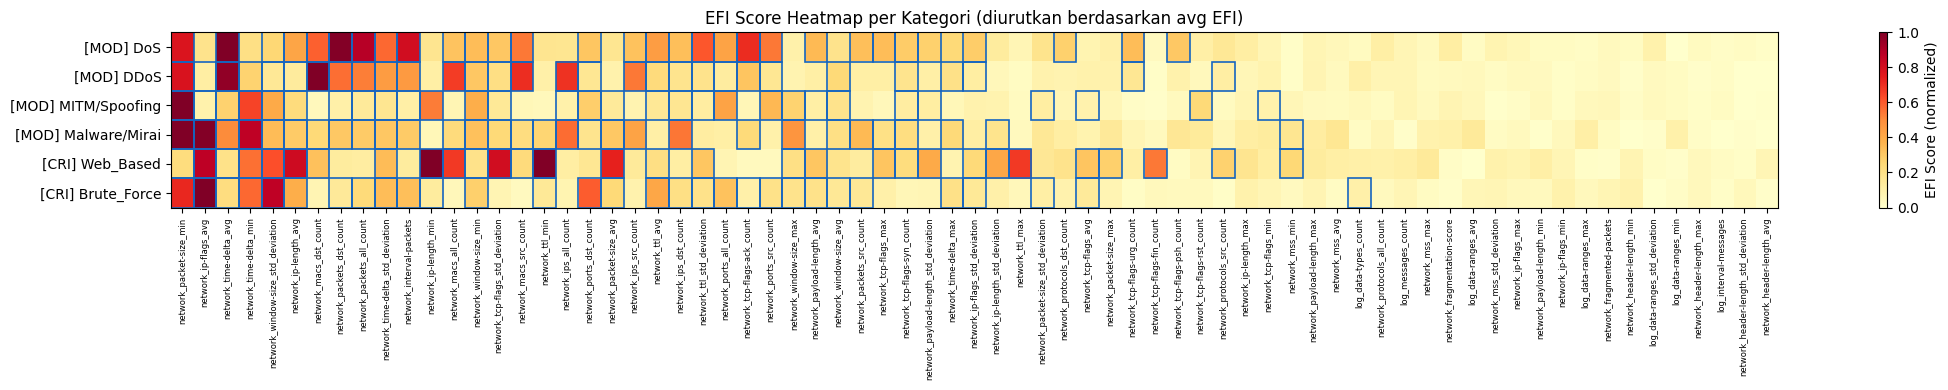

  Figure 1 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah5_CAFW_EFI_Heatmap.png


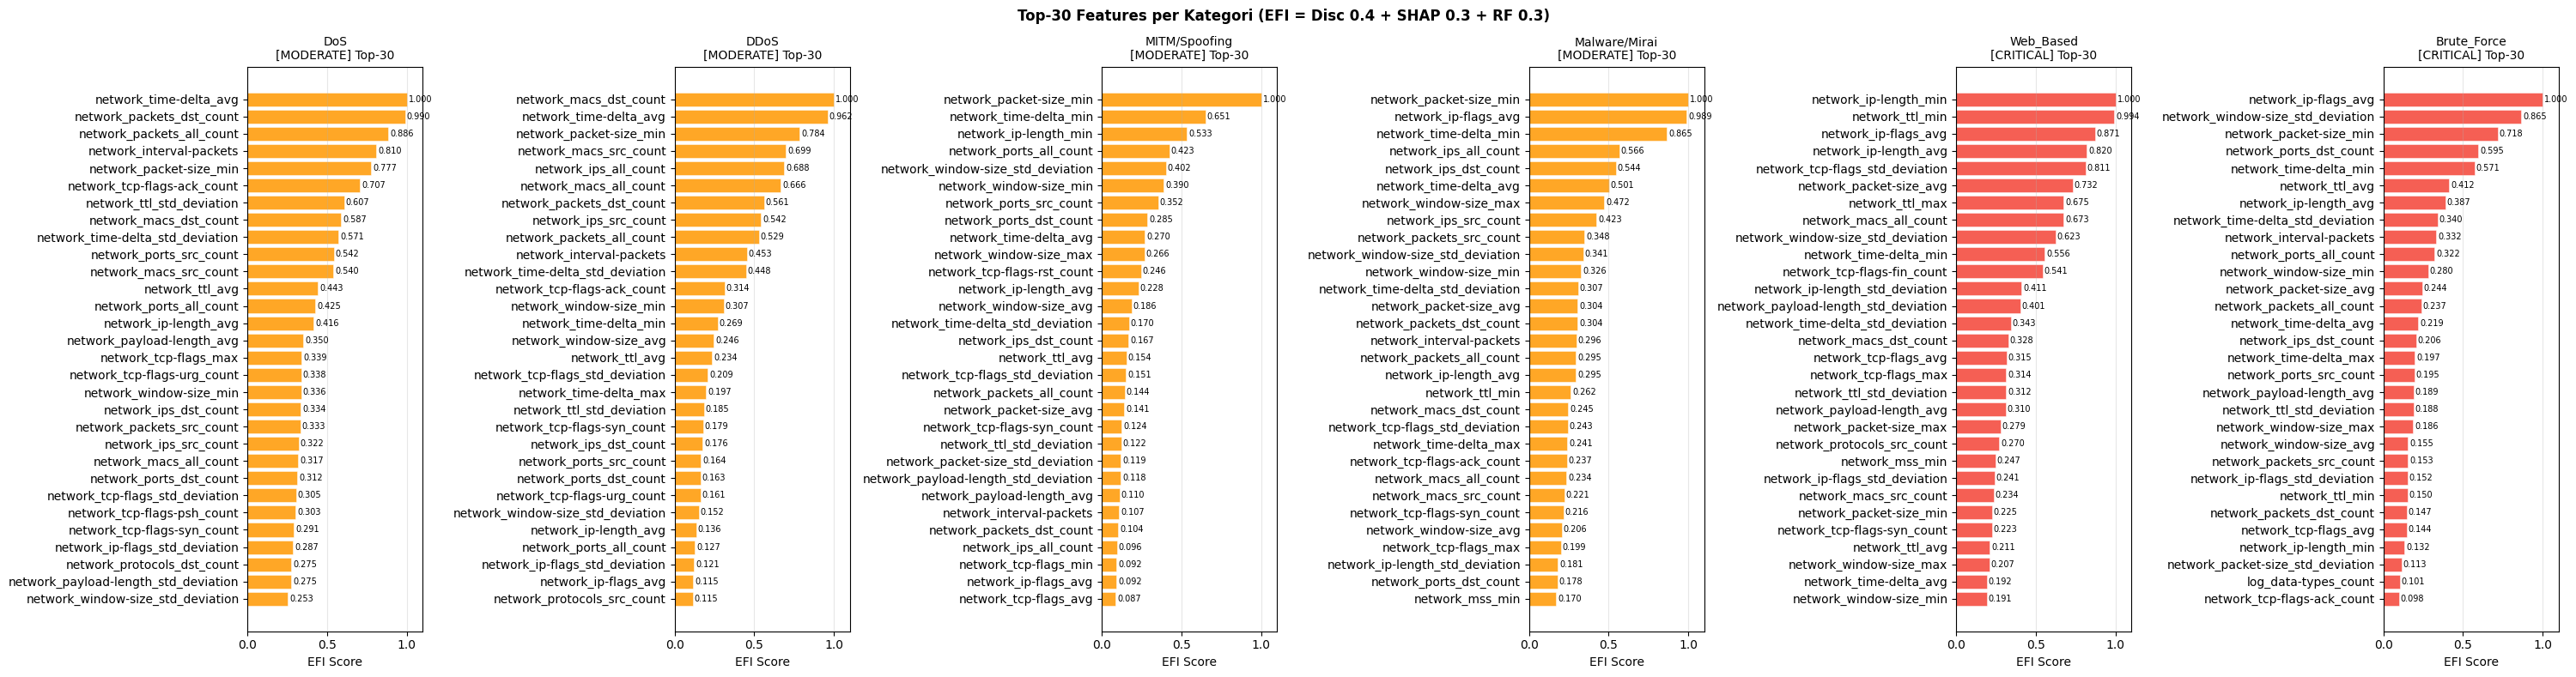

  Figure 2 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah5_CAFW_Top30_per_Kategori.png


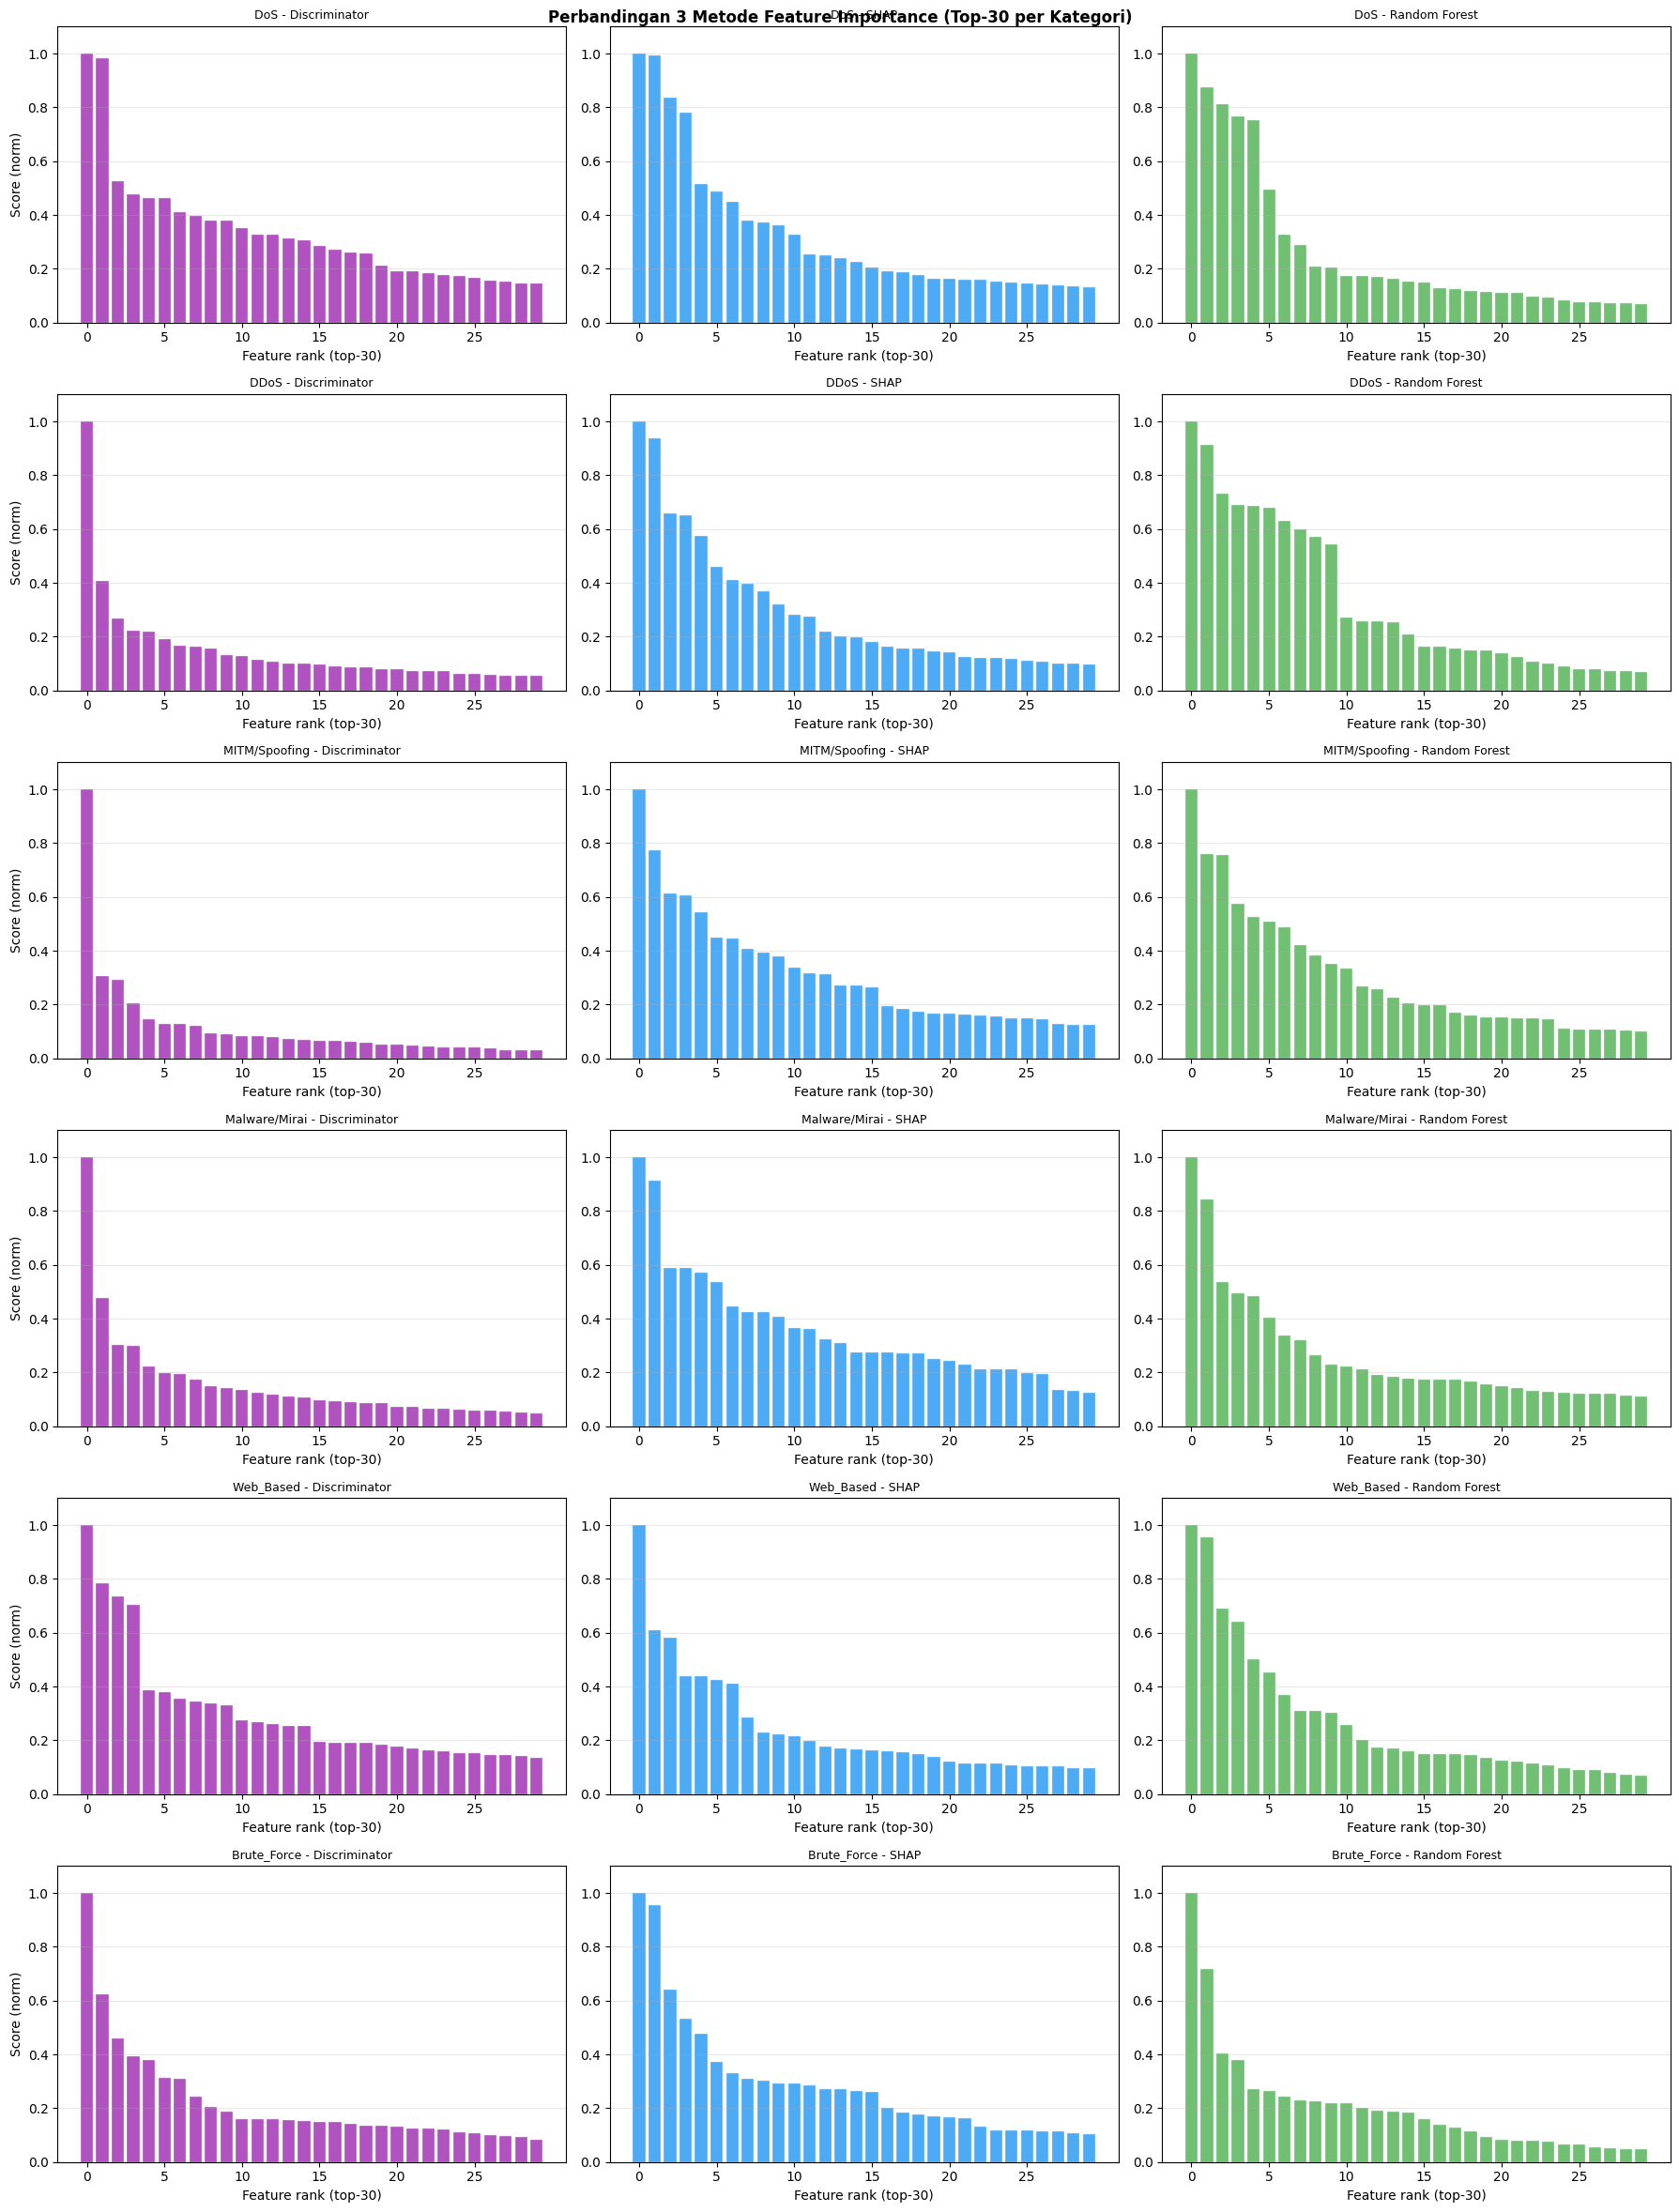

  Figure 3 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah5_CAFW_Perbandingan_3_Metode.png


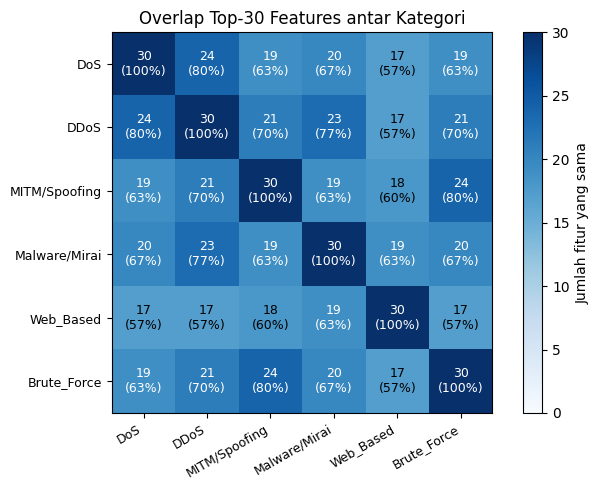

  Figure 4 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah5_CAFW_Overlap_Antar_Kategori.png


In [ ]:
print("Membuat visualisasi")
print("-" * 40)

seg_colors_cafw = {'moderate': '#FF9800', 'critical': '#F44336'}
n_cats = len(TARGET_CATS)

# Figure 1: EFI Heatmap
fig1, ax1 = plt.subplots(figsize=(22, 4))
avg_efi    = efi_matrix.mean(axis=0)
sort_idx   = np.argsort(avg_efi)[::-1]
efi_sort   = efi_matrix[:, sort_idx]
feat_sort_names = [feature_names[i] for i in sort_idx]
im = ax1.imshow(efi_sort, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax1.set_yticks(range(n_cats))
ax1.set_yticklabels(
    [f"[{cafw_results[c]['segment'][:3].upper()}] {c}" for c in TARGET_CATS], fontsize=10
)
ax1.set_xticks(range(n_features))
ax1.set_xticklabels(feat_sort_names, rotation=90, fontsize=6)
ax1.set_title('EFI Score Heatmap per Kategori (diurutkan berdasarkan avg EFI)', fontsize=12)
plt.colorbar(im, ax=ax1, label='EFI Score (normalized)')
for row_i, cat_name in enumerate(TARGET_CATS):
    top_set = set(cafw_results[cat_name]['top_30_indices'])
    for col_j, feat_idx in enumerate(sort_idx):
        if feat_idx in top_set:
            rect = plt.Rectangle((col_j-0.5, row_i-0.5), 1, 1,
                                  fill=False, edgecolor='#1565C0', linewidth=1.2)
            ax1.add_patch(rect)
plt.tight_layout()
path_fig1 = VISUALIZATION_DIR_IIOT + 'Langkah5_CAFW_EFI_Heatmap.png'
plt.savefig(path_fig1, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 1 tersimpan: {path_fig1}")

# Figure 2: Top-30 per kategori
fig2, axes2 = plt.subplots(1, n_cats, figsize=(5 * n_cats, 8))
if n_cats == 1:
    axes2 = [axes2]
for ax, cat_name in zip(axes2, TARGET_CATS):
    seg    = cafw_results[cat_name]['segment']
    color  = seg_colors_cafw[seg]
    names  = cafw_results[cat_name]['top_30_names']
    scores = cafw_results[cat_name]['top_30_scores']
    order  = np.argsort(scores)
    y_names  = [names[i] for i in order]
    y_scores = [scores[i] for i in order]
    bars = ax.barh(y_names, y_scores, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_xlabel('EFI Score')
    ax.set_title(f'{cat_name}\n[{seg.upper()}] Top-{TOP_K}', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.1)
    for bar, sc in zip(bars, y_scores):
        ax.text(sc + 0.01, bar.get_y() + bar.get_height()/2,
                f'{sc:.3f}', va='center', fontsize=7)
fig2.suptitle(f'Top-{TOP_K} Features per Kategori (EFI = Disc {W_DISC} + SHAP {W_SHAP} + RF {W_RF})',
              fontsize=12, fontweight='bold')
plt.tight_layout()
path_fig2 = VISUALIZATION_DIR_IIOT + 'Langkah5_CAFW_Top30_per_Kategori.png'
plt.savefig(path_fig2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 2 tersimpan: {path_fig2}")

# Figure 3: Perbandingan 3 metode
method_info = [
    ('disc_norm', 'Discriminator', '#9C27B0'),
    ('shap_norm', 'SHAP',          '#2196F3'),
    ('rf_norm',   'Random Forest', '#4CAF50'),
]
fig3, axes3 = plt.subplots(n_cats, 3, figsize=(18, 4 * n_cats), sharey=False)
if n_cats == 1:
    axes3 = [axes3]
for row_i, cat_name in enumerate(TARGET_CATS):
    for col_j, (mkey, mname, mcolor) in enumerate(method_info):
        ax       = axes3[row_i][col_j]
        scores_m = np.array(cafw_results[cat_name][mkey])
        top_idx  = np.argsort(scores_m)[-TOP_K:][::-1]
        ax.bar(range(TOP_K), scores_m[top_idx], color=mcolor, alpha=0.8,
               edgecolor='white', linewidth=0.3)
        ax.set_title(f'{cat_name} - {mname}', fontsize=9)
        ax.set_xlabel('Feature rank (top-30)')
        ax.set_ylabel('Score (norm)' if col_j == 0 else '')
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticks(range(0, TOP_K, 5))
fig3.suptitle('Perbandingan 3 Metode Feature Importance (Top-30 per Kategori)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
path_fig3 = VISUALIZATION_DIR_IIOT + 'Langkah5_CAFW_Perbandingan_3_Metode.png'
plt.savefig(path_fig3, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 3 tersimpan: {path_fig3}")

# Figure 4: Overlap heatmap
n_c         = n_cats
overlap_mat = np.zeros((n_c, n_c), dtype=int)
for i, cat_a in enumerate(TARGET_CATS):
    for j, cat_b in enumerate(TARGET_CATS):
        overlap_mat[i, j] = len(feat_sets[cat_a] & feat_sets[cat_b])
fig4, ax4 = plt.subplots(figsize=(7, 5))
im4 = ax4.imshow(overlap_mat, cmap='Blues', vmin=0, vmax=TOP_K)
ax4.set_xticks(range(n_c))
ax4.set_yticks(range(n_c))
ax4.set_xticklabels(TARGET_CATS, rotation=30, ha='right', fontsize=9)
ax4.set_yticklabels(TARGET_CATS, fontsize=9)
ax4.set_title(f'Overlap Top-{TOP_K} Features antar Kategori', fontsize=12)
plt.colorbar(im4, ax=ax4, label='Jumlah fitur yang sama')
for i in range(n_c):
    for j in range(n_c):
        pct = overlap_mat[i, j] / TOP_K * 100
        ax4.text(j, i, f'{overlap_mat[i,j]}\n({pct:.0f}%)',
                 ha='center', va='center', fontsize=9,
                 color='white' if overlap_mat[i, j] > TOP_K * 0.6 else 'black')
plt.tight_layout()
path_fig4 = VISUALIZATION_DIR_IIOT + 'Langkah5_CAFW_Overlap_Antar_Kategori.png'
plt.savefig(path_fig4, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 4 tersimpan: {path_fig4}")

####**5.7 Ringkasan**

In [ ]:
print("Ringkasan Langkah 5 - Category-Aware Feature Weighting")
print("=" * 60)

print(f"\nMetode EFI : Discriminator ({W_DISC}) + SHAP ({W_SHAP}) + RF ({W_RF})")
print(f"Top-K      : {TOP_K} features per kategori")
print(f"Epsilon    : {EPSILON}")
print(f"\nHasil per kategori:")
print(f"  {'Kategori':<18} {'Segmen':<10} {'Samples':>8}  {'Top-3 Features'}")
print(f"  {'-'*75}")
for cat_name in TARGET_CATS:
    seg  = cafw_results[cat_name]['segment']
    n_s  = cafw_results[cat_name]['n_samples']
    top3 = cafw_results[cat_name]['top_30_names'][:3]
    print(f"  {cat_name:<18} {seg:<10} {n_s:>8,}  {', '.join(top3)}")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")
gc.collect()
print("gc.collect() selesai.")
print("\nLangkah 5 selesai. Siap lanjut ke Langkah 6 (CVAE).")
print("=" * 60)

Ringkasan Langkah 5 - Category-Aware Feature Weighting

Metode EFI : Discriminator (0.4) + SHAP (0.3) + RF (0.3)
Top-K      : 30 features per kategori
Epsilon    : 1e-05

Hasil per kategori:
  Kategori           Segmen      Samples  Top-3 Features
  ---------------------------------------------------------------------------
  DoS                moderate     49,107  network_time-delta_avg, network_packets_dst_count, network_packets_all_count
  DDoS               moderate     45,744  network_macs_dst_count, network_time-delta_avg, network_packet-size_min
  MITM/Spoofing      moderate     20,799  network_packet-size_min, network_time-delta_min, network_ip-length_min
  Malware/Mirai      moderate     20,195  network_packet-size_min, network_ip-flags_avg, network_time-delta_min
  Web_Based          critical      6,729  network_ip-length_min, network_ttl_min, network_ip-flags_avg
  Brute_Force        critical      4,055  network_ip-flags_avg, network_window-size_std_deviation, network_packet

##**Langkah 6: CVAE Training (untuk Moderate Classes)**

####**6.1 Setup dan Verifikasi**

In [ ]:
print("Setup dan verifikasi")
print("-" * 40)

# Konfigurasi CVAE sesuai spesifikasi
INPUT_DIM        = N_FEATURES          # 71
LATENT_DIM       = 128
BETA             = 0.75     # 75% reconstruction, 25% KL
BATCH_SIZE_CVAE  = 512
EPOCHS_CVAE      = 50
PATIENCE_CVAE    = 10
LR_CVAE          = 0.001
TOP_K            = 30

# Target augmentasi: bawa moderate ke ukuran kelas terbesar (Benign)
TARGET_PER_CLASS = int(max(counts_train.values()))   # 163,578

# Konfigurasi validasi
N_TSNE_PER_CLASS = 500    # samples per kelas untuk t-SNE
N_KS_SAMPLES     = 5000  # samples untuk KS-test
RANDOM_STATE     = 42

print(f"Arsitektur CVAE:")
print(f"  Input dim  : {INPUT_DIM}")
print(f"  Encoder    : {INPUT_DIM} -> 128 -> 64 -> Latent({LATENT_DIM})")
print(f"  Decoder    : Latent({LATENT_DIM}) -> 64 -> 128 -> {INPUT_DIM}")
print(f"  Beta       : {BETA} (recon={BETA}, KL={round(1-BETA, 2)})")
print(f"  Batch size : {BATCH_SIZE_CVAE}")
print(f"  Epochs     : {EPOCHS_CVAE} (early stopping patience={PATIENCE_CVAE})")
print(f"  Optimizer  : Adam (lr={LR_CVAE})")
print(f"  Target/kls : {TARGET_PER_CLASS:,}")

# Verifikasi data moderate di memory
print(f"\nVerifikasi data moderate:")
print(f"  X_moderate : {X_moderate.shape}")
print(f"  y_moderate : {y_moderate.shape}")

print(f"\nRincian augmentasi per kelas:")
for cat in moderate_cats:
    enc  = NAME_TO_ENC_IIOT[cat]
    cnt  = int(np.sum(y_moderate == enc))
    need = max(0, TARGET_PER_CLASS - cnt)
    print(f"  {cat:<18} : {cnt:>9,} real -> perlu {need:>9,} synthetic")

# Verifikasi CAFW results
print(f"\nVerifikasi CAFW results:")
for cat in moderate_cats:
    n_top = len(cafw_results[cat]['top_30_indices'])
    print(f"  {cat}: {n_top} top features [OK]")

os.makedirs(CVAE_DIR_IIOT, exist_ok=True)
mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")

Setup dan verifikasi
----------------------------------------
Arsitektur CVAE:
  Input dim  : 71
  Encoder    : 71 -> 128 -> 64 -> Latent(128)
  Decoder    : Latent(128) -> 64 -> 128 -> 71
  Beta       : 0.75 (recon=0.75, KL=0.25)
  Batch size : 512
  Epochs     : 50 (early stopping patience=10)
  Optimizer  : Adam (lr=0.001)
  Target/kls : 163,578

Verifikasi data moderate:
  X_moderate : (135845, 71)
  y_moderate : (135845,)

Rincian augmentasi per kelas:
  DoS                :    49,107 real -> perlu   114,471 synthetic
  DDoS               :    45,744 real -> perlu   117,834 synthetic
  MITM/Spoofing      :    20,799 real -> perlu   142,779 synthetic
  Malware/Mirai      :    20,195 real -> perlu   143,383 synthetic

Verifikasi CAFW results:
  DoS: 30 top features [OK]
  DDoS: 30 top features [OK]
  MITM/Spoofing: 30 top features [OK]
  Malware/Mirai: 30 top features [OK]

RAM tersisa: 46.26 GB


####**6.2 Persiapan data untuk CVAE**

In [ ]:
print("Persiapan data untuk CVAE")

moderate_data = {}

for cat in moderate_cats:
    enc    = NAME_TO_ENC_IIOT[cat]
    mask   = (y_moderate == enc)
    X_cat  = X_moderate[mask].astype(np.float32)
    y_cat  = y_moderate[mask]

    # Hitung feature weights dari EFI scores
    efi_raw = np.array(cafw_results[cat]['efi_scores'], dtype=np.float32)

    # Floor 0.01 agar semua fitur tetap berkontribusi
    # Normalisasi agar mean weight = 1.0 (skala loss stabil)
    efi_floored   = np.clip(efi_raw, 0.01, 1.0)
    feature_weights = efi_floored / efi_floored.mean()

    n_need = max(0, TARGET_PER_CLASS - len(X_cat))

    moderate_data[cat] = {
        'X'               : X_cat,
        'y'               : y_cat,
        'enc'             : int(enc),
        'n_real'          : int(len(X_cat)),
        'n_synthetic'     : int(n_need),
        'top_k_indices'   : cafw_results[cat]['top_30_indices'],
        'efi_scores'      : efi_raw,
        'feature_weights' : feature_weights,
    }

    print(f"\n  [{cat}]")
    print(f"    X shape         : {X_cat.shape}")
    print(f"    Encoded label   : {enc}")
    print(f"    Synthetic needed: {n_need:,}")
    print(f"    Weight min/max  : {feature_weights.min():.4f} / {feature_weights.max():.4f}")
    print(f"    Weight mean     : {feature_weights.mean():.4f}")

    # Validasi NaN/Inf
    n_nan = np.isnan(X_cat).sum()
    n_inf = np.isinf(X_cat).sum()
    if n_nan == 0 and n_inf == 0:
        print(f"    NaN/Inf check   : OK")
    else:
        print(f"    NaN/Inf check   : {n_nan} NaN, {n_inf} Inf -> diperbaiki")
        moderate_data[cat]['X'] = np.nan_to_num(X_cat, nan=0.0, posinf=1.0, neginf=-1.0)

print("\nPersiapan data selesai.")

Persiapan data untuk CVAE

  [DoS]
    X shape         : (49107, 71)
    Encoded label   : 3
    Synthetic needed: 114,471
    Weight min/max  : 0.0396 / 3.9640
    Weight mean     : 1.0000
    NaN/Inf check   : OK

  [DDoS]
    X shape         : (45744, 71)
    Encoded label   : 2
    Synthetic needed: 117,834
    Weight min/max  : 0.0537 / 5.3659
    Weight mean     : 1.0000
    NaN/Inf check   : OK

  [MITM/Spoofing]
    X shape         : (20799, 71)
    Encoded label   : 4
    Synthetic needed: 142,779
    Weight min/max  : 0.0776 / 7.7553
    Weight mean     : 1.0000
    NaN/Inf check   : OK

  [Malware/Mirai]
    X shape         : (20195, 71)
    Encoded label   : 5
    Synthetic needed: 143,383
    Weight min/max  : 0.0500 / 4.9997
    Weight mean     : 1.0000
    NaN/Inf check   : OK

Persiapan data selesai.


####**6.3 Definisi Arsitektur CVAE**

In [ ]:
print("Definisi arsitektur CVAE")

class CVAEEncoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense1    = layers.Dense(128, activation='relu', name='enc_d1')
        self.dense2    = layers.Dense(64,  activation='relu', name='enc_d2')
        self.mu_layer  = layers.Dense(latent_dim, name='enc_mu')
        self.lv_layer  = layers.Dense(latent_dim, name='enc_logvar')

    def call(self, x, training=False):
        h = self.dense1(x)
        h = self.dense2(h)
        return self.mu_layer(h), self.lv_layer(h)

class CVAEDecoder(tf.keras.layers.Layer):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(64,  activation='relu', name='dec_d1')
        self.dense2 = layers.Dense(128, activation='relu', name='dec_d2')
        self.out    = layers.Dense(output_dim, name='dec_out')

    def call(self, z, training=False):
        h = self.dense1(z)
        h = self.dense2(h)
        return self.out(h)

class CVAE(tf.keras.Model):
    def __init__(self, input_dim, latent_dim, feature_weights, beta=0.75, **kwargs):
        super().__init__(**kwargs)
        self.input_dim  = input_dim
        self.latent_dim = latent_dim
        self.beta       = beta
        self.fw         = tf.constant(feature_weights, dtype=tf.float32)
        self.encoder    = CVAEEncoder(latent_dim)
        self.decoder    = CVAEDecoder(input_dim)
        self.total_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = tf.keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def reparameterize(self, mu, log_var):
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * tf.exp(0.5 * log_var)

    def call(self, x, training=False):
        mu, log_var = self.encoder(x, training=training)
        z           = self.reparameterize(mu, log_var)
        x_recon     = self.decoder(z, training=training)
        return x_recon, mu, log_var

    def compute_loss(self, x):
        x_recon, mu, log_var = self(x, training=True)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(self.fw * tf.square(x - x_recon), axis=1)
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        )
        total_loss = self.beta * recon_loss + (1.0 - self.beta) * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_loss(x)
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        total_loss, recon_loss, kl_loss = self.compute_loss(x)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def generate(self, n_samples, seed=42):
        tf.random.set_seed(seed)
        z = tf.random.normal(shape=(n_samples, self.latent_dim))
        return self.decoder(z, training=False).numpy()

print("Kelas CVAE berhasil didefinisikan:")
print(f"  CVAEEncoder : input -> Dense(128,ReLU) -> Dense(64,ReLU) -> [mu, log_var]({LATENT_DIM})")
print(f"  CVAEDecoder : z({LATENT_DIM}) -> Dense(64,ReLU) -> Dense(128,ReLU) -> output({INPUT_DIM})")
print(f"  CVAE loss   : {BETA}*weighted_recon + {round(1-BETA,2)}*KL")

Definisi arsitektur CVAE
Kelas CVAE berhasil didefinisikan:
  CVAEEncoder : input -> Dense(128,ReLU) -> Dense(64,ReLU) -> [mu, log_var](128)
  CVAEDecoder : z(128) -> Dense(64,ReLU) -> Dense(128,ReLU) -> output(71)
  CVAE loss   : 0.75*weighted_recon + 0.25*KL


####**6.4 Training CVAE dan Generate Synthetic Samples per Kategori**

In [ ]:
print("Training CVAE dan generate synthetic samples")
print("-" * 40)

# Storage untuk hasil per kategori
cvae_models      = {}
synthetic_data   = {}
training_history = {}
t_total = time.time()

for idx_cat, cat in enumerate(moderate_cats):
    print(f"\n{'='*55}")
    print(f"[{idx_cat+1}/{len(moderate_cats)}] Kategori: {cat}")
    print(f"{'='*55}")
    t_cat   = time.time()
    cdata   = moderate_data[cat]
    X_cat   = cdata['X']
    n_real  = cdata['n_real']
    n_synth = cdata['n_synthetic']
    enc_lbl = cdata['enc']

    if n_synth == 0:
        print(f"  Sudah >= {TARGET_PER_CLASS:,} samples, tidak perlu augmentasi.")
        synthetic_data[cat] = {
            'X_synthetic': np.empty((0, INPUT_DIM), dtype=np.float32),
            'y_synthetic': np.empty((0,), dtype=np.int64),
            'n_synthetic': 0,
        }
        continue

    # [a] Bangun CVAE
    print(f"\n  [a] Membangun CVAE...")
    tf.keras.backend.clear_session()
    safe_cat_name = cat.replace('/', '_')
    cvae = CVAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
                feature_weights=cdata['feature_weights'], beta=BETA, name=f'cvae_{safe_cat_name}')
    cvae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_CVAE))
    _ = cvae(tf.zeros((1, INPUT_DIM)))
    n_params = cvae.count_params()
    print(f"    Total parameter : {n_params:,}")

    # [b] Training CVAE
    print(f"\n  [b] Training CVAE pada {n_real:,} samples...")
    print(f"    Epochs max: {EPOCHS_CVAE} | Patience: {PATIENCE_CVAE} | Batch: {BATCH_SIZE_CVAE}")
    callbacks_cvae = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE_CVAE,
                                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-5, verbose=0)
    ]
    t_train = time.time()
    history = cvae.fit(
        X_cat, X_cat,
        epochs=EPOCHS_CVAE, batch_size=BATCH_SIZE_CVAE,
        validation_split=0.1, callbacks=callbacks_cvae,
        verbose=0, shuffle=True
    )
    elapsed_train   = time.time() - t_train
    n_epochs_run    = len(history.history['loss'])
    final_loss      = history.history['loss'][-1]
    final_recon     = history.history['recon_loss'][-1]
    final_kl        = history.history['kl_loss'][-1]
    val_loss_fin    = history.history['val_loss'][-1]

    print(f"    Epochs dijalankan : {n_epochs_run}/{EPOCHS_CVAE}")
    print(f"    Train loss final  : {final_loss:.4f}")
    print(f"    Train recon loss  : {final_recon:.4f}")
    print(f"    Train KL loss     : {final_kl:.4f}")
    print(f"    Val loss final    : {val_loss_fin:.4f}")
    print(f"    Waktu training    : {elapsed_train:.1f} detik")

    training_history[cat] = {
        'loss'      : [float(v) for v in history.history['loss']],
        'recon_loss': [float(v) for v in history.history['recon_loss']],
        'kl_loss'   : [float(v) for v in history.history['kl_loss']],
        'val_loss'  : [float(v) for v in history.history['val_loss']],
        'n_epochs'  : n_epochs_run,
    }

    # [c] Generate synthetic samples
    print(f"\n  [c] Generate {n_synth:,} synthetic samples...")
    t_gen    = time.time()
    GEN_BATCH = 10000
    n_batches = (n_synth + GEN_BATCH - 1) // GEN_BATCH
    X_synth_parts = []
    for b in range(n_batches):
        n_this = min(GEN_BATCH, n_synth - b * GEN_BATCH)
        X_part = cvae.generate(n_this, seed=RANDOM_STATE + b)
        X_synth_parts.append(X_part)
        if (b + 1) % 5 == 0 or (b + 1) == n_batches:
            print(f"    Batch {b+1}/{n_batches} selesai | {min((b+1)*GEN_BATCH, n_synth):,} samples")

    X_synthetic = np.vstack(X_synth_parts).astype(np.float32)
    del X_synth_parts
    gc.collect()
    print(f"    Shape sebelum masking : {X_synthetic.shape}")

    # Masking: set non-top-30 ke 0
    top30_idx  = cdata['top_k_indices']
    mask_feat  = np.zeros(INPUT_DIM, dtype=bool)
    mask_feat[top30_idx] = True
    X_synthetic[:, ~mask_feat] = 0.0
    print(f"    Non-top-30 features   : {(~mask_feat).sum()} fitur di-zero")

    # Clip ke rentang wajar
    X_real_min = X_cat.min(axis=0)
    X_real_max = X_cat.max(axis=0)
    margin     = 0.1 * (X_real_max - X_real_min)
    X_synthetic = np.clip(X_synthetic, X_real_min - margin, X_real_max + margin)

    y_synthetic = np.full(n_synth, enc_lbl, dtype=np.int64)
    elapsed_gen = time.time() - t_gen

    n_nan_s = np.isnan(X_synthetic).sum()
    n_inf_s = np.isinf(X_synthetic).sum()
    print(f"    Shape setelah masking : {X_synthetic.shape}")
    print(f"    Waktu generate        : {elapsed_gen:.1f} detik")
    print(f"    NaN={n_nan_s}, Inf={n_inf_s}", end="")
    if n_nan_s == 0 and n_inf_s == 0:
        print(" [OK]")
    else:
        X_synthetic = np.nan_to_num(X_synthetic, nan=0.0, posinf=1.0, neginf=-1.0)
        print(" -> diperbaiki")

    synthetic_data[cat] = {
        'X_synthetic': X_synthetic,
        'y_synthetic': y_synthetic,
        'n_synthetic': n_synth,
    }

    weights_path = os.path.join(CVAE_DIR_IIOT, f'cvae_weights_{safe_cat_name}.weights.h5')
    cvae.save_weights(weights_path)
    np.save(os.path.join(CVAE_DIR_IIOT, f'X_synthetic_{safe_cat_name}.npy'), X_synthetic)
    np.save(os.path.join(CVAE_DIR_IIOT, f'y_synthetic_{safe_cat_name}.npy'), y_synthetic)

    hist_path = os.path.join(CVAE_DIR_IIOT, f'cvae_history_{safe_cat_name}.json')
    with open(hist_path, 'w') as f:
        json.dump(training_history[cat], f, indent=4)

    cvae_models[cat] = cvae
    elapsed_cat = time.time() - t_cat
    print(f"\n    Model weights tersimpan : {weights_path}")
    print(f"    Total waktu [{cat}]      : {elapsed_cat:.1f} detik")
    mem = psutil.virtual_memory()
    print(f"    RAM tersisa             : {mem.available / 1024**3:.2f} GB")
    gc.collect()

elapsed_total_train = time.time() - t_total
print(f"\nSemua CVAE selesai ditraining dalam {elapsed_total_train/60:.1f} menit")

Training CVAE dan generate synthetic samples
----------------------------------------

[1/4] Kategori: DoS

  [a] Membangun CVAE...
    Total parameter : 59,847

  [b] Training CVAE pada 49,107 samples...
    Epochs max: 50 | Patience: 10 | Batch: 512
    Epochs dijalankan : 50/50
    Train loss final  : 3.7359
    Train recon loss  : 1.9061
    Train KL loss     : 9.2254
    Val loss final    : 6.1002
    Waktu training    : 22.2 detik

  [c] Generate 114,471 synthetic samples...
    Batch 5/12 selesai | 50,000 samples
    Batch 10/12 selesai | 100,000 samples
    Batch 12/12 selesai | 114,471 samples
    Shape sebelum masking : (114471, 71)
    Non-top-30 features   : 41 fitur di-zero
    Shape setelah masking : (114471, 71)
    Waktu generate        : 0.8 detik
    NaN=0, Inf=0 [OK]

    Model weights tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/04_CVAE/cvae_weights_DoS.weights.h5
    Total waktu [DoS]      : 24.5 detik
    RAM tersisa             : 45.76 GB

####**6.5 Validasi Synthetic Samples (t-SNE dan KS-test)**

In [ ]:
print("Validasi synthetic samples")
print("-" * 40)

ks_results_all = {}
rng_val        = np.random.default_rng(RANDOM_STATE)

for cat in moderate_cats:
    print(f"\n  Validasi [{cat}]")
    X_real  = moderate_data[cat]['X']
    n_synth = synthetic_data[cat]['n_synthetic']

    if n_synth == 0:
        print(f"    Tidak ada synthetic, skip validasi.")
        ks_results_all[cat] = {'skipped': True}
        continue

    X_synth   = synthetic_data[cat]['X_synthetic']
    top30_idx = moderate_data[cat]['top_k_indices']

    n_ks_real  = min(N_KS_SAMPLES, len(X_real))
    n_ks_synth = min(N_KS_SAMPLES, len(X_synth))
    idx_r = rng_val.choice(len(X_real),  size=n_ks_real,  replace=False)
    idx_s = rng_val.choice(len(X_synth), size=n_ks_synth, replace=False)
    X_r_ks = X_real[idx_r]
    X_s_ks = X_synth[idx_s]

    ks_pass  = 0
    ks_total = len(top30_idx)
    ks_stats = {}

    for feat_idx in top30_idx:
        stat, pval = ks_2samp(X_r_ks[:, feat_idx], X_s_ks[:, feat_idx])
        passed     = pval > 0.05
        if passed:
            ks_pass += 1
        ks_stats[feature_names[feat_idx]] = {
            'statistic': round(float(stat), 6),
            'p_value'  : round(float(pval), 6),
            'passed'   : bool(passed)
        }

    ks_pass_rate = ks_pass / ks_total * 100
    ks_results_all[cat] = {
        'pass_count': ks_pass, 'total': ks_total,
        'pass_rate' : round(ks_pass_rate, 2), 'details': ks_stats,
    }

    print(f"    KS-test top-{TOP_K} features:")
    print(f"    Pass            : {ks_pass}/{ks_total} fitur ({ks_pass_rate:.1f}%)")
    print(f"    Threshold p-val : 0.05")

    sorted_ks = sorted(ks_stats.items(), key=lambda x: x[1]['statistic'], reverse=True)
    print(f"    Top-5 fitur paling berbeda:")
    for fname_ks, fstat in sorted_ks[:5]:
        status = "PASS" if fstat['passed'] else "FAIL"
        print(f"      {fname_ks:<35} stat={fstat['statistic']:.4f} "
              f"pval={fstat['p_value']:.4f} [{status}]")

    del X_r_ks, X_s_ks

ks_path = os.path.join(CVAE_DIR_IIOT, 'cvae_ks_test_results.json')
with open(ks_path, 'w') as f:
    json.dump(ks_results_all, f, indent=4)
print(f"\n  KS-test results tersimpan: {ks_path}")

Validasi synthetic samples
----------------------------------------

  Validasi [DoS]
    KS-test top-30 features:
    Pass            : 1/30 fitur (3.3%)
    Threshold p-val : 0.05
    Top-5 fitur paling berbeda:
      network_interval-packets            stat=0.5568 pval=0.0000 [FAIL]
      network_packet-size_min             stat=0.5242 pval=0.0000 [FAIL]
      network_time-delta_avg              stat=0.4932 pval=0.0000 [FAIL]
      network_tcp-flags-syn_count         stat=0.4794 pval=0.0000 [FAIL]
      network_tcp-flags-psh_count         stat=0.4546 pval=0.0000 [FAIL]

  Validasi [DDoS]
    KS-test top-30 features:
    Pass            : 1/30 fitur (3.3%)
    Threshold p-val : 0.05
    Top-5 fitur paling berbeda:
      network_time-delta_min              stat=0.5294 pval=0.0000 [FAIL]
      network_ttl_avg                     stat=0.4654 pval=0.0000 [FAIL]
      network_interval-packets            stat=0.4546 pval=0.0000 [FAIL]
      network_packet-size_min             stat=0.4370 p


Membuat visualisasi training loss curves...


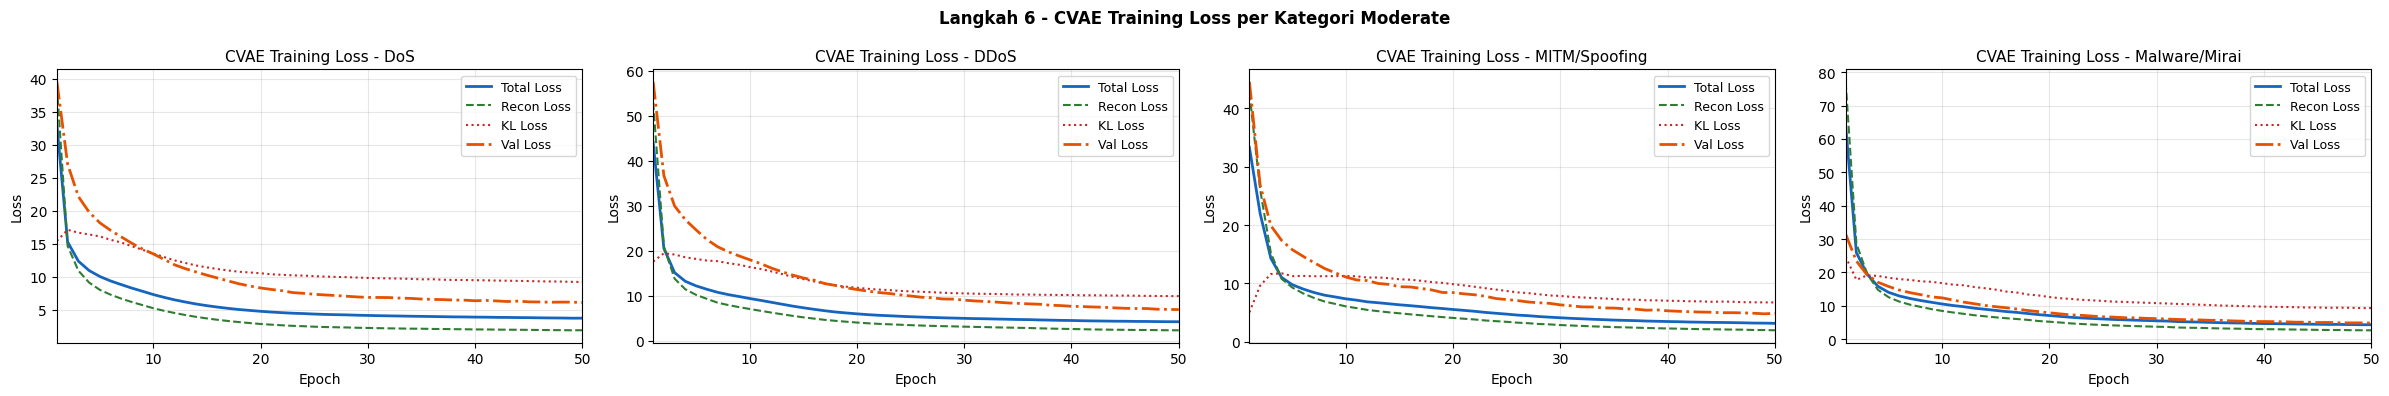

  Figure loss tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah6_CVAE_Training_Loss.png


In [ ]:
# Visualisasi 6.5a: Training loss curves
print("\nMembuat visualisasi training loss curves...")
n_cats_plot = len(moderate_cats)
fig_loss, axes_loss = plt.subplots(1, n_cats_plot, figsize=(6 * n_cats_plot, 4))
if n_cats_plot == 1:
    axes_loss = [axes_loss]
for ax, cat in zip(axes_loss, moderate_cats):
    if cat not in training_history:
        continue
    hist = training_history[cat]
    ep   = range(1, len(hist['loss']) + 1)
    ax.plot(ep, hist['loss'],       label='Total Loss', color='#1565C0', linewidth=2)
    ax.plot(ep, hist['recon_loss'], label='Recon Loss', color='#2E7D32', linewidth=1.5, linestyle='--')
    ax.plot(ep, hist['kl_loss'],    label='KL Loss',    color='#C62828', linewidth=1.5, linestyle=':')
    ax.plot(ep, hist['val_loss'],   label='Val Loss',   color='#E65100', linewidth=2,   linestyle='-.')
    ax.set_title(f'CVAE Training Loss - {cat}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(1, len(hist['loss']))
fig_loss.suptitle('Langkah 6 - CVAE Training Loss per Kategori Moderate', fontsize=12, fontweight='bold')
plt.tight_layout()
path_loss = VISUALIZATION_DIR_IIOT + 'Langkah6_CVAE_Training_Loss.png'
plt.savefig(path_loss, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure loss tersimpan: {path_loss}")

Membuat visualisasi t-SNE (subsample)...
  t-SNE [DoS]: 500 real + 500 synthetic = 1000 total
  t-SNE selesai dalam 3.5 detik
  t-SNE [DDoS]: 500 real + 500 synthetic = 1000 total
  t-SNE selesai dalam 2.7 detik
  t-SNE [MITM/Spoofing]: 500 real + 500 synthetic = 1000 total
  t-SNE selesai dalam 2.5 detik
  t-SNE [Malware/Mirai]: 500 real + 500 synthetic = 1000 total
  t-SNE selesai dalam 2.5 detik


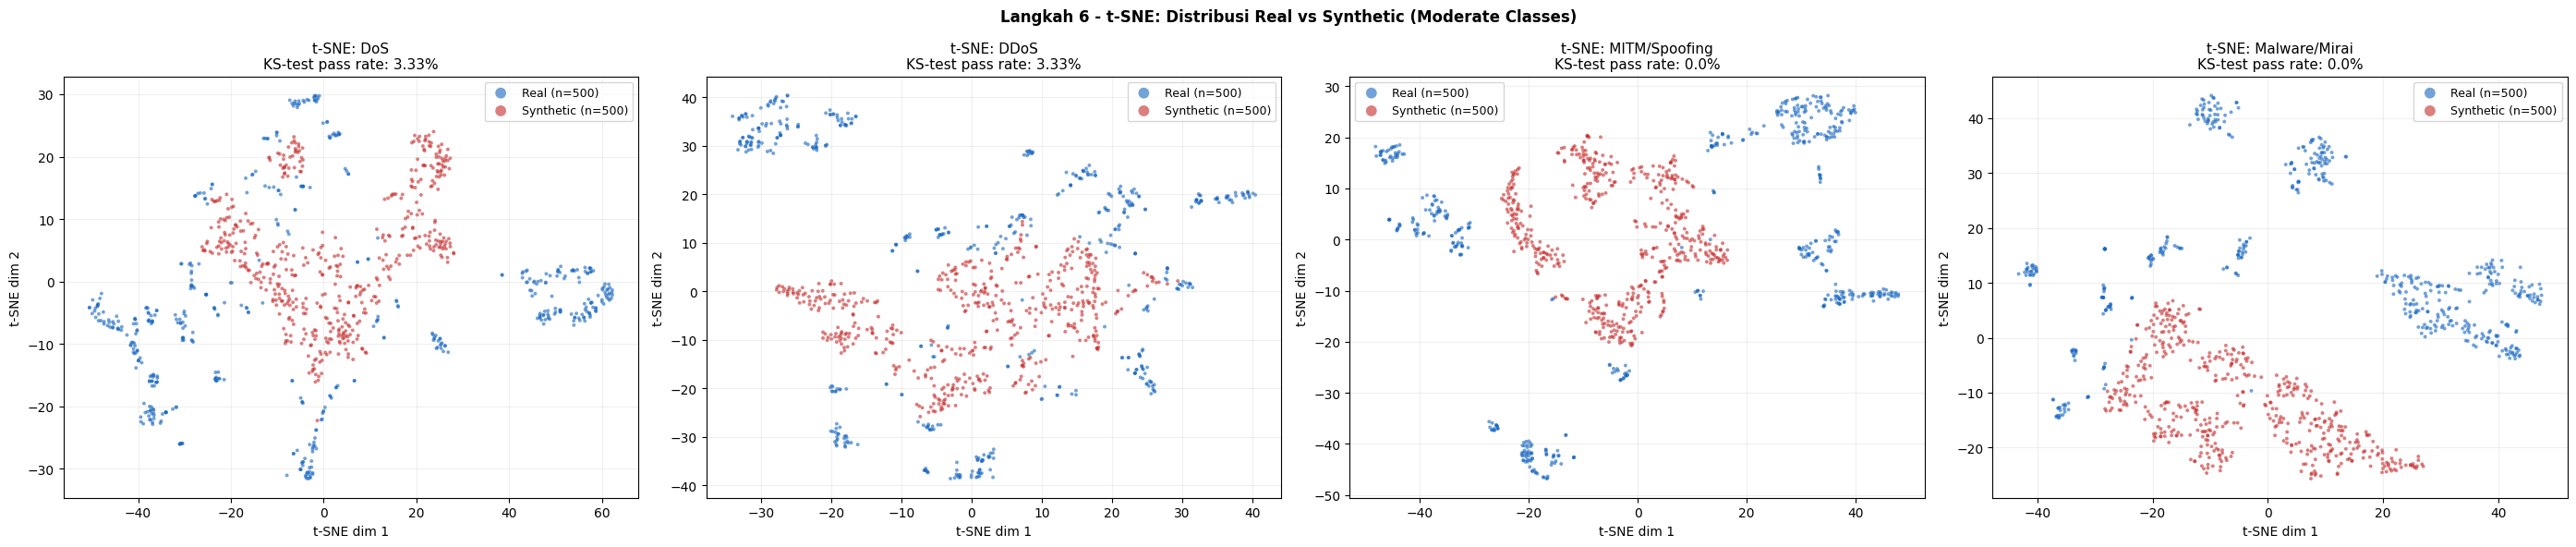

  Figure t-SNE tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah6_CVAE_tSNE_Real_vs_Synthetic.png


In [ ]:
# Visualisasi 6.5b: t-SNE real vs synthetic
print("Membuat visualisasi t-SNE (subsample)...")

cats_with_synth = [c for c in moderate_cats if synthetic_data[c]['n_synthetic'] > 0]
n_tsne_cats     = len(cats_with_synth)
fig_tsne, axes_tsne = plt.subplots(1, n_tsne_cats, figsize=(7 * n_tsne_cats, 6))
if n_tsne_cats == 1:
    axes_tsne = [axes_tsne]
for ax, cat in zip(axes_tsne, cats_with_synth):
    X_real_t = moderate_data[cat]['X']
    X_synth_t = synthetic_data[cat]['X_synthetic']
    n_r = min(N_TSNE_PER_CLASS, len(X_real_t))
    n_s = min(N_TSNE_PER_CLASS, len(X_synth_t))
    idx_r = rng_val.choice(len(X_real_t),  size=n_r, replace=False)
    idx_s = rng_val.choice(len(X_synth_t), size=n_s, replace=False)
    X_combined   = np.vstack([X_real_t[idx_r], X_synth_t[idx_s]])
    labels_tsne  = np.array(['Real'] * n_r + ['Synthetic'] * n_s)
    print(f"  t-SNE [{cat}]: {n_r} real + {n_s} synthetic = {n_r+n_s} total")
    tsne   = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000, verbose=0)
    t_tsne = time.time()
    X_2d   = tsne.fit_transform(X_combined)
    print(f"  t-SNE selesai dalam {time.time()-t_tsne:.1f} detik")
    colors_map = {'Real': '#1565C0', 'Synthetic': '#C62828'}
    for lbl in ['Real', 'Synthetic']:
        mask_lbl = (labels_tsne == lbl)
        ax.scatter(X_2d[mask_lbl, 0], X_2d[mask_lbl, 1],
                   c=colors_map[lbl], label=f'{lbl} (n={mask_lbl.sum():,})',
                   alpha=0.6, s=8, edgecolors='none')
    ks_rate = ks_results_all[cat].get('pass_rate', 'N/A')
    ax.set_title(f't-SNE: {cat}\nKS-test pass rate: {ks_rate}%', fontsize=11)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=9, markerscale=3)
    ax.grid(alpha=0.2)
    del X_combined, X_2d, labels_tsne
    gc.collect()
fig_tsne.suptitle('Langkah 6 - t-SNE: Distribusi Real vs Synthetic (Moderate Classes)',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
path_tsne = VISUALIZATION_DIR_IIOT + 'Langkah6_CVAE_tSNE_Real_vs_Synthetic.png'
plt.savefig(path_tsne, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure t-SNE tersimpan: {path_tsne}")

Membuat visualisasi distribusi fitur per kategori...


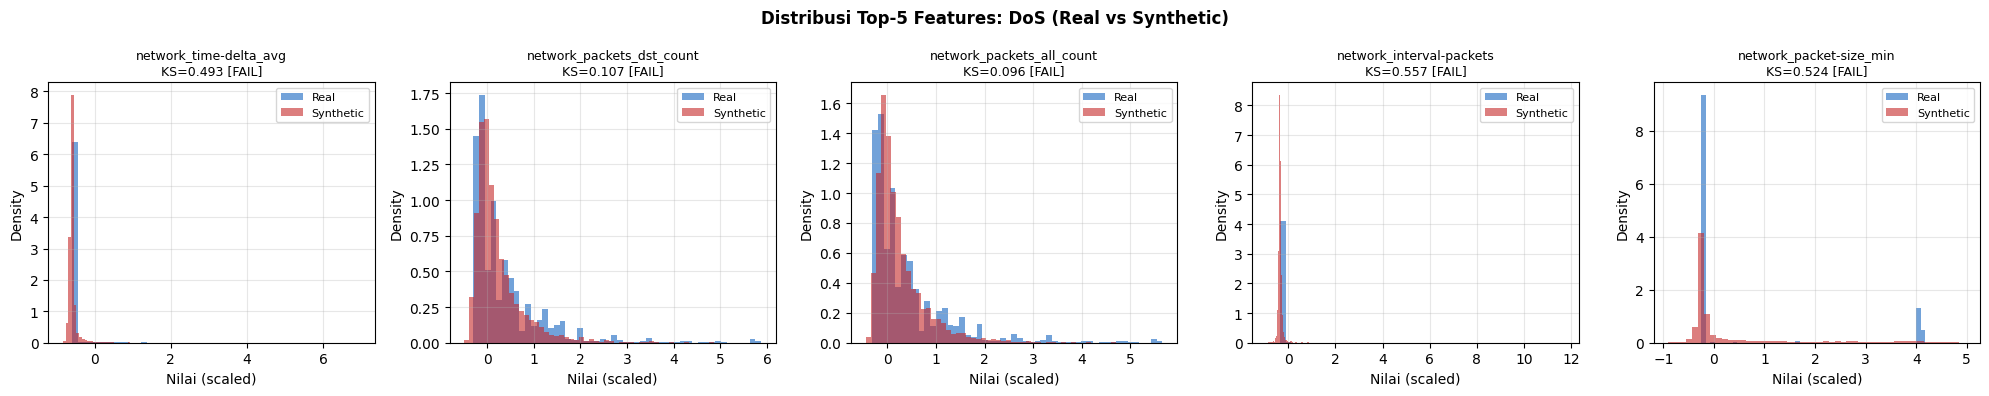

  Figure distribusi fitur [DoS] tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_DoS.png


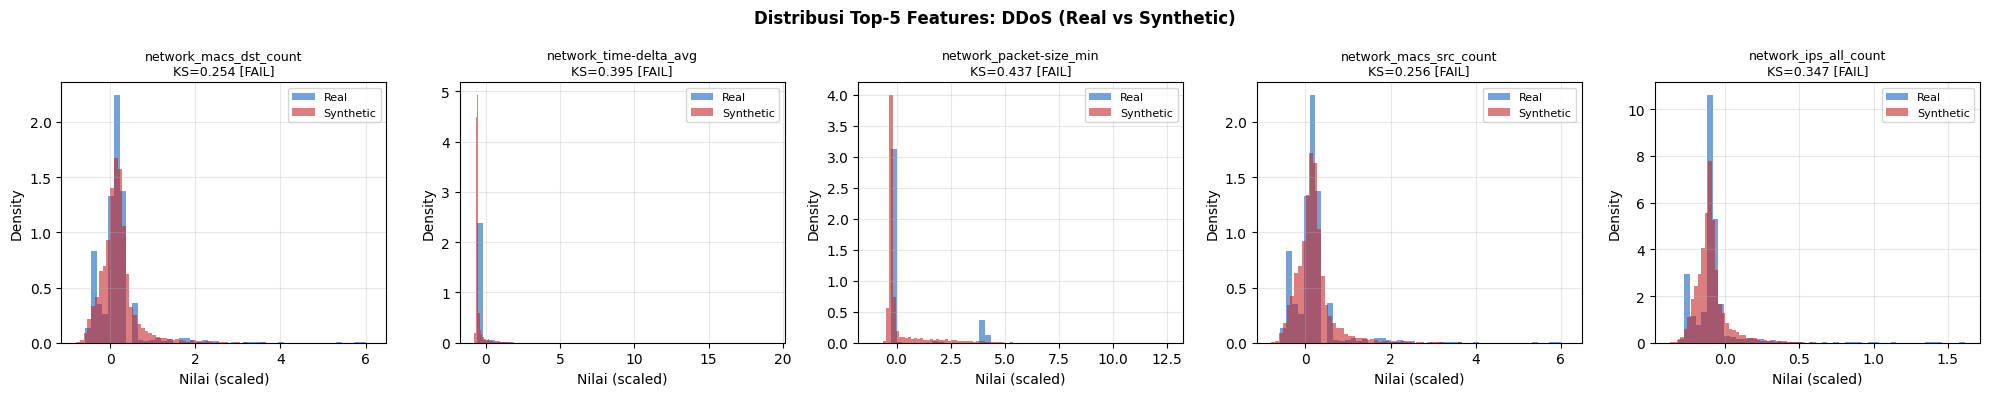

  Figure distribusi fitur [DDoS] tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_DDoS.png


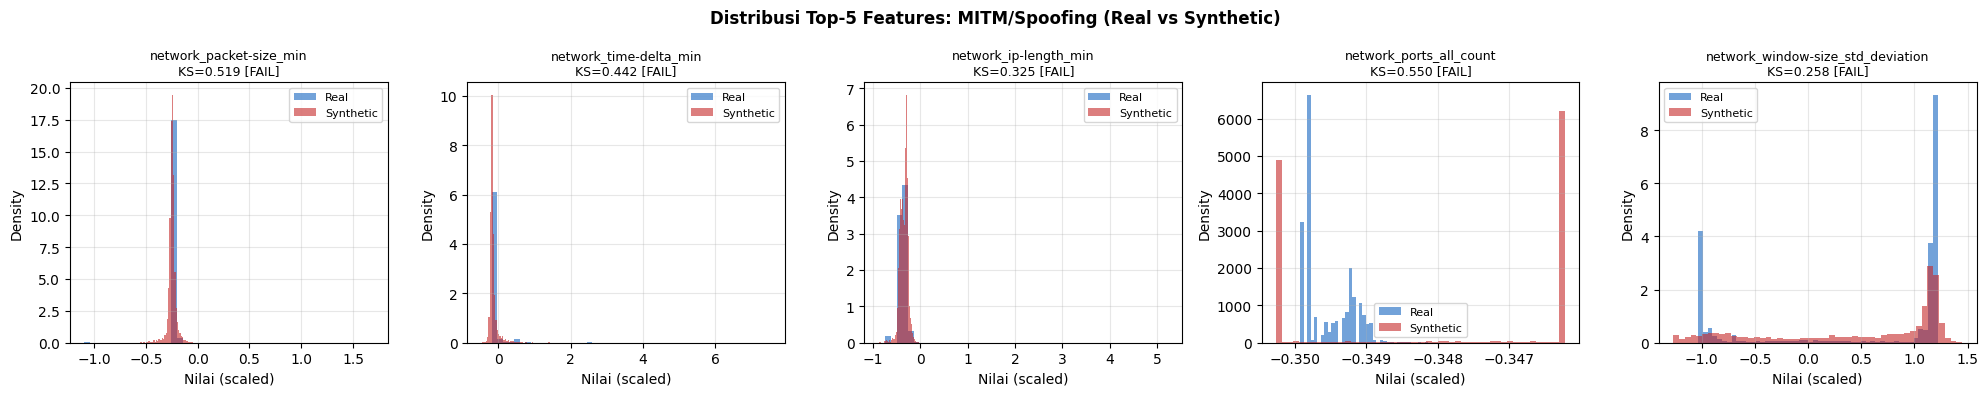

  Figure distribusi fitur [MITM/Spoofing] tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_MITM_Spoofing.png


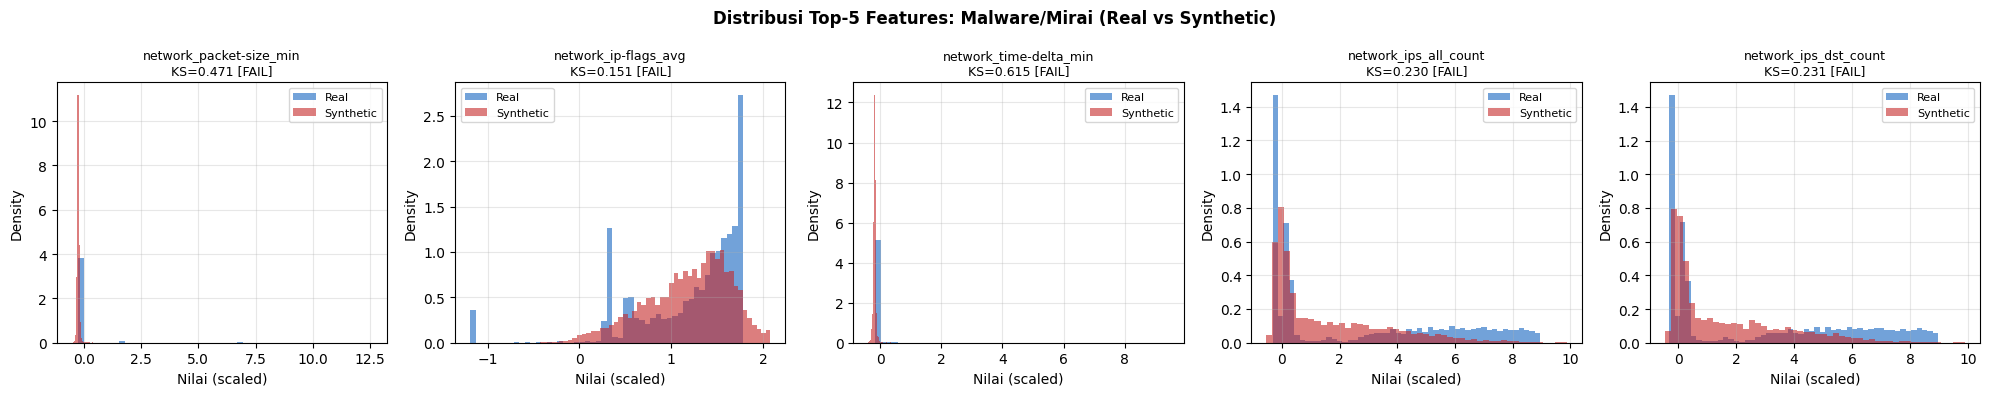

  Figure distribusi fitur [Malware/Mirai] tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_Malware_Mirai.png


In [ ]:
# Visualisasi 6.5c: Distribusi fitur top-5 real vs synthetic
print("Membuat visualisasi distribusi fitur per kategori...")

for cat in cats_with_synth:
    top5_idx   = moderate_data[cat]['top_k_indices'][:5]
    top5_names = [feature_names[i] for i in top5_idx]
    X_real_d   = moderate_data[cat]['X']
    X_synth_d  = synthetic_data[cat]['X_synthetic']
    n_plot     = min(5000, len(X_real_d), len(X_synth_d))
    idx_r      = rng_val.choice(len(X_real_d),  size=n_plot, replace=False)
    idx_s      = rng_val.choice(len(X_synth_d), size=n_plot, replace=False)
    fig_feat, axes_feat = plt.subplots(1, 5, figsize=(20, 4))
    fig_feat.suptitle(f'Distribusi Top-5 Features: {cat} (Real vs Synthetic)',
                      fontsize=12, fontweight='bold')
    for ax_f, feat_i, fname_f in zip(axes_feat, top5_idx, top5_names):
        ax_f.hist(X_real_d[idx_r, feat_i],  bins=50, alpha=0.6, color='#1565C0',
                  label='Real',      density=True)
        ax_f.hist(X_synth_d[idx_s, feat_i], bins=50, alpha=0.6, color='#C62828',
                  label='Synthetic', density=True)
        ks_info = ks_results_all[cat]['details'].get(fname_f, {})
        stat    = ks_info.get('statistic', 0)
        passed  = ks_info.get('passed', False)
        status  = "PASS" if passed else "FAIL"
        ax_f.set_title(f'{fname_f}\nKS={stat:.3f} [{status}]', fontsize=9)
        ax_f.set_xlabel('Nilai (scaled)')
        ax_f.set_ylabel('Density')
        ax_f.legend(fontsize=8)
        ax_f.grid(alpha=0.3)
    plt.tight_layout()
    safe_cat = cat.replace('/', '_')
    path_feat = VISUALIZATION_DIR_IIOT + f'Langkah6_CVAE_DistribusiFitur_{safe_cat}.png'
    plt.savefig(path_feat, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Figure distribusi fitur [{cat}] tersimpan: {path_feat}")
    del X_real_d, X_synth_d
    gc.collect()

####**6.6 Simpan Model dan Augmented Data**

In [ ]:
print("Menyimpan model dan augmented data moderate")

# --- Gabungkan real + synthetic per kategori -> augmented moderate ---
X_moderate_aug_parts = []
y_moderate_aug_parts = []

print("Menggabungkan real + synthetic per kategori:")
for cat in moderate_cats:
    enc   = moderate_data[cat]['enc']
    X_r   = moderate_data[cat]['X']
    y_r   = moderate_data[cat]['y']
    X_s   = synthetic_data[cat]['X_synthetic']
    y_s   = synthetic_data[cat]['y_synthetic']

    n_r = len(X_r)
    n_s = len(X_s)
    n_t = n_r + n_s

    X_moderate_aug_parts.append(X_r)
    y_moderate_aug_parts.append(y_r)

    if n_s > 0:
        X_moderate_aug_parts.append(X_s)
        y_moderate_aug_parts.append(y_s)

    print(f"  [{cat}]: {n_r:,} real + {n_s:,} synthetic = {n_t:,} total")

# Stack semua
X_moderate_augmented = np.vstack(X_moderate_aug_parts).astype(np.float32)
y_moderate_augmented = np.concatenate(y_moderate_aug_parts).astype(np.int64)

# Shuffle
shuffle_idx = np.random.default_rng(RANDOM_STATE).permutation(len(X_moderate_augmented))
X_moderate_augmented = X_moderate_augmented[shuffle_idx]
y_moderate_augmented = y_moderate_augmented[shuffle_idx]

del X_moderate_aug_parts, y_moderate_aug_parts, shuffle_idx
gc.collect()

print(f"\nHasil augmented moderate:")
print(f"  X_moderate_augmented : {X_moderate_augmented.shape}")
print(f"  y_moderate_augmented : {y_moderate_augmented.shape}")
print(f"  Distribusi akhir:")
for cat in moderate_cats:
    enc = moderate_data[cat]['enc']
    cnt = int(np.sum(y_moderate_augmented == enc))
    print(f"    {cat}: {cnt:,}")

# Simpan augmented moderate dataset
path_X_aug = os.path.join(CVAE_DIR_IIOT, 'X_moderate_augmented.npy')
path_y_aug = os.path.join(CVAE_DIR_IIOT, 'y_moderate_augmented.npy')
np.save(path_X_aug, X_moderate_augmented)
np.save(path_y_aug, y_moderate_augmented)

size_X = os.path.getsize(path_X_aug) / 1024**2
size_y = os.path.getsize(path_y_aug) / 1024**2
print(f"\n  Tersimpan:")
print(f"    {path_X_aug} ({size_X:.1f} MB)")
print(f"    {path_y_aug} ({size_y:.1f} MB)")

# Validasi load ulang
X_check = np.load(path_X_aug)
y_check = np.load(path_y_aug)
assert X_check.shape == X_moderate_augmented.shape, "ERROR: shape X tidak cocok!"
assert y_check.shape == y_moderate_augmented.shape, "ERROR: shape y tidak cocok!"
print(f"  Validasi load ulang: OK - shape {X_check.shape}")
del X_check, y_check
gc.collect()

# Simpan metadata CVAE
cvae_metadata = {
    'architecture': {
        'input_dim' : INPUT_DIM,
        'latent_dim': LATENT_DIM,
        'encoder'   : f'{INPUT_DIM}->128->64->Latent({LATENT_DIM})',
        'decoder'   : f'Latent({LATENT_DIM})->64->128->{INPUT_DIM}',
        'beta'      : BETA,
    },
    'training': {
        'batch_size': BATCH_SIZE_CVAE, 'epochs_max': EPOCHS_CVAE,
        'patience'  : PATIENCE_CVAE,   'lr': LR_CVAE, 'optimizer': 'Adam',
    },
    'augmentation': {
        'target_per_class': TARGET_PER_CLASS,
        'moderate_cats'   : moderate_cats,
        'feature_masking' : True, 'top_k': TOP_K,
    },
    'results': {
        cat: {
            'n_real'          : int(moderate_data[cat]['n_real']),
            'n_synthetic'     : int(synthetic_data[cat]['n_synthetic']),
            'n_total'         : int(moderate_data[cat]['n_real'] + synthetic_data[cat]['n_synthetic']),
            'n_epochs_trained': training_history.get(cat, {}).get('n_epochs', 0),
            'ks_pass_rate'    : ks_results_all.get(cat, {}).get('pass_rate', 'N/A'),
        }
        for cat in moderate_cats
    },
    'output': {
        'X_moderate_augmented': path_X_aug,
        'y_moderate_augmented': path_y_aug,
        'total_moderate_aug'  : int(len(X_moderate_augmented)),
    }
}

meta_path = os.path.join(CVAE_DIR_IIOT, 'cvae_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(cvae_metadata, f, indent=4)
print(f"\n  Metadata tersimpan: {meta_path}")

Menyimpan model dan augmented data moderate
Menggabungkan real + synthetic per kategori:
  [DoS]: 49,107 real + 114,471 synthetic = 163,578 total
  [DDoS]: 45,744 real + 117,834 synthetic = 163,578 total
  [MITM/Spoofing]: 20,799 real + 142,779 synthetic = 163,578 total
  [Malware/Mirai]: 20,195 real + 143,383 synthetic = 163,578 total

Hasil augmented moderate:
  X_moderate_augmented : (654312, 71)
  y_moderate_augmented : (654312,)
  Distribusi akhir:
    DoS: 163,578
    DDoS: 163,578
    MITM/Spoofing: 163,578
    Malware/Mirai: 163,578

  Tersimpan:
    /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/04_CVAE/X_moderate_augmented.npy (177.2 MB)
    /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/04_CVAE/y_moderate_augmented.npy (5.0 MB)
  Validasi load ulang: OK - shape (654312, 71)

  Metadata tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/04_CVAE/cvae_metadata.json


####**6.7 Ringkasan Langkah 6**

In [ ]:
print("\nRingkasan Langkah 6 - CVAE Training (Moderate Classes)")
print("=" * 60)

print(f"\nArsitektur : {INPUT_DIM}->128->64->z({LATENT_DIM})->64->128->{INPUT_DIM}")
print(f"Loss       : {BETA}*weighted_recon + {round(1-BETA,2)}*KL")
print(f"\nHasil augmentasi per kategori:")
print(f"  {'Kategori':<18} {'Real':>9} {'Synthetic':>10} {'Total':>9} {'KS Pass':>9} {'Epochs':>7}")
print(f"  {'-'*65}")

for cat in moderate_cats:
    n_r = moderate_data[cat]['n_real']
    n_s = synthetic_data[cat]['n_synthetic']
    n_t = n_r + n_s
    ks_r = ks_results_all.get(cat, {}).get('pass_rate', 'N/A')
    ep   = training_history.get(cat, {}).get('n_epochs', '-')
    print(f"  {cat:<18} {n_r:>9,} {n_s:>10,} {n_t:>9,} {str(ks_r)+'%':>9} {ep:>7}")
print(f"\n  Total moderate augmented : {len(X_moderate_augmented):,}")

del cvae_models
tf.keras.backend.clear_session()
gc.collect()

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")
print("Model CVAE dihapus dari RAM. gc.collect() selesai.")
print("\nLangkah 6 selesai. Siap lanjut ke Langkah 7 (Borderline-SMOTE).")
print("=" * 60)


Ringkasan Langkah 6 - CVAE Training (Moderate Classes)

Arsitektur : 71->128->64->z(128)->64->128->71
Loss       : 0.75*weighted_recon + 0.25*KL

Hasil augmentasi per kategori:
  Kategori                Real  Synthetic     Total   KS Pass  Epochs
  -----------------------------------------------------------------
  DoS                   49,107    114,471   163,578     3.33%      50
  DDoS                  45,744    117,834   163,578     3.33%      50
  MITM/Spoofing         20,799    142,779   163,578      0.0%      50
  Malware/Mirai         20,195    143,383   163,578      0.0%      50

  Total moderate augmented : 654,312

RAM tersisa: 42.29 GB
Model CVAE dihapus dari RAM. gc.collect() selesai.

Langkah 6 selesai. Siap lanjut ke Langkah 7 (Borderline-SMOTE).


## **Langkah 7: Borderline-SMOTE (untuk Critical classes)**

####**7.1 Setup Konfigurasi dan Validasi Variabel**

In [ ]:
print("Setup konfigurasi")
print("-" * 40)

# Target: sama dengan kelas terbesar (Benign = 163,578)

# N_REF_MAJORITY: proporsional dengan ukuran data IIoT 2025
# CICIoT2023 pakai 30,000 dari ~3M moderate augmented (~1%)
# IIoT 2025: moderate augmented ~490K -> 1% = ~5,000
N_REF_MAJORITY     = 5000

# Konfigurasi Borderline-SMOTE
SMOTE_K_NEIGHBORS  = 5
SMOTE_KIND         = 'borderline-1'
SMOTE_RANDOM_STATE = 42

print(f"Target per kelas       : {TARGET_PER_CLASS:,}")
print(f"Reference majority     : {N_REF_MAJORITY:,} samples")
print(f"k_neighbors            : {SMOTE_K_NEIGHBORS}")
print(f"kind                   : {SMOTE_KIND}")
print(f"random_state           : {SMOTE_RANDOM_STATE}")

# Validasi variabel penting sudah ada di memory
print("\nValidasi variabel di memory...")

assert 'X_critical' in dir() or 'X_critical' in globals(), "X_critical tidak ditemukan."
assert 'y_critical' in dir() or 'y_critical' in globals(), "y_critical tidak ditemukan."
assert 'cafw_results' in dir() or 'cafw_results' in globals(), "cafw_results tidak ditemukan."
assert 'X_moderate_augmented' in dir() or 'X_moderate_augmented' in globals(), \
    "X_moderate_augmented tidak ditemukan."

print(f"X_critical shape         : {X_critical.shape}")
print(f"y_critical shape         : {y_critical.shape}")
print(f"X_moderate_augmented     : {X_moderate_augmented.shape}")
print(f"cafw_results keys        : {list(cafw_results.keys())}")

# Validasi distribusi critical classes
for cat_name in critical_cats:
    enc = NAME_TO_ENC_IIOT[cat_name]
    n   = int((y_critical == enc).sum())
    n_synthetic_needed = TARGET_PER_CLASS - n
    ratio = TARGET_PER_CLASS / n
    print(f"  {cat_name} (enc={enc}): {n:,} samples")
    print(f"    -> synthetic dibutuhkan : {n_synthetic_needed:,}")
    print(f"    -> augmentation ratio   : {ratio:.1f}x")

print("\nSetup selesai.")

Setup konfigurasi
----------------------------------------
Target per kelas       : 163,578
Reference majority     : 5,000 samples
k_neighbors            : 5
kind                   : borderline-1
random_state           : 42

Validasi variabel di memory...
X_critical shape         : (10784, 71)
y_critical shape         : (10784,)
X_moderate_augmented     : (654312, 71)
cafw_results keys        : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai', 'Web_Based', 'Brute_Force']
  Web_Based (enc=7): 6,729 samples
    -> synthetic dibutuhkan : 156,849
    -> augmentation ratio   : 24.3x
  Brute_Force (enc=1): 4,055 samples
    -> synthetic dibutuhkan : 159,523
    -> augmentation ratio   : 40.3x

Setup selesai.


####**7.2 Load CAFW Results untuk Critical Classes**

In [ ]:
print("Load CAFW results untuk critical classes")
print("-" * 40)

# Validasi CAFW results untuk setiap critical class
cafw_critical = {}
for cat_name in critical_cats:
    assert cat_name in cafw_results, f"CAFW results untuk '{cat_name}' tidak ditemukan."
    result    = cafw_results[cat_name]
    top_idx   = result['top_30_indices']
    top_names = result['top_30_names']
    top_scores = result['top_30_scores']
    assert len(top_idx) == 30, f"Jumlah top features untuk '{cat_name}' bukan 30."
    cafw_critical[cat_name] = {
        'top_30_indices': top_idx,
        'top_30_names'  : top_names,
        'top_30_scores' : top_scores,
        'enc'           : NAME_TO_ENC_IIOT[cat_name]
    }
    print(f"\n{cat_name} (enc={NAME_TO_ENC_IIOT[cat_name]}):")
    print(f"  Top-5 features   : {top_names[:5]}")
    print(f"  Top-5 EFI scores : {[round(s, 4) for s in top_scores[:5]]}")
    print(f"  Total features   : {len(top_idx)}")

print("\nCAFW results untuk critical classes berhasil diload.")

Load CAFW results untuk critical classes
----------------------------------------

Web_Based (enc=7):
  Top-5 features   : ['network_ip-length_min', 'network_ttl_min', 'network_ip-flags_avg', 'network_ip-length_avg', 'network_tcp-flags_std_deviation']
  Top-5 EFI scores : [1.0, 0.9938, 0.871, 0.8203, 0.8114]
  Total features   : 30

Brute_Force (enc=1):
  Top-5 features   : ['network_ip-flags_avg', 'network_window-size_std_deviation', 'network_packet-size_min', 'network_ports_dst_count', 'network_time-delta_min']
  Top-5 EFI scores : [1.0, 0.8648, 0.7175, 0.5953, 0.5708]
  Total features   : 30

CAFW results untuk critical classes berhasil diload.


####**7.3 Menyiapkan Reference Majority Samples**


In [ ]:
print("Menyiapkan reference majority samples")
print("-" * 40)

# Ambil N_REF_MAJORITY samples dari X_moderate_augmented sebagai context
# "majority" untuk Borderline-SMOTE agar batas keputusan bisa terdeteksi
# Pilih secara acak untuk representasi yang beragam
np.random.seed(SMOTE_RANDOM_STATE)
ref_idx = np.random.choice(len(X_moderate_augmented),
                           size=N_REF_MAJORITY,
                           replace=False)

X_ref_majority = X_moderate_augmented[ref_idx].copy()

print(f"Reference majority shape : {X_ref_majority.shape}")
print(f"  Diambil dari           : X_moderate_augmented")
print(f"  Jumlah                 : {N_REF_MAJORITY:,} samples")

# Label untuk reference majority (label=0 dalam binary setup)
y_ref_majority = np.zeros(N_REF_MAJORITY, dtype=np.int32)

print("Reference majority samples siap.")

Menyiapkan reference majority samples
----------------------------------------
Reference majority shape : (5000, 71)
  Diambil dari           : X_moderate_augmented
  Jumlah                 : 5,000 samples
Reference majority samples siap.


####**7.4 Apply Borderline-SMOTE per Critical Class**

In [ ]:
print("Apply Borderline-SMOTE per critical class")
print("=" * 60)

# Dictionary untuk menyimpan hasil augmentasi per kelas
smote_results = {}

for cat_name in critical_cats:
    enc     = cafw_critical[cat_name]['enc']
    top_idx = cafw_critical[cat_name]['top_30_indices']

    print(f"\n--- Proses: {cat_name} (enc={enc}) ---")
    t_start = time.time()

    mask_cat      = (y_critical == enc)
    X_cat_full    = X_critical[mask_cat].copy()
    n_original    = len(X_cat_full)
    n_synthetic_needed = TARGET_PER_CLASS - n_original

    print(f"  Original samples     : {n_original:,}")
    print(f"  Target total         : {TARGET_PER_CLASS:,}")
    print(f"  Synthetic dibutuhkan : {n_synthetic_needed:,}")

    # Ekstrak top-30 features
    X_cat_30 = X_cat_full[:, top_idx]
    X_ref_30 = X_ref_majority[:, top_idx]
    print(f"  Top-30 feature shape : {X_cat_30.shape}")
    print(f"  Reference majority   : {X_ref_30.shape}")

    # Bangun binary dataset
    X_binary = np.vstack([X_cat_30, X_ref_30])
    y_binary = np.concatenate([
        np.ones(n_original,    dtype=np.int32),
        np.zeros(N_REF_MAJORITY, dtype=np.int32)
    ])
    print(f"  Binary dataset shape : {X_binary.shape}")
    print(f"  Binary label counts  : {Counter(y_binary.tolist())}")

    # Apply Borderline-SMOTE
    print(f"  Menjalankan Borderline-SMOTE...")
    smote = BorderlineSMOTE(
        k_neighbors=SMOTE_K_NEIGHBORS,
        sampling_strategy={1: TARGET_PER_CLASS},
        kind=SMOTE_KIND,
        random_state=SMOTE_RANDOM_STATE
    )
    X_resampled_30, y_resampled = smote.fit_resample(X_binary, y_binary)

    n_total_minority      = int((y_resampled == 1).sum())
    n_synthetic_generated = n_total_minority - n_original
    print(f"  Total minority setelah SMOTE : {n_total_minority:,}")
    print(f"  Synthetic generated          : {n_synthetic_generated:,}")

    # Ekstrak hanya synthetic samples
    X_minority_30 = X_resampled_30[y_resampled == 1]
    X_synthetic_30 = X_minority_30[n_original:]

    assert len(X_synthetic_30) == n_synthetic_needed, \
        f"Jumlah synthetic tidak sesuai: {len(X_synthetic_30)} vs {n_synthetic_needed}"
    print(f"  X_synthetic_30 shape         : {X_synthetic_30.shape}")

    # Rekonstruksi ke n_features (zero-pad non-selected)
    X_synthetic_full = np.zeros(
        (len(X_synthetic_30), X_critical.shape[1]), dtype=np.float32
    )
    X_synthetic_full[:, top_idx] = X_synthetic_30.astype(np.float32)
    print(f"  X_synthetic_full shape       : {X_synthetic_full.shape}")

    # Gabungkan original + synthetic
    X_cat_augmented = np.vstack([X_cat_full.astype(np.float32), X_synthetic_full])
    y_cat_augmented = np.full(len(X_cat_augmented), enc, dtype=np.int32)

    assert len(X_cat_augmented) == TARGET_PER_CLASS, \
        f"Total augmented tidak sesuai: {len(X_cat_augmented)} vs {TARGET_PER_CLASS}"

    t_elapsed = time.time() - t_start
    print(f"  X_cat_augmented shape        : {X_cat_augmented.shape}")
    print(f"  y_cat_augmented shape        : {y_cat_augmented.shape}")
    print(f"  Waktu proses                 : {t_elapsed:.2f} detik")

    smote_results[cat_name] = {
        'X_augmented': X_cat_augmented,
        'y_augmented': y_cat_augmented,
        'n_original' : n_original,
        'n_synthetic': n_synthetic_generated,
        'n_total'    : len(X_cat_augmented),
        'top_indices': top_idx,
        'enc'        : enc
    }

    del X_cat_30, X_ref_30, X_binary, y_binary
    del X_resampled_30, y_resampled, X_minority_30
    del X_synthetic_30, X_synthetic_full
    gc.collect()
    print(f"\n  Proses {cat_name} selesai.")

print("\nSemua critical classes telah diproses.")

Apply Borderline-SMOTE per critical class

--- Proses: Web_Based (enc=7) ---
  Original samples     : 6,729
  Target total         : 163,578
  Synthetic dibutuhkan : 156,849
  Top-30 feature shape : (6729, 30)
  Reference majority   : (5000, 30)
  Binary dataset shape : (11729, 30)
  Binary label counts  : Counter({1: 6729, 0: 5000})
  Menjalankan Borderline-SMOTE...
  Total minority setelah SMOTE : 163,578
  Synthetic generated          : 156,849
  X_synthetic_30 shape         : (156849, 30)
  X_synthetic_full shape       : (156849, 71)
  X_cat_augmented shape        : (163578, 71)
  y_cat_augmented shape        : (163578,)
  Waktu proses                 : 0.37 detik

  Proses Web_Based selesai.

--- Proses: Brute_Force (enc=1) ---
  Original samples     : 4,055
  Target total         : 163,578
  Synthetic dibutuhkan : 159,523
  Top-30 feature shape : (4055, 30)
  Reference majority   : (5000, 30)
  Binary dataset shape : (9055, 30)
  Binary label counts  : Counter({0: 5000, 1: 4055})

####**7.5 Validasi Synthetic Samples**

In [ ]:
print("Validasi synthetic samples")

all_valid = True
for cat_name in critical_cats:
    enc   = smote_results[cat_name]['enc']
    X_aug = smote_results[cat_name]['X_augmented']
    y_aug = smote_results[cat_name]['y_augmented']
    n_ori = smote_results[cat_name]['n_original']
    n_syn = smote_results[cat_name]['n_synthetic']
    n_tot = smote_results[cat_name]['n_total']
    t_idx = smote_results[cat_name]['top_indices']

    print(f"\n{cat_name} (enc={enc}):")
    print(f"  Original  : {n_ori:,}")
    print(f"  Synthetic : {n_syn:,}")
    print(f"  Total     : {n_tot:,} (target: {TARGET_PER_CLASS:,})")

    ok_total  = (n_tot == TARGET_PER_CLASS)
    has_nan   = np.isnan(X_aug).any()
    has_inf   = np.isinf(X_aug).any()
    label_ok  = (y_aug == enc).all()
    shape_ok  = (X_aug.shape == (TARGET_PER_CLASS, X_critical.shape[1]))

    print(f"  Total sesuai target : {'OK' if ok_total  else 'GAGAL'}")
    print(f"  Tidak ada NaN       : {'OK' if not has_nan else 'GAGAL'}")
    print(f"  Tidak ada Inf       : {'OK' if not has_inf else 'GAGAL'}")
    print(f"  Label konsisten     : {'OK' if label_ok  else 'GAGAL'}")
    print(f"  Shape sesuai        : {'OK' if shape_ok  else 'GAGAL'}")

    if not all([ok_total, not has_nan, not has_inf, label_ok, shape_ok]):
        all_valid = False

    X_synthetic_part = X_aug[n_ori:]
    X_original_part  = X_aug[:n_ori]
    X_syn_30 = X_synthetic_part[:, t_idx]
    X_ori_30 = X_original_part[:, t_idx]
    print(f"\n  Statistik fitur (top-30 dari synthetic):")
    print(f"    Mean original  : {X_ori_30.mean():.6f}")
    print(f"    Mean synthetic : {X_syn_30.mean():.6f}")
    print(f"    Std original   : {X_ori_30.std():.6f}")
    print(f"    Std synthetic  : {X_syn_30.std():.6f}")

    non_selected = [i for i in range(X_aug.shape[1]) if i not in t_idx]
    if len(non_selected) > 0:
        non_sel_nonzero = (X_synthetic_part[:, non_selected] != 0).sum()
        print(f"    Non-selected features (synthetic) = 0 : "
              f"{'OK' if non_sel_nonzero == 0 else f'GAGAL ({non_sel_nonzero} non-zero)'}")

print(f"\nStatus validasi keseluruhan : {'LULUS' if all_valid else 'ADA MASALAH'}")

Validasi synthetic samples

Web_Based (enc=7):
  Original  : 6,729
  Synthetic : 156,849
  Total     : 163,578 (target: 163,578)
  Total sesuai target : OK
  Tidak ada NaN       : OK
  Tidak ada Inf       : OK
  Label konsisten     : OK
  Shape sesuai        : OK

  Statistik fitur (top-30 dari synthetic):
    Mean original  : 0.162700
    Mean synthetic : -0.291539
    Std original   : 0.956866
    Std synthetic  : 0.629429
    Non-selected features (synthetic) = 0 : OK

Brute_Force (enc=1):
  Original  : 4,055
  Synthetic : 159,523
  Total     : 163,578 (target: 163,578)
  Total sesuai target : OK
  Tidak ada NaN       : OK
  Tidak ada Inf       : OK
  Label konsisten     : OK
  Shape sesuai        : OK

  Statistik fitur (top-30 dari synthetic):
    Mean original  : 0.027216
    Mean synthetic : -0.092276
    Std original   : 0.748067
    Std synthetic  : 0.559558
    Non-selected features (synthetic) = 0 : OK

Status validasi keseluruhan : LULUS


####**7.6 Gabungkan Hasil Augmentasi Semua Critical Classes**

In [ ]:
print("Menggabungkan augmented critical classes")

# Stack semua kelas critical yang sudah diaugmentasi
X_critical_augmented = np.vstack([smote_results[cat]['X_augmented'] for cat in critical_cats])
y_critical_augmented = np.concatenate([smote_results[cat]['y_augmented'] for cat in critical_cats])

print(f"X_critical_augmented shape : {X_critical_augmented.shape}")
print(f"y_critical_augmented shape : {y_critical_augmented.shape}")
print("\nDistribusi kelas setelah augmentasi:")
for cat_name in critical_cats:
    enc   = NAME_TO_ENC_IIOT[cat_name]
    n_aug = int((y_critical_augmented == enc).sum())
    n_ori = smote_results[cat_name]['n_original']
    n_syn = smote_results[cat_name]['n_synthetic']
    print(f"  {cat_name} (enc={enc}):")
    print(f"    Original  : {n_ori:,}")
    print(f"    Synthetic : {n_syn:,}")
    print(f"    Total     : {n_aug:,}")

Menggabungkan augmented critical classes
X_critical_augmented shape : (327156, 71)
y_critical_augmented shape : (327156,)

Distribusi kelas setelah augmentasi:
  Web_Based (enc=7):
    Original  : 6,729
    Synthetic : 156,849
    Total     : 163,578
  Brute_Force (enc=1):
    Original  : 4,055
    Synthetic : 159,523
    Total     : 163,578


####**7.7 Save Augmented Critical Data**

In [ ]:
print("Save augmented critical data")

os.makedirs(SMOTE_DIR_IIOT, exist_ok=True)

path_X_crit = os.path.join(SMOTE_DIR_IIOT, 'X_critical_augmented.npy')
path_y_crit = os.path.join(SMOTE_DIR_IIOT, 'y_critical_augmented.npy')
print(f"Menyimpan X_critical_augmented ke: {path_X_crit}")
np.save(path_X_crit, X_critical_augmented)
print(f"  Ukuran file: {os.path.getsize(path_X_crit) / 1024**2:.2f} MB")
print(f"Menyimpan y_critical_augmented ke: {path_y_crit}")
np.save(path_y_crit, y_critical_augmented)
print(f"  Ukuran file: {os.path.getsize(path_y_crit) / 1024**2:.2f} MB")

for cat_name in critical_cats:
    safe_name  = cat_name.lower().replace('/', '_').replace(' ', '_')
    path_cat_X = os.path.join(SMOTE_DIR_IIOT, f'X_{safe_name}_augmented.npy')
    path_cat_y = os.path.join(SMOTE_DIR_IIOT, f'y_{safe_name}_augmented.npy')
    np.save(path_cat_X, smote_results[cat_name]['X_augmented'])
    np.save(path_cat_y, smote_results[cat_name]['y_augmented'])
    print(f"Checkpoint {cat_name} tersimpan: {path_cat_X}")

smote_meta = {
    'method'           : 'Borderline-SMOTE',
    'kind'             : SMOTE_KIND,
    'k_neighbors'      : SMOTE_K_NEIGHBORS,
    'random_state'     : SMOTE_RANDOM_STATE,
    'target_per_class' : TARGET_PER_CLASS,
    'n_ref_majority'   : N_REF_MAJORITY,
    'ref_source'       : 'X_moderate_augmented',
    'feature_strategy' : 'CAFW top-30 per kategori, non-selected = 0',
    'classes': {
        cat: {
            'enc'         : int(smote_results[cat]['enc']),
            'n_original'  : int(smote_results[cat]['n_original']),
            'n_synthetic' : int(smote_results[cat]['n_synthetic']),
            'n_total'     : int(smote_results[cat]['n_total']),
            'top_30_indices': [int(i) for i in smote_results[cat]['top_indices']]
        }
        for cat in critical_cats
    },
    'output': {
        'X_shape': list(X_critical_augmented.shape),
        'y_shape': list(y_critical_augmented.shape)
    }
}
path_meta_smote = os.path.join(SMOTE_DIR_IIOT, 'smote_metadata.json')
with open(path_meta_smote, 'w') as f:
    json.dump(smote_meta, f, indent=4)
print(f"Metadata tersimpan: {path_meta_smote}")

Save augmented critical data
Menyimpan X_critical_augmented ke: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/X_critical_augmented.npy
  Ukuran file: 88.61 MB
Menyimpan y_critical_augmented ke: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/y_critical_augmented.npy
  Ukuran file: 1.25 MB
Checkpoint Web_Based tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/X_web_based_augmented.npy
Checkpoint Brute_Force tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/X_brute_force_augmented.npy
Metadata tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/smote_metadata.json


####**7.8 Ringkasan**

In [ ]:
print("LANGKAH 7 SELESAI - Ringkasan")

print(f"\nMetode           : Borderline-SMOTE ({SMOTE_KIND})")
print(f"k_neighbors      : {SMOTE_K_NEIGHBORS}")
print(f"Feature strategy : CAFW top-30 per kategori")
print("\nHasil augmentasi:")
for cat_name in critical_cats:
    enc   = smote_results[cat_name]['enc']
    n_ori = smote_results[cat_name]['n_original']
    n_syn = smote_results[cat_name]['n_synthetic']
    n_tot = smote_results[cat_name]['n_total']
    print(f"  {cat_name} (enc={enc}): {n_ori:,} real + {n_syn:,} synthetic = {n_tot:,} total")
print(f"\nX_critical_augmented : {X_critical_augmented.shape}")
print(f"y_critical_augmented : {y_critical_augmented.shape}")
print("\nFile tersimpan di SMOTE_DIR:")
for f_name in os.listdir(SMOTE_DIR_IIOT):
    fpath = os.path.join(SMOTE_DIR_IIOT, f_name)
    size_mb = os.path.getsize(fpath) / 1024**2
    print(f"  {f_name:45s} ({size_mb:.2f} MB)")
print("\nLangkah 8 berikutnya: Dataset Integration")

LANGKAH 7 SELESAI - Ringkasan

Metode           : Borderline-SMOTE (borderline-1)
k_neighbors      : 5
Feature strategy : CAFW top-30 per kategori

Hasil augmentasi:
  Web_Based (enc=7): 6,729 real + 156,849 synthetic = 163,578 total
  Brute_Force (enc=1): 4,055 real + 159,523 synthetic = 163,578 total

X_critical_augmented : (327156, 71)
y_critical_augmented : (327156,)

File tersimpan di SMOTE_DIR:
  X_critical_augmented.npy                      (88.61 MB)
  y_critical_augmented.npy                      (1.25 MB)
  X_web_based_augmented.npy                     (44.30 MB)
  y_web_based_augmented.npy                     (0.62 MB)
  X_brute_force_augmented.npy                   (44.30 MB)
  y_brute_force_augmented.npy                   (0.62 MB)
  smote_metadata.json                           (0.00 MB)

Langkah 8 berikutnya: Dataset Integration


##**Langkah 8:Dataset Integration**

####**8.1 Validasi Semua Komponen Tersedia**

In [ ]:
print("8.1 Validasi komponen dataset")
print("-" * 40)

# Cek di memory terlebih dahulu, jika tidak ada load dari disk
def load_if_needed(var_name, path, dtype=None):
    if var_name in globals() and globals()[var_name] is not None:
        arr = globals()[var_name]
        print(f"  {var_name:35s} : dari memory {str(arr.shape):20s}")
        return arr
    else:
        print(f"  {var_name:35s} : loading dari disk...")
        arr = np.load(path, allow_pickle=False)
        if dtype:
            arr = arr.astype(dtype)
        print(f"  {var_name:35s} : {str(arr.shape):20s} (loaded)")
        return arr

print("Memuat komponen:")

# Dominant
X_dominant = load_if_needed(
    'X_dominant', os.path.join(SEGMENTATION_DIR_IIOT, 'X_dominant.npy'), dtype=np.float32)
y_dominant = load_if_needed(
    'y_dominant', os.path.join(SEGMENTATION_DIR_IIOT, 'y_dominant.npy'), dtype=np.int32)

# Moderate augmented
X_moderate_augmented = load_if_needed(
    'X_moderate_augmented', os.path.join(CVAE_DIR_IIOT, 'X_moderate_augmented.npy'), dtype=np.float32)
y_moderate_augmented = load_if_needed(
    'y_moderate_augmented', os.path.join(CVAE_DIR_IIOT, 'y_moderate_augmented.npy'), dtype=np.int32)

# Critical augmented
X_critical_augmented = load_if_needed(
    'X_critical_augmented', os.path.join(SMOTE_DIR_IIOT, 'X_critical_augmented.npy'), dtype=np.float32)
y_critical_augmented = load_if_needed(
    'y_critical_augmented', os.path.join(SMOTE_DIR_IIOT, 'y_critical_augmented.npy'), dtype=np.int32)

print("\nValidasi shape tiap komponen:")
print(f"  X_dominant shape             : {X_dominant.shape}")
print(f"  y_dominant shape             : {y_dominant.shape}")
print(f"  X_moderate_augmented shape   : {X_moderate_augmented.shape}")
print(f"  y_moderate_augmented shape   : {y_moderate_augmented.shape}")
print(f"  X_critical_augmented shape   : {X_critical_augmented.shape}")
print(f"  y_critical_augmented shape   : {y_critical_augmented.shape}")

# Validasi jumlah fitur konsisten
assert X_moderate_augmented.shape[1] == n_features, "Jumlah fitur moderate tidak konsisten!"
assert X_critical_augmented.shape[1] == n_features, "Jumlah fitur critical tidak konsisten!"
print(f"\nJumlah fitur konsisten: {n_features} features - OK")

# Distribusi distribusi awal sebelum penggabungan
print("\nDistribusi per segmen (sebelum penggabungan):")
print("  Dominant:")
for enc in sorted(np.unique(y_dominant)):
    name = LABEL_NAMES_IIOT[enc]
    n    = int((y_dominant == enc).sum())
    print(f"    {name:18s} (enc={enc}): {n:>10,}")

print("  Moderate augmented:")
for enc in sorted(np.unique(y_moderate_augmented)):
    name = LABEL_NAMES_IIOT[enc]
    n    = int((y_moderate_augmented == enc).sum())
    print(f"    {name:18s} (enc={enc}): {n:>10,}")

print("  Critical augmented:")
for enc in sorted(np.unique(y_critical_augmented)):
    name = LABEL_NAMES_IIOT[enc]
    n    = int((y_critical_augmented == enc).sum())
    print(f"    {name:18s} (enc={enc}): {n:>10,}")

print("\nValidasi komponen selesai.")

8.1 Validasi komponen dataset
----------------------------------------
Memuat komponen:
  X_dominant                          : dari memory (239645, 71)        
  y_dominant                          : dari memory (239645,)           
  X_moderate_augmented                : dari memory (654312, 71)        
  y_moderate_augmented                : dari memory (654312,)           
  X_critical_augmented                : dari memory (327156, 71)        
  y_critical_augmented                : dari memory (327156,)           

Validasi shape tiap komponen:
  X_dominant shape             : (239645, 71)
  y_dominant shape             : (239645,)
  X_moderate_augmented shape   : (654312, 71)
  y_moderate_augmented shape   : (654312,)
  X_critical_augmented shape   : (327156, 71)
  y_critical_augmented shape   : (327156,)

Jumlah fitur konsisten: 71 features - OK

Distribusi per segmen (sebelum penggabungan):
  Dominant:
    Benign             (enc=0):    163,578
    Recon              (enc=6): 

#### **8.2 Penggabungan Dataset**

In [ ]:
print("Penggabungan dataset")
print("-" * 40)

t_start = time.time()
print("Menggabungkan X...")
X_train_final = np.vstack([
    X_dominant,
    X_moderate_augmented,
    X_critical_augmented
]).astype(np.float32)

print("Menggabungkan y...")
y_train_final = np.concatenate([
    y_dominant,
    y_moderate_augmented,
    y_critical_augmented
]).astype(np.int32)

t_elapsed = time.time() - t_start

print(f"\nHasil penggabungan:")
print(f"  X_train_final shape : {X_train_final.shape}")
print(f"  y_train_final shape : {y_train_final.shape}")
print(f"  Dtype X             : {X_train_final.dtype}")
print(f"  Dtype y             : {y_train_final.dtype}")
print(f"  Waktu proses        : {t_elapsed:.2f} detik")
print(f"  Ukuran array (RAM)  : {X_train_final.nbytes / 1024**3:.2f} GB")

# Cek total jumlah samples
total_expected = len(X_dominant) + len(X_moderate_augmented) + len(X_critical_augmented)
assert len(X_train_final) == total_expected, \
    f"Total samples tidak sesuai: {len(X_train_final)} vs {total_expected}"
print(f"  Total samples valid : {len(X_train_final):,} - OK")

Penggabungan dataset
----------------------------------------
Menggabungkan X...
Menggabungkan y...

Hasil penggabungan:
  X_train_final shape : (1221113, 71)
  y_train_final shape : (1221113,)
  Dtype X             : float32
  Dtype y             : int32
  Waktu proses        : 0.34 detik
  Ukuran array (RAM)  : 0.32 GB
  Total samples valid : 1,221,113 - OK


####**8.3 Shuffle Dataset Final**

In [ ]:
print("8.3 Shuffle dataset final")
print("-" * 40)

print("Membuat shuffle index...")
np.random.seed(42)
shuffle_idx = np.random.permutation(len(X_train_final))
print("Menerapkan shuffle ke X...")
X_train_final = X_train_final[shuffle_idx]
print("Menerapkan shuffle ke y...")
y_train_final = y_train_final[shuffle_idx]

print(f"Shuffle selesai.")
print(f"  X_train_final shape setelah shuffle : {X_train_final.shape}")
print(f"  y_train_final shape setelah shuffle : {y_train_final.shape}")

del shuffle_idx
gc.collect()

8.3 Shuffle dataset final
----------------------------------------
Membuat shuffle index...
Menerapkan shuffle ke X...
Menerapkan shuffle ke y...
Shuffle selesai.
  X_train_final shape setelah shuffle : (1221113, 71)
  y_train_final shape setelah shuffle : (1221113,)


0

####**8.4 Validasi Distribusi dan Kualitas Data**

In [ ]:
print("Validasi final dataset")
print("-" * 40)

dist_before = {name: int(counts_train[name]) for name in LABEL_NAMES_IIOT.values()}
counts_final = Counter(y_train_final.tolist())

print("Distribusi kelas di X_train_final:")
print(f"\n  {'Kelas':<18} {'Enc':>4} {'Sebelum':>12} {'Sesudah':>12} {'Rasio':>8} Segmen")
print(f"  {'-'*70}")
total_before_sum = 0
total_after_sum  = 0
for enc in sorted(LABEL_NAMES_IIOT.keys()):
    name     = LABEL_NAMES_IIOT[enc]
    n_after  = int(counts_final[enc])
    n_before = dist_before.get(name, 0)
    ratio    = n_after / n_before if n_before > 0 else 0
    seg = ('Dominant' if name in dominant_cats else
           'Moderate' if name in moderate_cats else 'Critical')
    print(f"  {name:<18} {enc:>4d} {n_before:>12,} {n_after:>12,} {ratio:>7.2f}x {seg}")
    total_before_sum += n_before
    total_after_sum  += n_after
print(f"  {'-'*70}")
print(f"  {'TOTAL':<18} {'':>4} {total_before_sum:>12,} {total_after_sum:>12,}")

# Imbalance ratio
n_max_final = max(counts_final.values())
n_min_final = min(counts_final.values())
ir_after    = n_max_final / n_min_final
n_max_before = max(dist_before.values())
n_min_before = min(dist_before.values())
ir_before   = n_max_before / n_min_before

print(f"\nImbalance Ratio sebelum augmentasi : 1:{ir_before:.0f}")
print(f"Imbalance Ratio setelah augmentasi : 1:{ir_after:.2f}")
print(f"Penurunan imbalance ratio          : {ir_before / ir_after:.1f}x lebih seimbang")

# Cek NaN dan Inf
print("\nCek kualitas data:")
has_nan = np.isnan(X_train_final).any()
has_inf = np.isinf(X_train_final).any()
print(f"  Tidak ada NaN : {'OK' if not has_nan else 'GAGAL - ada NaN'}")
print(f"  Tidak ada Inf : {'OK' if not has_inf else 'GAGAL - ada Inf'}")

print(f"\nRange nilai X_train_final:")
print(f"  Min  : {X_train_final.min():.6f}")
print(f"  Max  : {X_train_final.max():.6f}")
print(f"  Mean : {X_train_final.mean():.6f}")
print(f"  Std  : {X_train_final.std():.6f}")

# Load X_test untuk konfirmasi fitur konsisten
print("\nMemuat X_test untuk validasi fitur...")
X_test = load_if_needed(
    'X_test', os.path.join(BASELINE_PROCESSED_DIR_IIOT, 'X_test.npy'), dtype=np.float32)
y_test = load_if_needed(
    'y_test', os.path.join(BASELINE_PROCESSED_DIR_IIOT, 'y_test.npy'), dtype=np.int32)

assert X_train_final.shape[1] == X_test.shape[1], \
    f"Jumlah fitur train ({X_train_final.shape[1]}) != test ({X_test.shape[1]})"
print(f"  Jumlah fitur train vs test : {X_train_final.shape[1]} == {X_test.shape[1]} - OK")

print(f"\nDistribusi kelas di X_test (tidak diubah):")
for enc in sorted(LABEL_NAMES_IIOT.keys()):
    name = LABEL_NAMES_IIOT[enc]
    n    = int((y_test == enc).sum())
    print(f"  {name:18s} (enc={enc}): {n:>10,}")
print(f"\nTotal test samples : {len(X_test):,}")
print("Validasi selesai.")

Validasi final dataset
----------------------------------------
Distribusi kelas di X_train_final:

  Kelas               Enc      Sebelum      Sesudah    Rasio Segmen
  ----------------------------------------------------------------------
  Benign                0      163,578      163,578    1.00x Dominant
  Brute_Force           1        4,055      163,578   40.34x Critical
  DDoS                  2       45,744      163,578    3.58x Moderate
  DoS                   3       49,107      163,578    3.33x Moderate
  MITM/Spoofing         4       20,799      163,578    7.86x Moderate
  Malware/Mirai         5       20,195      163,578    8.10x Moderate
  Recon                 6       76,067       76,067    1.00x Dominant
  Web_Based             7        6,729      163,578   24.31x Critical
  ----------------------------------------------------------------------
  TOTAL                        386,274    1,221,113

Imbalance Ratio sebelum augmentasi : 1:40
Imbalance Ratio setelah augment

####**Save Final Dataset**

In [ ]:
print("Save final dataset")
print("-" * 40)

os.makedirs(FINAL_DIR_IIOT, exist_ok=True)

path_X_final = os.path.join(FINAL_DIR_IIOT, 'X_train_final.npy')
path_y_final = os.path.join(FINAL_DIR_IIOT, 'y_train_final.npy')

print(f"Menyimpan X_train_final -> {path_X_final}")
t0 = time.time()
np.save(path_X_final, X_train_final)
print(f"  Selesai ({time.time()-t0:.1f}s) {os.path.getsize(path_X_final)/1024**2:.1f} MB")

print(f"Menyimpan y_train_final -> {path_y_final}")
t0 = time.time()
np.save(path_y_final, y_train_final)
print(f"  Selesai ({time.time()-t0:.1f}s) {os.path.getsize(path_y_final)/1024**2:.1f} MB")

path_X_test_final = os.path.join(FINAL_DIR_IIOT, 'X_test_final.npy')
path_y_test_final = os.path.join(FINAL_DIR_IIOT, 'y_test_final.npy')
print(f"Menyimpan X_test_final -> {path_X_test_final}")
np.save(path_X_test_final, X_test)
print(f"  Selesai - {os.path.getsize(path_X_test_final)/1024**2:.1f} MB")
print(f"Menyimpan y_test_final -> {path_y_test_final}")
np.save(path_y_test_final, y_test)
print(f"  Selesai - {os.path.getsize(path_y_test_final)/1024**2:.1f} MB")

# Simpan metadata integration
counts_final_dict = {LABEL_NAMES_IIOT[k]: int(v) for k, v in counts_final.items()}
counts_test_dict  = {LABEL_NAMES_IIOT[enc]: int((y_test == enc).sum())
                     for enc in sorted(LABEL_NAMES_IIOT.keys())}

integration_meta = {
    'dataset'                 : 'CIC IIoT 2025',
    'framework'               : 'Two-Stage Hybrid Augmentation (CVAE + Borderline-SMOTE)',
    'train_shape'             : list(X_train_final.shape),
    'test_shape'              : list(X_test.shape),
    'n_features'              : int(n_features),
    'n_classes'               : N_CLASSES,
    'imbalance_ratio_before'  : float(round(ir_before, 2)),
    'imbalance_ratio_after'   : float(round(ir_after, 4)),
    'distribution_before'     : dist_before,
    'distribution_train_final': counts_final_dict,
    'distribution_test'       : counts_test_dict,
    'segments': {
        'dominant': {
            'classes'  : dominant_cats,
            'n_samples': int(len(X_dominant)),
            'treatment': 'no augmentation'
        },
        'moderate': {
            'classes'  : moderate_cats,
            'n_samples': int(len(X_moderate_augmented)),
            'treatment': f'CVAE augmentation -> {TARGET_PER_CLASS:,} per class'
        },
        'critical': {
            'classes'  : critical_cats,
            'n_samples': int(len(X_critical_augmented)),
            'treatment': f'Borderline-SMOTE -> {TARGET_PER_CLASS:,} per class'
        }
    },
    'shuffle'      : True,
    'random_state' : 42
}

path_integ_meta = os.path.join(FINAL_DIR_IIOT, 'integration_metadata.json')
with open(path_integ_meta, 'w') as f:
    json.dump(integration_meta, f, indent=4)
print(f"Metadata tersimpan: {path_integ_meta}")

path_feat_final = os.path.join(FINAL_DIR_IIOT, 'feature_names.json')
with open(path_feat_final, 'w') as f:
    json.dump(feature_names, f, indent=4)
print(f"Feature names disalin ke: {path_feat_final}")

Save final dataset
----------------------------------------
Menyimpan X_train_final -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/X_train_final.npy
  Selesai (0.5s) 330.7 MB
Menyimpan y_train_final -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/y_train_final.npy
  Selesai (0.0s) 4.7 MB
Menyimpan X_test_final -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/X_test_final.npy
  Selesai - 24.5 MB
Menyimpan y_test_final -> /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/y_test_final.npy
  Selesai - 0.3 MB
Metadata tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/integration_metadata.json
Feature names disalin ke: /content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/feature_names.json


####**Ringkasan**

In [ ]:
print("LANGKAH 8 SELESAI - Ringkasan")
print("=" * 60)

print(f"\nDataset final siap untuk Langkah 9 (Model Training)")
print(f"\nTrain set:")
print(f"  X_train_final : {X_train_final.shape}  ({X_train_final.nbytes/1024**3:.2f} GB)")
print(f"  y_train_final : {y_train_final.shape}")

print(f"\nTest set:")
print(f"  X_test  : {X_test.shape}  ({X_test.nbytes/1024**3:.2f} GB)")
print(f"  y_test  : {y_test.shape}")

print(f"\nDistribusi train final (8 kelas):")
for enc in sorted(LABEL_NAMES_IIOT.keys()):
    name = LABEL_NAMES_IIOT[enc]
    n    = counts_final_dict[name]
    seg  = ('Dominant' if name in dominant_cats else
            'Moderate' if name in moderate_cats else 'Critical')
    print(f"  {name:18s} (enc={enc}): {n:>10,} [{seg}]")

print(f"\n  Imbalance Ratio sebelum : 1:{ir_before:.0f}")
print(f"  Imbalance Ratio sesudah : 1:{ir_after:.2f}")
print(f"\nFile tersimpan di FINAL_DIR ({FINAL_DIR_IIOT}):")
for fname in sorted(os.listdir(FINAL_DIR_IIOT)):
    fpath = os.path.join(FINAL_DIR_IIOT, fname)
    size  = os.path.getsize(fpath) / 1024**2
    print(f"  {fname:40s} ({size:.1f} MB)")

print("\nLangkah 9 berikutnya: Model Training")

LANGKAH 8 SELESAI - Ringkasan

Dataset final siap untuk Langkah 9 (Model Training)

Train set:
  X_train_final : (1221113, 71)  (0.32 GB)
  y_train_final : (1221113,)

Test set:
  X_test  : (45319, 71)  (0.02 GB)
  y_test  : (45319,)

Distribusi train final (8 kelas):
  Benign             (enc=0):    163,578 [Dominant]
  Brute_Force        (enc=1):    163,578 [Critical]
  DDoS               (enc=2):    163,578 [Moderate]
  DoS                (enc=3):    163,578 [Moderate]
  MITM/Spoofing      (enc=4):    163,578 [Moderate]
  Malware/Mirai      (enc=5):    163,578 [Moderate]
  Recon              (enc=6):     76,067 [Dominant]
  Web_Based          (enc=7):    163,578 [Critical]

  Imbalance Ratio sebelum : 1:40
  Imbalance Ratio sesudah : 1:2.15

File tersimpan di FINAL_DIR (/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/):
  X_test_final.npy                         (24.5 MB)
  X_train_final.npy                        (330.7 MB)
  feature_names.json                   

#**Restore Session**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, gc, json, time, pickle, random, joblib
import psutil
from datetime import datetime
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# Imbalanced-learn (untuk Borderline-SMOTE)
from imblearn.over_sampling import BorderlineSMOTE

# PyTorch untuk CVAE
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# TensorFlow/Keras untuk DNN Classifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Cek GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" PyTorch device: {device}")

# Cek TensorFlow GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" TensorFlow GPU tersedia: {len(gpus)} GPU")
else:
    print(" TensorFlow menggunakan CPU")
print(" Library Deep Learning berhasil di-import")

# Import Library untuk EFI (Ensemble Feature Importance)
# SHAP untuk feature importance
try:
    import shap
    print(" SHAP tersedia")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("SHAP berhasil diinstal.")

print("Library EFI berhasil di-import")


# Import Library Visualisasi
# Scikit-learn untuk dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Scipy untuk statistical tests
from scipy import stats
from scipy.stats import ks_2samp

print("Semua library berhasil diimport.")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")

 PyTorch device: cuda
 TensorFlow GPU tersedia: 1 GPU
 Library Deep Learning berhasil di-import
 SHAP tersedia
Library EFI berhasil di-import
Semua library berhasil diimport.
TensorFlow version : 2.19.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


In [ ]:
# 2. Set Random Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"Random seed: {SEED}")

# 3. Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

# 4. Definisi Path Variables
BASELINE_PROCESSED_DIR_IIOT = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Processed_Data/'
BASELINE_RESULTS_DIR_IIOT   = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/'
BASELINE_MODELS_DIR_IIOT    = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Models/'
BASELINE_EDA_DIR_IIOT       = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/'

FRAMEWORK_BASE_DIR_IIOT        = '/content/drive/My Drive/Framework/CICIIoT2025/'
FRAMEWORK_CHECKPOINTS_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/'
FRAMEWORK_MODELS_DIR_IIOT      = '/content/drive/My Drive/Framework/CICIIoT2025/Models/'
FRAMEWORK_RESULTS_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Results/'

GIR_DIR_IIOT          = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/01_GIR/'
SEGMENTATION_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/02_Segmentation/'
CAFW_DIR_IIOT         = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/03_CAFW/'
CVAE_DIR_IIOT         = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/04_CVAE/'
SMOTE_DIR_IIOT        = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/05_SMOTE/'
FINAL_DIR_IIOT        = '/content/drive/My Drive/Framework/CICIIoT2025/Checkpoints/06_Final/'

CONFUSION_MATRIX_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Results/Confusion_Matrices/'
VISUALIZATION_DIR_IIOT    = '/content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/'

BINARY_BASE_DIR_IIOT    = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/'
BINARY_MODELS_DIR_IIOT  = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/'
BINARY_RESULTS_DIR_IIOT = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/'
BINARY_CM_DIR_IIOT      = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Confusion_Matrices/'
BINARY_VIZ_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/'
BINARY_RF_DIR_IIOT      = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/RandomForest/'
BINARY_XGB_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/XGBoost/'
BINARY_LGB_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/LightGBM/'
BINARY_DNN_DIR_IIOT     = '/content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/DNN/'

print("Path variables defined.")

Random seed: 42
Mounted at /content/drive
Drive mounted.
Path variables defined.


In [ ]:
# 5. Definisi Label dan Konstanta
LABEL_NAMES_IIOT = {
    0: 'Benign',
    1: 'Brute_Force',
    2: 'DDoS',
    3: 'DoS',
    4: 'MITM/Spoofing',
    5: 'Malware/Mirai',
    6: 'Recon',
    7: 'Web_Based'
}
NAME_TO_ENC_IIOT = {v: k for k, v in LABEL_NAMES_IIOT.items()}

CATEGORY_MAPPING_IIOT = {
    'Benign'        : ['benign'],
    'Brute_Force'   : ['bruteforce'],
    'DDoS'          : ['ddos'],
    'DoS'           : ['dos'],
    'MITM/Spoofing' : ['mitm'],
    'Malware/Mirai' : ['malware'],
    'Recon'         : ['recon'],
    'Web_Based'     : ['web']
}

N_CLASSES  = 8
N_FEATURES = 71
TOP_K      = 30

print(f"N_CLASSES  : {N_CLASSES}")
print(f"N_FEATURES : {N_FEATURES}")

N_CLASSES  : 8
N_FEATURES : 71


In [ ]:
# 6. Load Feature Names
print("\nMemuat feature names...")

feat_path = os.path.join(FINAL_DIR_IIOT, 'feature_names.json')
if not os.path.exists(feat_path):
    feat_path = os.path.join(BASELINE_PROCESSED_DIR_IIOT, 'feature_names.json')

with open(feat_path, 'r') as f:
    feature_names = json.load(f)

print(f"Feature names loaded : {len(feature_names)} features")
assert len(feature_names) == N_FEATURES, \
    f"ERROR: feature_names length {len(feature_names)} != {N_FEATURES}"
print(f"Validasi feature names : OK")

# 7. Load GIR Checkpoint -> Restore Segmentasi
print("\nMemuat GIR checkpoint...")

gir_ckpt_path = GIR_DIR_IIOT + 'langkah3_checkpoint.json'
assert os.path.exists(gir_ckpt_path), f"ERROR: {gir_ckpt_path} tidak ditemukan!"

with open(gir_ckpt_path, 'r') as f:
    checkpoint_l3 = json.load(f)

T1_FINAL_GIR = checkpoint_l3['threshold_final']['T1_GIR']
T2_FINAL_GIR = checkpoint_l3['threshold_final']['T2_GIR']
T1_FINAL_LOG = checkpoint_l3['threshold_final']['T1_LOG']
T2_FINAL_LOG = checkpoint_l3['threshold_final']['T2_LOG']
dominant_cats = checkpoint_l3['segmentasi_final']['Dominant']['kategori']
moderate_cats = checkpoint_l3['segmentasi_final']['Moderate']['kategori']
critical_cats = checkpoint_l3['segmentasi_final']['Critical']['kategori']

print(f"T1 final     : {T1_FINAL_GIR:.4f}")
print(f"T2 final     : {T2_FINAL_GIR:.4f}")
print(f"Dominant     : {dominant_cats}")
print(f"Moderate     : {moderate_cats}")
print(f"Critical     : {critical_cats}")


Memuat feature names...
Feature names loaded : 71 features
Validasi feature names : OK

Memuat GIR checkpoint...
T1 final     : 1.3872
T2 final     : 6.4103
Dominant     : ['Benign', 'Recon']
Moderate     : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai']
Critical     : ['Web_Based', 'Brute_Force']


In [ ]:
# 8. Restore Label to Segment Mapping
print("\nMemuat segmentation metadata...")

seg_meta_path = os.path.join(SEGMENTATION_DIR_IIOT, 'segmentation_metadata.json')
assert os.path.exists(seg_meta_path), f"ERROR: {seg_meta_path} tidak ditemukan!"

with open(seg_meta_path, 'r') as f:
    segmentation_metadata = json.load(f)

LABEL_TO_SEGMENT = {int(k): v for k, v in segmentation_metadata['label_to_segment'].items()}
dominant_labels  = segmentation_metadata['segments']['dominant']['encoded_labels']
moderate_labels  = segmentation_metadata['segments']['moderate']['encoded_labels']
critical_labels  = segmentation_metadata['segments']['critical']['encoded_labels']

print(f"Dominant labels : {dominant_labels}")
print(f"Moderate labels : {moderate_labels}")
print(f"Critical labels : {critical_labels}")

# 9. Load CAFW Results
print("\nMemuat CAFW results...")

cafw_full_path = os.path.join(CAFW_DIR_IIOT, 'cafw_full_results.json')
assert os.path.exists(cafw_full_path), f"ERROR: {cafw_full_path} tidak ditemukan!"

with open(cafw_full_path, 'r') as f:
    cafw_results = json.load(f)

TARGET_CATS = moderate_cats + critical_cats
print(f"Target cats : {TARGET_CATS}")
for cat in TARGET_CATS:
    n_top = len(cafw_results[cat]['top_30_indices'])
    print(f"  {cat:<18} : {n_top} features [OK]")


Memuat segmentation metadata...
Dominant labels : [0, 6]
Moderate labels : [2, 3, 4, 5]
Critical labels : [1, 7]

Memuat CAFW results...
Target cats : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai', 'Web_Based', 'Brute_Force']
  DoS                : 30 features [OK]
  DDoS               : 30 features [OK]
  MITM/Spoofing      : 30 features [OK]
  Malware/Mirai      : 30 features [OK]
  Web_Based          : 30 features [OK]
  Brute_Force        : 30 features [OK]


In [ ]:
# 10. Load Final Dataset
print("\nMemuat final dataset dari disk...")
print("-" * 50)

print("Loading X_train_final...")
t0 = time.time()
X_train_final = np.load(os.path.join(FINAL_DIR_IIOT, 'X_train_final.npy'))
print(f"  X_train_final : {X_train_final.shape} | {time.time()-t0:.1f}s")

print("Loading y_train_final...")
t0 = time.time()
y_train_final = np.load(os.path.join(FINAL_DIR_IIOT, 'y_train_final.npy'))
print(f"  y_train_final : {y_train_final.shape} | {time.time()-t0:.1f}s")

print("Loading X_test_final...")
t0 = time.time()
X_test = np.load(os.path.join(FINAL_DIR_IIOT, 'X_test_final.npy'))
print(f"  X_test        : {X_test.shape} | {time.time()-t0:.1f}s")

print("Loading y_test_final...")
t0 = time.time()
y_test = np.load(os.path.join(FINAL_DIR_IIOT, 'y_test_final.npy'))
print(f"  y_test        : {y_test.shape} | {time.time()-t0:.1f}s")


Memuat final dataset dari disk...
--------------------------------------------------
Loading X_train_final...
  X_train_final : (1221113, 71) | 2.9s
Loading y_train_final...
  y_train_final : (1221113,) | 0.3s
Loading X_test_final...
  X_test        : (45319, 71) | 0.5s
Loading y_test_final...
  y_test        : (45319,) | 0.2s


In [ ]:
# 11. Load Integration Metadata untuk counts_train
print("\nMemuat integration metadata...")

integ_meta_path = os.path.join(FINAL_DIR_IIOT, 'integration_metadata.json')
assert os.path.exists(integ_meta_path), f"ERROR: {integ_meta_path} tidak ditemukan!"

with open(integ_meta_path, 'r') as f:
    integration_meta = json.load(f)

# Restore counts_train (distribusi original sebelum augmentasi)
counts_train = {
    name: int(integration_meta['distribution_before'][name])
    for name in integration_meta['distribution_before']
}
total_train  = sum(counts_train.values())

# Restore TARGET_PER_CLASS
TARGET_PER_CLASS = max(counts_train.values())

print(f"Distribusi original train (sebelum augmentasi):")
for name, cnt in counts_train.items():
    print(f"  {name:<18} : {cnt:>10,}")
print(f"  Total           : {total_train:>10,}")
print(f"TARGET_PER_CLASS  : {TARGET_PER_CLASS:,}")


Memuat integration metadata...
Distribusi original train (sebelum augmentasi):
  Benign             :    163,578
  Brute_Force        :      4,055
  DDoS               :     45,744
  DoS                :     49,107
  MITM/Spoofing      :     20,799
  Malware/Mirai      :     20,195
  Recon              :     76,067
  Web_Based          :      6,729
  Total           :    386,274
TARGET_PER_CLASS  : 163,578


In [ ]:
# 12. Validasi Semua Data
print("\nValidasi semua data yang di-restore...")
print("-" * 55)

errors = []

# Cek shape
if X_train_final.shape[1] != N_FEATURES:
    errors.append(f"X_train_final features {X_train_final.shape[1]} != {N_FEATURES}")
if X_test.shape[1] != N_FEATURES:
    errors.append(f"X_test features {X_test.shape[1]} != {N_FEATURES}")
if X_train_final.shape[0] != y_train_final.shape[0]:
    errors.append("X_train_final dan y_train_final row count tidak cocok")
if X_test.shape[0] != y_test.shape[0]:
    errors.append("X_test dan y_test row count tidak cocok")

# Cek label
unique_train = np.unique(y_train_final)
unique_test  = np.unique(y_test)
if len(unique_train) != N_CLASSES:
    errors.append(f"Jumlah kelas y_train_final {len(unique_train)} != {N_CLASSES}")
if len(unique_test) != N_CLASSES:
    errors.append(f"Jumlah kelas y_test {len(unique_test)} != {N_CLASSES}")

# Cek NaN/Inf
if np.isnan(X_train_final).any():
    errors.append("X_train_final mengandung NaN")
if np.isinf(X_train_final).any():
    errors.append("X_train_final mengandung Inf")

# Cek segmentasi
if len(dominant_cats) == 0:
    errors.append("dominant_cats kosong")
if len(moderate_cats) == 0:
    errors.append("moderate_cats kosong")
if len(critical_cats) == 0:
    errors.append("critical_cats kosong")
total_cats = len(dominant_cats) + len(moderate_cats) + len(critical_cats)
if total_cats != N_CLASSES:
    errors.append(f"Total kategori tersegmentasi {total_cats} != {N_CLASSES}")

# Cek CAFW
for cat in TARGET_CATS:
    if cat not in cafw_results:
        errors.append(f"CAFW result untuk {cat} tidak ditemukan")
    elif len(cafw_results[cat]['top_30_indices']) != TOP_K:
        errors.append(f"Top-K {cat} = {len(cafw_results[cat]['top_30_indices'])} != {TOP_K}")

# Tampilkan hasil validasi
print(f"  {'Variabel':<35} {'Status'}")
print(f"  {'-'*55}")

checks = [
    ('X_train_final', f"{X_train_final.shape}"),
    ('y_train_final', f"{y_train_final.shape}"),
    ('X_test',        f"{X_test.shape}"),
    ('y_test',        f"{y_test.shape}"),
    ('feature_names', f"{len(feature_names)} features"),
    ('dominant_cats', f"{dominant_cats}"),
    ('moderate_cats', f"{moderate_cats}"),
    ('critical_cats', f"{critical_cats}"),
    ('T1_FINAL_GIR',  f"{T1_FINAL_GIR:.4f}"),
    ('T2_FINAL_GIR',  f"{T2_FINAL_GIR:.4f}"),
    ('cafw_results',  f"{len(cafw_results)} kategori"),
    ('counts_train',  f"{total_train:,} samples"),
    ('TARGET_PER_CLASS', f"{TARGET_PER_CLASS:,}"),
]

for var_name, info in checks:
    print(f"  {var_name:<35} OK  | {info}")

print(f"\n  {'-'*55}")
if len(errors) == 0:
    print(f"  Semua validasi LULUS. Restore session berhasil.")
else:
    print(f"  DITEMUKAN {len(errors)} ERROR:")
    for err in errors:
        print(f"    - {err}")


Validasi semua data yang di-restore...
-------------------------------------------------------
  Variabel                            Status
  -------------------------------------------------------
  X_train_final                       OK  | (1221113, 71)
  y_train_final                       OK  | (1221113,)
  X_test                              OK  | (45319, 71)
  y_test                              OK  | (45319,)
  feature_names                       OK  | 71 features
  dominant_cats                       OK  | ['Benign', 'Recon']
  moderate_cats                       OK  | ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai']
  critical_cats                       OK  | ['Web_Based', 'Brute_Force']
  T1_FINAL_GIR                        OK  | 1.3872
  T2_FINAL_GIR                        OK  | 6.4103
  cafw_results                        OK  | 6 kategori
  counts_train                        OK  | 386,274 samples
  TARGET_PER_CLASS                    OK  | 163,578

  --------------------

In [ ]:
# 13. Tampilkan Ringkasan Session
mem = psutil.virtual_memory()
gpu = tf.config.list_physical_devices('GPU')

print("Restore Session selesai. Siap lanjut ke Langkah 9.")

print(f"\nDataset    : CIC IIoT 2025")
print(f"N_CLASSES  : {N_CLASSES}")
print(f"N_FEATURES : {N_FEATURES}")
print(f"TOP_K      : {TOP_K}")

print(f"\nTrain set  : {X_train_final.shape}")
print(f"Test set   : {X_test.shape}")

print(f"\nSegmentasi :")
print(f"  Dominant ({len(dominant_cats)}) : {dominant_cats}")
print(f"  Moderate ({len(moderate_cats)}) : {moderate_cats}")
print(f"  Critical ({len(critical_cats)}) : {critical_cats}")

print(f"\nHardware   :")
print(f"  RAM tersisa : {mem.available / 1024**3:.2f} GB")
print(f"  GPU         : {'tersedia - ' + gpu[0].name if gpu else 'tidak tersedia'}")

print(f"\nLanjut ke Langkah 9: Model Training Multiclass")
print("=" * 60)

Restore Session selesai. Siap lanjut ke Langkah 9.

Dataset    : CIC IIoT 2025
N_CLASSES  : 8
N_FEATURES : 71
TOP_K      : 30

Train set  : (1221113, 71)
Test set   : (45319, 71)

Segmentasi :
  Dominant (2) : ['Benign', 'Recon']
  Moderate (4) : ['DoS', 'DDoS', 'MITM/Spoofing', 'Malware/Mirai']
  Critical (2) : ['Web_Based', 'Brute_Force']

Hardware   :
  RAM tersisa : 47.70 GB
  GPU         : tersedia - /physical_device:GPU:0

Lanjut ke Langkah 9: Model Training Multiclass


# **Tahap Pelatihan & Evaluasi Model Binary**

## **Langkah 9: Model Training - Binary OvR (One vs Rest)**


####**9.1 Setup dan Definisi Fungsi**

In [ ]:
label_list = [LABEL_NAMES_IIOT[i] for i in range(N_CLASSES)]

# Mapping model -> direktori simpan
MODEL_DIRS = {
    'RandomForest': BINARY_RF_DIR_IIOT,
    'XGBoost'     : BINARY_XGB_DIR_IIOT,
    'LightGBM'    : BINARY_LGB_DIR_IIOT,
    'DNN'         : BINARY_DNN_DIR_IIOT,
}

print(f"Strategi          : One vs Rest (OvR)")
print(f"Jumlah kelas      : {N_CLASSES}")
print(f"Jumlah classifier : 4 (RF, XGB, LGB, DNN)")
print(f"Total model       : {N_CLASSES * 4} model")
print(f"\nKelas yang dilatih:")
for enc, name in LABEL_NAMES_IIOT.items():
    n_pos = int((y_train_final == enc).sum())
    n_neg = int((y_train_final != enc).sum())
    ratio = n_neg / n_pos if n_pos > 0 else 0
    print(f"  {enc} {name:<18} : pos={n_pos:>10,} | neg={n_neg:>10,} | ratio=1:{ratio:.1f}")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")

Strategi          : One vs Rest (OvR)
Jumlah kelas      : 8
Jumlah classifier : 4 (RF, XGB, LGB, DNN)
Total model       : 32 model

Kelas yang dilatih:
  0 Benign             : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5
  1 Brute_Force        : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5
  2 DDoS               : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5
  3 DoS                : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5
  4 MITM/Spoofing      : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5
  5 Malware/Mirai      : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5
  6 Recon              : pos=    76,067 | neg= 1,145,046 | ratio=1:15.1
  7 Web_Based          : pos=   163,578 | neg= 1,057,535 | ratio=1:6.5

RAM tersisa: 47.70 GB


####**9.2 Definisi Fungsi Evaluasi Binary**

In [ ]:
print("Mendefinisikan fungsi evaluasi binary")

from sklearn.metrics import roc_auc_score

def evaluate_binary(model_name, class_name, y_true_bin, y_pred_bin, y_prob_pos=None):
    acc    = accuracy_score(y_true_bin, y_pred_bin)
    prec   = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec    = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1     = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    mcc    = matthews_corrcoef(y_true_bin, y_pred_bin)
    roc_auc = None
    if y_prob_pos is not None:
        try:
            roc_auc = roc_auc_score(y_true_bin, y_prob_pos)
        except Exception:
            roc_auc = None

    return {
        'model'     : model_name,
        'class'     : class_name,
        'accuracy'  : round(float(acc),  6),
        'precision' : round(float(prec), 6),
        'recall'    : round(float(rec),  6),
        'f1'        : round(float(f1),   6),
        'mcc'       : round(float(mcc),  6),
        'roc_auc'   : round(float(roc_auc), 6) if roc_auc is not None else None,
        'support_pos': int(y_true_bin.sum()),
        'support_neg': int((y_true_bin == 0).sum()),
    }

def print_binary_results(model_name, class_name, results):
    print(f"\n{model_name} [{class_name}] - Hasil Evaluasi:")
    print(f"  Accuracy   : {results['accuracy']:.6f}")
    print(f"  Precision  : {results['precision']:.6f}")
    print(f"  Recall     : {results['recall']:.6f}")
    print(f"  F1-Score   : {results['f1']:.6f}")
    print(f"  MCC        : {results['mcc']:.6f}")
    if results['roc_auc'] is not None:
        print(f"  ROC-AUC    : {results['roc_auc']:.6f}")
    print(f"  Support    : pos={results['support_pos']:,} | neg={results['support_neg']:,}")

def save_binary_cm(y_true_bin, y_pred_bin, model_name, class_name, save_dir):
    cm   = confusion_matrix(y_true_bin, y_pred_bin)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Bukan {class_name}', class_name],
                yticklabels=[f'Bukan {class_name}', class_name], ax=ax)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True',      fontsize=10)
    ax.set_title(f'CM - {model_name} [{class_name}]\nBinary OvR, CIC IIoT 2025',
                 fontsize=10)
    plt.tight_layout()
    safe_name = class_name.replace('/', '_').replace(' ', '_')
    path      = os.path.join(save_dir, f'CM_{model_name}_{safe_name}_binary.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.close()
    return path

def build_binary_dnn(input_dim, learning_rate=0.001,
                     hidden_layers=[128, 64, 32, 16], dropout_rate=0.3):
    inp = keras.Input(shape=(input_dim,), name='input')
    x   = inp
    for i, units in enumerate(hidden_layers):
        x = layers.Dense(units, name=f'dense_{i+1}')(x)
        x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.Activation('relu', name=f'act_{i+1}')(x)
        x = layers.Dropout(dropout_rate, name=f'dropout_{i+1}')(x)
    out   = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = keras.Model(inp, out, name='DNN_binary')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("  evaluate_binary      : OK")
print("  print_binary_results : OK")
print("  save_binary_cm       : OK")
print("  build_binary_dnn     : OK")

# Storage hasil semua model semua kelas
binary_results    = {m: {} for m in ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']}
binary_train_time = {m: {} for m in ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']}

Mendefinisikan fungsi evaluasi binary
  evaluate_binary      : OK
  print_binary_results : OK
  save_binary_cm       : OK
  build_binary_dnn     : OK


####**9.3 Random Forest - Binary OvR**

In [ ]:
RF_PARAMS_BIN = {
    'n_estimators'     : 100,
    'max_depth'        : 15,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
    'n_jobs'           : -1,
    'random_state'     : SEED,
    'verbose'          : 0,
}

print(f"Parameter RF Binary:")
for k, v in RF_PARAMS_BIN.items():
    print(f"  {k:<22} : {v}")

for enc in range(N_CLASSES):
    class_name = LABEL_NAMES_IIOT[enc]
    print(f"\n--- [{enc+1}/{N_CLASSES}] {class_name} ---")

    # Buat label binary
    y_train_bin = (y_train_final == enc).astype(np.int32)
    y_test_bin  = (y_test        == enc).astype(np.int32)

    # Training
    t0       = time.time()
    rf_bin   = RandomForestClassifier(**RF_PARAMS_BIN)
    rf_bin.fit(X_train_final, y_train_bin)
    t_train  = time.time() - t0

    # Prediksi
    print(f"Prediksi pada test set...")
    y_pred_bin = rf_bin.predict(X_test)
    y_prob_bin = rf_bin.predict_proba(X_test)[:, 1]

    # Evaluasi
    res = evaluate_binary('RandomForest', class_name, y_test_bin, y_pred_bin, y_prob_bin)
    res['train_time_s'] = round(t_train, 2)
    print_binary_results('RandomForest', class_name, res)

    # Confusion matrix
    cm_path = save_binary_cm(
        y_test_bin, y_pred_bin, 'RandomForest', class_name, BINARY_CM_DIR_IIOT
    )
    print(f"  Confusion matrix tersimpan: {cm_path}")

    # Simpan model
    safe_name = class_name.replace('/', '_').replace(' ', '_')
    model_path = os.path.join(BINARY_RF_DIR_IIOT, f'RF_binary_{safe_name}.pkl')
    joblib.dump(rf_bin, model_path)
    print(f"  Model tersimpan: {model_path}")

    binary_results['RandomForest'][class_name]    = res
    binary_train_time['RandomForest'][class_name] = t_train

    del rf_bin, y_train_bin, y_pred_bin, y_prob_bin
    gc.collect()

print(f"\nRandomForest Binary OvR selesai.")
mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

# Ringkasan OvR - RandomForest
rf_res = binary_results['RandomForest']
macro_prec = np.mean([rf_res[c]['precision'] for c in label_list])
macro_rec  = np.mean([rf_res[c]['recall'] for c in label_list])
macro_f1   = np.mean([rf_res[c]['f1'] for c in label_list])
macro_mcc  = np.mean([rf_res[c]['mcc'] for c in label_list])
macro_roc  = np.mean([rf_res[c]['roc_auc'] for c in label_list if rf_res[c].get('roc_auc') is not None])

print("\n  " + "=" * 50)
print("  Ringkasan OvR - RandomForest")
print("  " + "=" * 50)
print(f"  Macro Precision : {macro_prec:.6f}")
print(f"  Macro Recall    : {macro_rec:.6f}")
print(f"  Macro F1        : {macro_f1:.6f}")
print(f"  Macro MCC       : {macro_mcc:.6f}")
print(f"  Macro ROC-AUC   : {macro_roc:.6f}")

Parameter RF Binary:
  n_estimators           : 100
  max_depth              : 15
  min_samples_split      : 5
  min_samples_leaf       : 2
  max_features           : sqrt
  n_jobs                 : -1
  random_state           : 42
  verbose                : 0

--- [1/8] Benign ---
Prediksi pada test set...

RandomForest [Benign] - Hasil Evaluasi:
  Accuracy   : 0.995543
  Precision  : 0.987753
  Recall     : 0.999555
  F1-Score   : 0.993619
  MCC        : 0.990236
  ROC-AUC    : 0.999734
  Support    : pos=15,734 | neg=29,585
  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Confusion_Matrices/CM_RandomForest_Benign_binary.png
  Model tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/RandomForest/RF_binary_Benign.pkl

--- [2/8] Brute_Force ---
Prediksi pada test set...

RandomForest [Brute_Force] - Hasil Evaluasi:
  Accuracy   : 0.999956
  Precision  : 1.000000
  Recall     : 0.996497
  F1-Score   : 0.998246
  MCC        : 

####**9.4 XGBoost - Binary OvR**

In [ ]:
XGB_PARAMS_BIN = {
    'n_estimators'     : 100,
    'max_depth'        : 8,
    'learning_rate'    : 0.1,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'logloss',
    'use_label_encoder': False,
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'random_state'     : SEED,
    'n_jobs'           : -1,
}

print(f"Parameter XGBoost Binary:")
for k, v in XGB_PARAMS_BIN.items():
    print(f"  {k:<22} : {v}")

try:
    xgb_test = xgb.XGBClassifier(device='cuda', n_estimators=1)
    xgb_test.fit(X_train_final[:10], (y_train_final[:10] == 0).astype(int))
    print(f"\nXGBoost GPU (cuda) tersedia.")
except Exception:
    XGB_PARAMS_BIN['device'] = 'cpu'
    print(f"\nXGBoost GPU tidak tersedia, menggunakan CPU.")

for enc in range(N_CLASSES):
    class_name = LABEL_NAMES_IIOT[enc]
    print(f"\n--- [{enc+1}/{N_CLASSES}] {class_name} ---")

    y_train_bin = (y_train_final == enc).astype(np.int32)
    y_test_bin  = (y_test        == enc).astype(np.int32)

    t0      = time.time()
    xgb_bin = xgb.XGBClassifier(**XGB_PARAMS_BIN)
    xgb_bin.fit(
        X_train_final, y_train_bin,
        eval_set=[(X_test, y_test_bin)],
        verbose=50
    )
    t_train = time.time() - t0

    print(f"Prediksi pada test set...")
    y_pred_bin = xgb_bin.predict(X_test)
    y_prob_bin = xgb_bin.predict_proba(X_test)[:, 1]

    res = evaluate_binary('XGBoost', class_name, y_test_bin, y_pred_bin, y_prob_bin)
    res['train_time_s'] = round(t_train, 2)
    print_binary_results('XGBoost', class_name, res)

    cm_path = save_binary_cm(
        y_test_bin, y_pred_bin, 'XGBoost', class_name, BINARY_CM_DIR_IIOT
    )
    print(f"  Confusion matrix tersimpan: {cm_path}")

    safe_name  = class_name.replace('/', '_').replace(' ', '_')
    model_path = os.path.join(BINARY_XGB_DIR_IIOT, f'XGB_binary_{safe_name}.json')
    xgb_bin.save_model(model_path)
    print(f"  Model tersimpan: {model_path}")

    binary_results['XGBoost'][class_name]    = res
    binary_train_time['XGBoost'][class_name] = t_train

    del xgb_bin, y_train_bin, y_pred_bin, y_prob_bin
    gc.collect()

print(f"\nXGBoost Binary OvR selesai.")
mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

# Ringkasan OvR - XGBoost
xgb_res = binary_results['XGBoost']
macro_prec = np.mean([xgb_res[c]['precision'] for c in label_list])
macro_rec  = np.mean([xgb_res[c]['recall'] for c in label_list])
macro_f1   = np.mean([xgb_res[c]['f1'] for c in label_list])
macro_mcc  = np.mean([xgb_res[c]['mcc'] for c in label_list])
macro_roc  = np.mean([xgb_res[c]['roc_auc'] for c in label_list if xgb_res[c].get('roc_auc') is not None])

print("\n  " + "=" * 50)
print("  Ringkasan OvR - XGBoost")
print("  " + "=" * 50)
print(f"  Macro Precision : {macro_prec:.6f}")
print(f"  Macro Recall    : {macro_rec:.6f}")
print(f"  Macro F1        : {macro_f1:.6f}")
print(f"  Macro MCC       : {macro_mcc:.6f}")
print(f"  Macro ROC-AUC   : {macro_roc:.6f}")

Parameter XGBoost Binary:
  n_estimators           : 100
  max_depth              : 8
  learning_rate          : 0.1
  subsample              : 0.8
  colsample_bytree       : 0.8
  objective              : binary:logistic
  eval_metric            : logloss
  use_label_encoder      : False
  tree_method            : hist
  device                 : cuda
  random_state           : 42
  n_jobs                 : -1

XGBoost GPU (cuda) tersedia.

--- [1/8] Benign ---
[0]	validation_0-logloss:0.58061
[50]	validation_0-logloss:0.01737
[99]	validation_0-logloss:0.01219
Prediksi pada test set...

XGBoost [Benign] - Hasil Evaluasi:
  Accuracy   : 0.996447
  Precision  : 0.990674
  Recall     : 0.999174
  F1-Score   : 0.994906
  MCC        : 0.992200
  ROC-AUC    : 0.999850
  Support    : pos=15,734 | neg=29,585
  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Confusion_Matrices/CM_XGBoost_Benign_binary.png
  Model tersimpan: /content/drive/My Drive/Framew

####**9.5 LightGBM - Binary OvR**

In [ ]:
LGB_PARAMS_BIN = {
    'n_estimators'     : 100,
    'max_depth'        : 8,
    'learning_rate'    : 0.1,
    'num_leaves'       : 31,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'objective'        : 'binary',
    'metric'           : 'binary_logloss',
    'device'           : 'cpu',
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : 1,
}

print(f"Parameter LightGBM Binary:")
for k, v in LGB_PARAMS_BIN.items():
    print(f"  {k:<22} : {v}")

try:
    lgb_test = lgb.LGBMClassifier(device='gpu', n_estimators=1, verbose=-1)
    lgb_test.fit(X_train_final[:10], (y_train_final[:10] == 0).astype(int))
    print(f"\nLightGBM GPU tersedia.")
except Exception:
    LGB_PARAMS_BIN['device'] = 'cpu'
    print(f"\nLightGBM GPU tidak tersedia, menggunakan CPU.")

for enc in range(N_CLASSES):
    class_name = LABEL_NAMES_IIOT[enc]
    print(f"\n--- [{enc+1}/{N_CLASSES}] {class_name} ---")

    y_train_bin = (y_train_final == enc).astype(np.int32)
    y_test_bin  = (y_test        == enc).astype(np.int32)

    t0      = time.time()
    lgb_bin = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    lgb_bin.fit(
        X_train_final, y_train_bin,
        eval_set=[(X_test, y_test_bin)],
        callbacks=[lgb.log_evaluation(period=50)]
    )
    t_train = time.time() - t0

    print(f"Prediksi pada test set...")
    y_pred_bin = lgb_bin.predict(X_test)
    y_prob_bin = lgb_bin.predict_proba(X_test)[:, 1]

    res = evaluate_binary('LightGBM', class_name, y_test_bin, y_pred_bin, y_prob_bin)
    res['train_time_s'] = round(t_train, 2)
    print_binary_results('LightGBM', class_name, res)

    cm_path = save_binary_cm(
        y_test_bin, y_pred_bin, 'LightGBM', class_name, BINARY_CM_DIR_IIOT
    )
    print(f"  Confusion matrix tersimpan: {cm_path}")

    safe_name  = class_name.replace('/', '_').replace(' ', '_')
    model_path = os.path.join(BINARY_LGB_DIR_IIOT, f'LGB_binary_{safe_name}.pkl')
    joblib.dump(lgb_bin, model_path)
    print(f"  Model tersimpan: {model_path}")

    binary_results['LightGBM'][class_name]    = res
    binary_train_time['LightGBM'][class_name] = t_train

    del lgb_bin, y_train_bin, y_pred_bin, y_prob_bin
    gc.collect()

print(f"\nLightGBM Binary OvR selesai.")
mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

# Ringkasan OvR - LightGBM
lgb_res = binary_results['LightGBM']
macro_prec = np.mean([lgb_res[c]['precision'] for c in label_list])
macro_rec  = np.mean([lgb_res[c]['recall'] for c in label_list])
macro_f1   = np.mean([lgb_res[c]['f1'] for c in label_list])
macro_mcc  = np.mean([lgb_res[c]['mcc'] for c in label_list])
macro_roc  = np.mean([lgb_res[c]['roc_auc'] for c in label_list if lgb_res[c].get('roc_auc') is not None])

print("\n  " + "=" * 50)
print("  Ringkasan OvR - LightGBM")
print("  " + "=" * 50)
print(f"  Macro Precision : {macro_prec:.6f}")
print(f"  Macro Recall    : {macro_rec:.6f}")
print(f"  Macro F1        : {macro_f1:.6f}")
print(f"  Macro MCC       : {macro_mcc:.6f}")
print(f"  Macro ROC-AUC   : {macro_roc:.6f}")

Parameter LightGBM Binary:
  n_estimators           : 100
  max_depth              : 8
  learning_rate          : 0.1
  num_leaves             : 31
  subsample              : 0.8
  colsample_bytree       : 0.8
  objective              : binary
  metric                 : binary_logloss
  device                 : cpu
  random_state           : 42
  n_jobs                 : -1
  verbose                : 1

LightGBM GPU tersedia.

--- [1/8] Benign ---
[LightGBM] [Info] Number of positive: 163578, number of negative: 1057535
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15085
[LightGBM] [Info] Number of data points in the train set: 1221113, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.133958 -> initscore=-1.866406
[LightGBM] [Info] Start training from 

####**9.6 DNN - Binary OvR**

In [ ]:
DNN_PARAMS_BIN = {
    'hidden_layers' : [128, 64, 32, 16],
    'dropout_rate'  : 0.3,
    'learning_rate' : 0.001,
    'batch_size'    : 256,
    'epochs'        : 50,
    'patience'      : 5,
}

print(f"Parameter DNN Binary:")
for k, v in DNN_PARAMS_BIN.items():
    print(f"  {k:<18} : {v}")

for enc in range(N_CLASSES):
    class_name = LABEL_NAMES_IIOT[enc]
    safe_name  = class_name.replace('/', '_').replace(' ', '_')
    print(f"\n{'='*55}")
    print(f"[{enc+1}/{N_CLASSES}] DNN - {class_name}")
    print(f"{'='*55}")

    y_train_bin = (y_train_final == enc).astype(np.float32)
    y_test_bin  = (y_test        == enc).astype(np.int32)

    n_pos = int(y_train_bin.sum())
    n_neg = int((y_train_bin == 0).sum())
    print(f"  Train: pos={n_pos:,} | neg={n_neg:,}")

    tf.keras.backend.clear_session()
    dnn_bin = build_binary_dnn(
        input_dim    = N_FEATURES,
        learning_rate= DNN_PARAMS_BIN['learning_rate'],
        hidden_layers= DNN_PARAMS_BIN['hidden_layers'],
        dropout_rate = DNN_PARAMS_BIN['dropout_rate'],
    )

    best_path = os.path.join(BINARY_DNN_DIR_IIOT,
                             f'DNN_binary_{safe_name}_best.keras')
    callbacks_bin = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=DNN_PARAMS_BIN['patience'],
            restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-5, verbose=0
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=best_path, monitor='val_loss',
            save_best_only=True, verbose=0
        ),
    ]

    print(f"  Memulai training DNN...")
    t0          = time.time()
    dnn_history = dnn_bin.fit(
        X_train_final, y_train_bin,
        epochs           = DNN_PARAMS_BIN['epochs'],
        batch_size       = DNN_PARAMS_BIN['batch_size'],
        validation_split = 0.1,
        callbacks        = callbacks_bin,
        verbose          = 0,
        shuffle          = True,
    )
    t_train      = time.time() - t0
    n_epochs_run = len(dnn_history.history['loss'])

    print(f"  Training selesai dalam : {t_train:.1f} detik")
    print(f"  Epochs dijalankan      : {n_epochs_run}/{DNN_PARAMS_BIN['epochs']}")
    print(f"  Final train loss       : {dnn_history.history['loss'][-1]:.4f}")
    print(f"  Final val loss         : {dnn_history.history['val_loss'][-1]:.4f}")

    print(f"  Prediksi pada test set...")
    y_prob_bin  = dnn_bin.predict(X_test, batch_size=1024, verbose=0).flatten()
    y_pred_bin  = (y_prob_bin >= 0.5).astype(np.int32)

    res = evaluate_binary('DNN', class_name, y_test_bin, y_pred_bin, y_prob_bin)
    res['train_time_s'] = round(t_train, 2)
    res['n_epochs']     = n_epochs_run
    print_binary_results('DNN', class_name, res)

    cm_path = save_binary_cm(
        y_test_bin, y_pred_bin, 'DNN', class_name, BINARY_CM_DIR_IIOT
    )
    print(f"  Confusion matrix tersimpan: {cm_path}")

    model_path = os.path.join(BINARY_DNN_DIR_IIOT, f'DNN_binary_{safe_name}.keras')
    dnn_bin.save(model_path)

    hist_path = os.path.join(BINARY_DNN_DIR_IIOT,
                             f'DNN_binary_{safe_name}_history.json')
    with open(hist_path, 'w') as f:
        json.dump({
            'loss'        : [float(v) for v in dnn_history.history['loss']],
            'val_loss'    : [float(v) for v in dnn_history.history['val_loss']],
            'accuracy'    : [float(v) for v in dnn_history.history['accuracy']],
            'val_accuracy': [float(v) for v in dnn_history.history['val_accuracy']],
            'n_epochs'    : n_epochs_run,
        }, f, indent=4)

    print(f"  Model tersimpan: {model_path}")

    binary_results['DNN'][class_name]    = res
    binary_train_time['DNN'][class_name] = t_train

    del dnn_bin, y_train_bin, y_pred_bin, y_prob_bin
    tf.keras.backend.clear_session()
    gc.collect()

    mem = psutil.virtual_memory()
    print(f"  RAM tersisa: {mem.available / 1024**3:.2f} GB")

print(f"\nDNN Binary OvR selesai.")

# Ringkasan OvR - DNN
dnn_res = binary_results['DNN']
macro_prec = np.mean([dnn_res[c]['precision'] for c in label_list])
macro_rec  = np.mean([dnn_res[c]['recall'] for c in label_list])
macro_f1   = np.mean([dnn_res[c]['f1'] for c in label_list])
macro_mcc  = np.mean([dnn_res[c]['mcc'] for c in label_list])
macro_roc  = np.mean([dnn_res[c]['roc_auc'] for c in label_list if dnn_res[c].get('roc_auc') is not None])

print("\n  " + "=" * 50)
print("  Ringkasan OvR - DNN")
print("  " + "=" * 50)
print(f"  Macro Precision : {macro_prec:.6f}")
print(f"  Macro Recall    : {macro_rec:.6f}")
print(f"  Macro F1        : {macro_f1:.6f}")
print(f"  Macro MCC       : {macro_mcc:.6f}")
print(f"  Macro ROC-AUC   : {macro_roc:.6f}")

Parameter DNN Binary:
  hidden_layers      : [128, 64, 32, 16]
  dropout_rate       : 0.3
  learning_rate      : 0.001
  batch_size         : 256
  epochs             : 50
  patience           : 5

[1/8] DNN - Benign
  Train: pos=163,578 | neg=1,057,535
  Memulai training DNN...
  Training selesai dalam : 698.1 detik
  Epochs dijalankan      : 50/50
  Final train loss       : 0.0163
  Final val loss         : 0.0155
  Prediksi pada test set...

DNN [Benign] - Hasil Evaluasi:
  Accuracy   : 0.993204
  Precision  : 0.983574
  Recall     : 0.997076
  F1-Score   : 0.990279
  MCC        : 0.985109
  ROC-AUC    : 0.999512
  Support    : pos=15,734 | neg=29,585
  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Confusion_Matrices/CM_DNN_Benign_binary.png
  Model tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Models/DNN/DNN_binary_Benign.keras
  RAM tersisa: 46.68 GB

[2/8] DNN - Brute_Force
  Train: pos=163,578 | neg=1,057,535
  Memulai

####**9.7 Simpan Semua Hasil Binary**

In [ ]:
binary_json_path = os.path.join(BINARY_RESULTS_DIR_IIOT,
                                'langkah9_binary_results.json')
with open(binary_json_path, 'w') as f:
    json.dump(binary_results, f, indent=4)
print(f"Results JSON tersimpan: {binary_json_path}")

# Simpan summary CSV
rows = []
for model_name in ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']:
    for class_name in label_list:
        res = binary_results[model_name][class_name]
        rows.append({
            'Model'      : model_name,
            'Kelas'      : class_name,
            'Accuracy'   : res['accuracy'],
            'Precision'  : res['precision'],
            'Recall'     : res['recall'],
            'F1'         : res['f1'],
            'MCC'        : res['mcc'],
            'ROC-AUC'    : res.get('roc_auc', None),
            'Train Time(s)': res.get('train_time_s', None),
            'Support Pos': res['support_pos'],
            'Support Neg': res['support_neg'],
        })

df_binary = pd.DataFrame(rows)
binary_csv_path = os.path.join(BINARY_RESULTS_DIR_IIOT,
                               'langkah9_binary_summary.csv')
df_binary.to_csv(binary_csv_path, index=False)
print(f"Results CSV tersimpan : {binary_csv_path}")

Results JSON tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/langkah9_binary_results.json
Results CSV tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/langkah9_binary_summary.csv


####**9.8 Ringkasan Langkah 9 Binary**

In [ ]:
model_names_bin = ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']

print(f"\n{'Kelas':<20} {'RF F1':>8} {'XGB F1':>8} "
      f"{'LGB F1':>8} {'DNN F1':>8} {'Avg F1':>8}")
print("-" * 60)
for class_name in label_list:
    f1_vals = [binary_results[m][class_name]['f1'] for m in model_names_bin]
    avg_f1  = np.mean(f1_vals)
    print(f"  {class_name:<18} " +
          " ".join([f"{v:>8.4f}" for v in f1_vals]) +
          f" {avg_f1:>8.4f}")
print("-" * 60)

# Rata-rata F1 per model
print(f"\n{'Model':<14}", end="")
for m in model_names_bin:
    avg = np.mean([binary_results[m][c]['f1'] for c in label_list])
    print(f" {m}: {avg:.4f}", end="  ")
print()

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")
gc.collect()

print("\nLanjut ke Langkah 10 Binary: Evaluation & Comparison")
print("=" * 75)


Kelas                   RF F1   XGB F1   LGB F1   DNN F1   Avg F1
------------------------------------------------------------
  Benign               0.9936   0.9949   0.9951   0.9903   0.9935
  Brute_Force          0.9982   0.9991   0.9974   0.9082   0.9757
  DDoS                 0.9897   0.9908   0.9872   0.9793   0.9868
  DoS                  0.9920   0.9955   0.9921   0.9712   0.9877
  MITM/Spoofing        0.9881   0.9953   0.9927   0.9475   0.9809
  Malware/Mirai        0.9904   0.9938   0.9917   0.9727   0.9871
  Recon                0.9881   0.9918   0.9897   0.9820   0.9879
  Web_Based            0.9984   0.9984   0.9984   0.9968   0.9980
------------------------------------------------------------

Model          RandomForest: 0.9923   XGBoost: 0.9950   LightGBM: 0.9930   DNN: 0.9685  

RAM tersisa: 45.59 GB

Lanjut ke Langkah 10 Binary: Evaluation & Comparison


##**Langkah 10: Evaluation & Comparison Binary OvR**

####**10.1 Setup dan Load Hasil**

In [ ]:
if 'binary_results' not in globals() or len(binary_results) == 0:
    print("binary_results tidak ditemukan di memory, loading dari disk...")
    binary_json_path = os.path.join(BINARY_RESULTS_DIR_IIOT,
                                    'langkah9_binary_results.json')
    assert os.path.exists(binary_json_path), \
        f"ERROR: {binary_json_path} tidak ditemukan."
    with open(binary_json_path, 'r') as f:
        binary_results = json.load(f)
    print(f"  Loaded: {list(binary_results.keys())}")
else:
    print(f"  binary_results tersedia di memory.")

model_names_bin = ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']
label_list      = [LABEL_NAMES_IIOT[i] for i in range(N_CLASSES)]

# Load baseline binary results jika ada
BASELINE_BINARY_FILE = os.path.join(BASELINE_RESULTS_DIR_IIOT,
                                    'baseline_binary_results.json')
has_baseline_bin = os.path.exists(BASELINE_BINARY_FILE)
if has_baseline_bin:
    with open(BASELINE_BINARY_FILE, 'r') as f:
        baseline_binary = json.load(f)
    print(f"\nBaseline binary results ditemukan.")
else:
    print(f"\nBaseline binary results tidak ditemukan.")
    print(f"  Evaluasi fokus pada perbandingan antar model framework.")

  binary_results tersedia di memory.

Baseline binary results tidak ditemukan.
  Evaluasi fokus pada perbandingan antar model framework.


####**10.2  Tabel Ringkasan F1 per Kelas per Model**

In [ ]:
metrics_bin = [
    ('f1',        'F1-Score'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('mcc',       'MCC'),
    ('roc_auc',   'ROC-AUC'),
]

for metric_key, metric_label in metrics_bin:
    print(f"\n  [{metric_label}]")
    print(f"  {'Kelas':<20} {'RF':>10} {'XGB':>10} {'LGB':>10} {'DNN':>10} {'Avg':>10}")
    print(f"  {'-'*65}")
    metric_avgs = {m: [] for m in model_names_bin}
    for class_name in label_list:
        row  = f"  {class_name:<20}"
        vals = []
        for m in model_names_bin:
            val = binary_results[m][class_name].get(metric_key, None)
            if val is not None:
                row += f" {val:>10.4f}"
                vals.append(val)
                metric_avgs[m].append(val)
            else:
                row += f" {'N/A':>10}"
        avg = np.mean(vals) if vals else 0
        row += f" {avg:>10.4f}"
        print(row)
    print(f"  {'-'*65}")
    row_avg = f"  {'Macro Avg':<20}"
    for m in model_names_bin:
        avg_m = np.mean(metric_avgs[m]) if metric_avgs[m] else 0
        row_avg += f" {avg_m:>10.4f}"
    print(row_avg)


  [F1-Score]
  Kelas                        RF        XGB        LGB        DNN        Avg
  -----------------------------------------------------------------
  Benign                   0.9936     0.9949     0.9951     0.9903     0.9935
  Brute_Force              0.9982     0.9991     0.9974     0.9082     0.9757
  DDoS                     0.9897     0.9908     0.9872     0.9793     0.9868
  DoS                      0.9920     0.9955     0.9921     0.9712     0.9877
  MITM/Spoofing            0.9881     0.9953     0.9927     0.9475     0.9809
  Malware/Mirai            0.9904     0.9938     0.9917     0.9727     0.9871
  Recon                    0.9881     0.9918     0.9897     0.9820     0.9879
  Web_Based                0.9984     0.9984     0.9984     0.9968     0.9980
  -----------------------------------------------------------------
  Macro Avg                0.9923     0.9950     0.9930     0.9685

  [Precision]
  Kelas                        RF        XGB        LGB        DNN

####**10.3 Tabel Detail per Model**

In [ ]:
for model_name in model_names_bin:
    print(f"\n  [{model_name}]")
    print(f"  {'Kelas':<20} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>8} {'MCC':>8} {'ROC-AUC':>9} {'Support+':>9}")
    print(f"  {'-'*75}")
    f1_list  = []
    mcc_list = []
    for class_name in label_list:
        res  = binary_results[model_name][class_name]
        roc  = res.get('roc_auc', None)
        roc_str = f"{roc:>9.4f}" if roc is not None else f"{'N/A':>9}"
        print(f"  {class_name:<20} {res['precision']:>10.4f} "
              f"{res['recall']:>10.4f} {res['f1']:>8.4f} "
              f"{res['mcc']:>8.4f} {roc_str} {res['support_pos']:>9,}")
        f1_list.append(res['f1'])
        mcc_list.append(res['mcc'])
    print(f"  {'-'*75}")
    print(f"  {'Macro Avg':<20} {'':>10} {'':>10} "
          f"{np.mean(f1_list):>8.4f} {np.mean(mcc_list):>8.4f}")


  [RandomForest]
  Kelas                 Precision     Recall       F1      MCC   ROC-AUC  Support+
  ---------------------------------------------------------------------------
  Benign                   0.9878     0.9996   0.9936   0.9902    0.9997    15,734
  Brute_Force              1.0000     0.9965   0.9982   0.9982    1.0000       571
  DDoS                     1.0000     0.9797   0.9897   0.9882    0.9996     6,097
  DoS                      0.9951     0.9890   0.9920   0.9907    0.9998     6,362
  MITM/Spoofing            0.9989     0.9775   0.9881   0.9874    1.0000     2,750
  Malware/Mirai            0.9993     0.9816   0.9904   0.9898    0.9999     2,773
  Recon                    0.9993     0.9772   0.9881   0.9849    0.9997    10,096
  Web_Based                1.0000     0.9968   0.9984   0.9984    1.0000       936
  ---------------------------------------------------------------------------
  Macro Avg                                    0.9923   0.9910

  [XGBoost]
  K

####**10.4 Analisis Kelas Sulit - Binary**

In [ ]:
print(f"\n  {'Kelas':<20} {'RF':>8} {'XGB':>8} {'LGB':>8} {'DNN':>8} {'Avg F1':>8}")
print(f"  {'-'*65}")

difficult_bin = []
for class_name in label_list:
    f1_vals = [binary_results[m][class_name]['f1'] for m in model_names_bin]
    avg_f1  = np.mean(f1_vals)
    row     = f"  {class_name:<20}"
    for v in f1_vals:
        row += f" {v:>8.4f}"
    row += f" {avg_f1:>8.4f}"
    print(row)
    if avg_f1 < 0.7:
        difficult_bin.append((class_name, avg_f1))

if difficult_bin:
    print(f"\n  Kelas dengan avg F1 < 0.7:")
    for name, avg in sorted(difficult_bin, key=lambda x: x[1]):
        print(f"    {name:<20} : {avg:.4f}")
else:
    print(f"\n  Semua kelas memiliki avg F1 >= 0.7.")


  Kelas                      RF      XGB      LGB      DNN   Avg F1
  -----------------------------------------------------------------
  Benign                 0.9936   0.9949   0.9951   0.9903   0.9935
  Brute_Force            0.9982   0.9991   0.9974   0.9082   0.9757
  DDoS                   0.9897   0.9908   0.9872   0.9793   0.9868
  DoS                    0.9920   0.9955   0.9921   0.9712   0.9877
  MITM/Spoofing          0.9881   0.9953   0.9927   0.9475   0.9809
  Malware/Mirai          0.9904   0.9938   0.9917   0.9727   0.9871
  Recon                  0.9881   0.9918   0.9897   0.9820   0.9879
  Web_Based              0.9984   0.9984   0.9984   0.9968   0.9980

  Semua kelas memiliki avg F1 >= 0.7.


####**10.5 Perbandingan Binary vs Baseline**

In [ ]:
if has_baseline_bin:
    for model_name in model_names_bin:
        if model_name not in baseline_binary:
            continue
        print(f"\n  [{model_name}]")
        print(f"  {'Kelas':<20} {'Base F1':>9} {'FW F1':>9} "
              f"{'Delta':>9} {'Base MCC':>10} {'FW MCC':>8} {'Delta':>9}")
        print(f"  {'-'*75}")
        for class_name in label_list:
            base_f1  = baseline_binary[model_name].get(class_name, {}).get('f1',  0)
            fw_f1    = binary_results[model_name][class_name]['f1']
            base_mcc = baseline_binary[model_name].get(class_name, {}).get('mcc', 0)
            fw_mcc   = binary_results[model_name][class_name]['mcc']
            d_f1     = fw_f1  - base_f1
            d_mcc    = fw_mcc - base_mcc
            print(f"  {class_name:<20} {base_f1:>9.4f} {fw_f1:>9.4f} "
                  f"{d_f1:>+9.4f} {base_mcc:>10.4f} {fw_mcc:>8.4f} {d_mcc:>+9.4f}")
else:
    print(f"\n  Baseline binary tidak tersedia.")
    print(f"  Ringkasan macro avg F1 antar model:")
    print(f"\n  {'Model':<14} {'Macro F1':>10} {'Macro MCC':>11} {'Macro ROC-AUC':>14}")
    print(f"  {'-'*52}")
    for m in model_names_bin:
        f1_avg  = np.mean([binary_results[m][c]['f1']  for c in label_list])
        mcc_avg = np.mean([binary_results[m][c]['mcc'] for c in label_list])
        roc_vals = [binary_results[m][c].get('roc_auc', None)
                    for c in label_list if binary_results[m][c].get('roc_auc') is not None]
        roc_avg  = np.mean(roc_vals) if roc_vals else float('nan')
        print(f"  {m:<14} {f1_avg:>10.4f} {mcc_avg:>11.4f} {roc_avg:>14.4f}")


  Baseline binary tidak tersedia.
  Ringkasan macro avg F1 antar model:

  Model            Macro F1   Macro MCC  Macro ROC-AUC
  ----------------------------------------------------
  RandomForest       0.9923      0.9910         0.9998
  XGBoost            0.9950      0.9940         0.9999
  LightGBM           0.9930      0.9918         0.9999
  DNN                0.9685      0.9660         0.9993


####**10.6 Visualisasi**

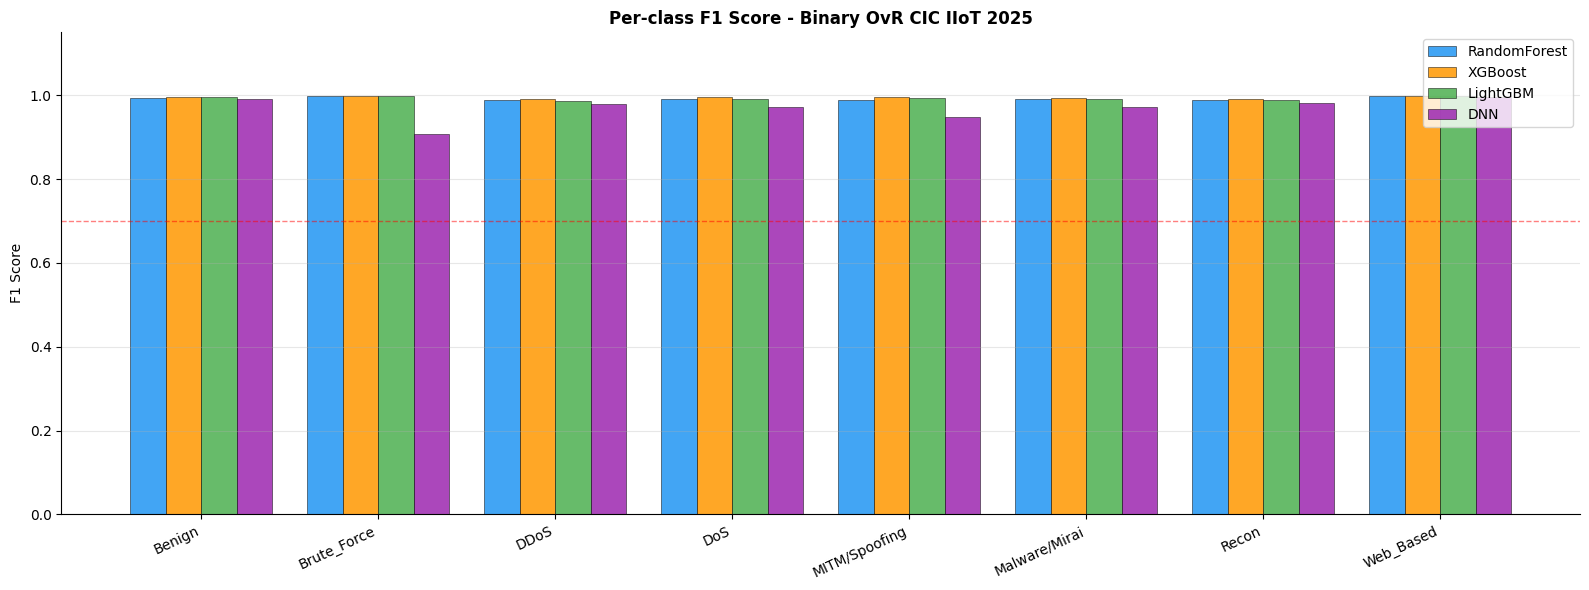

  Figure 1 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/Langkah10B_F1_PerKelas_Grouped.png


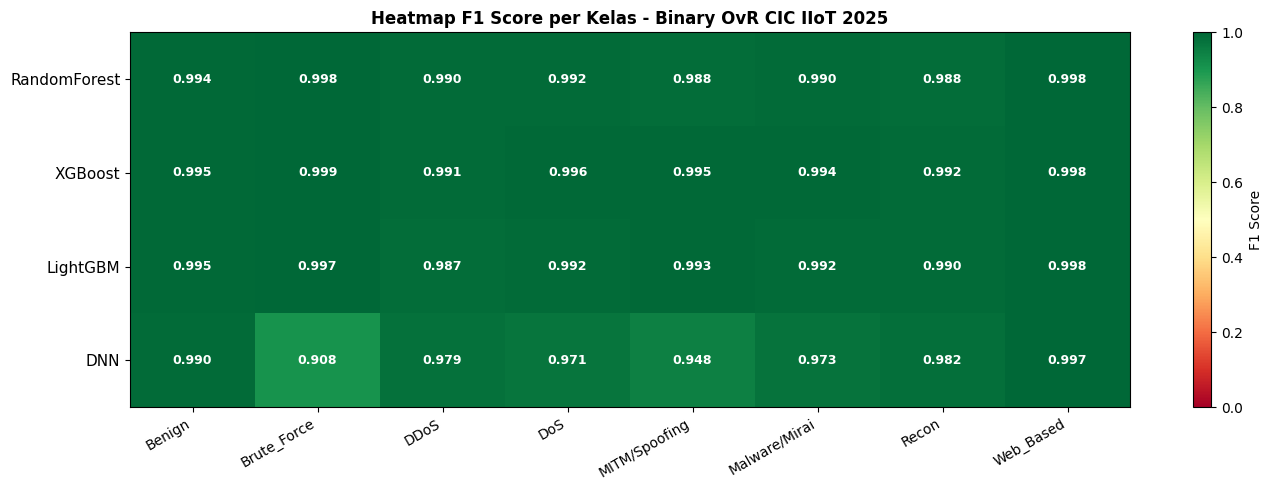

  Figure 2 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/Langkah10B_Heatmap_F1.png


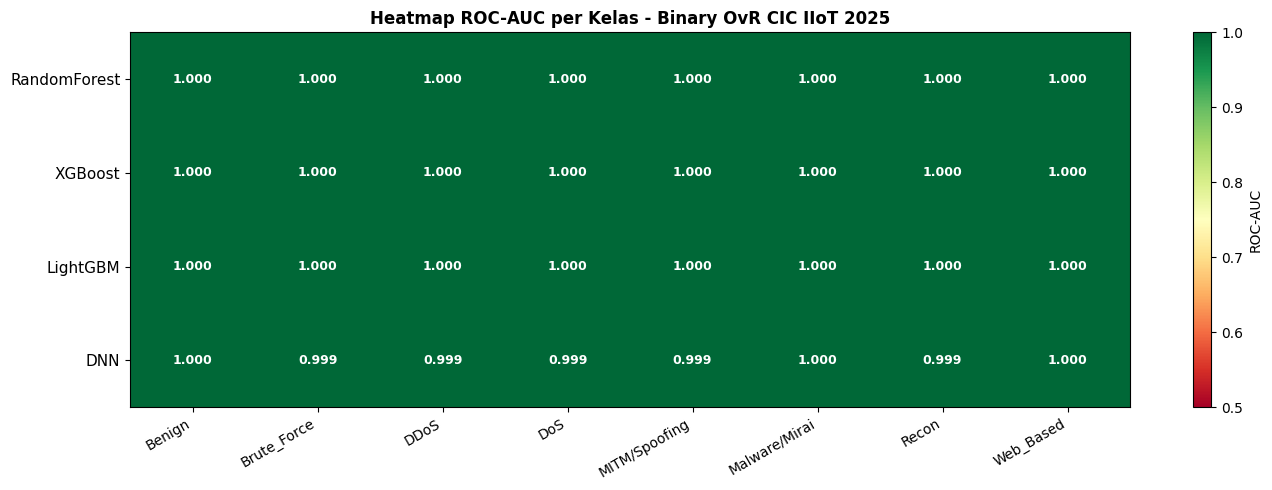

  Figure 3 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/Langkah10B_Heatmap_ROCAUC.png


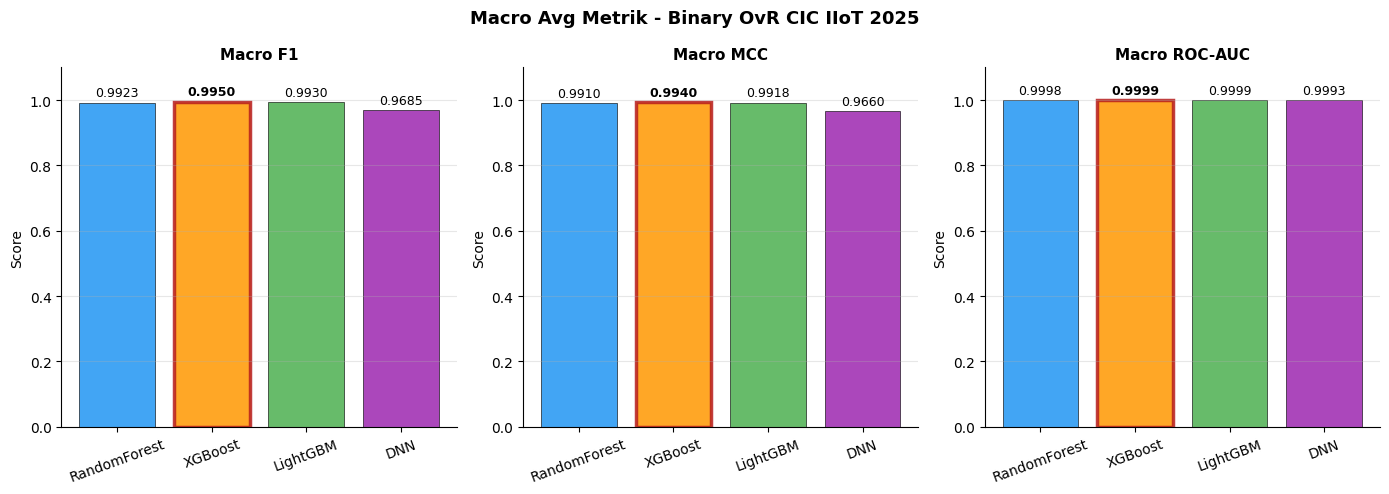

  Figure 4 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/Langkah10B_MacroAvg_Permodel.png


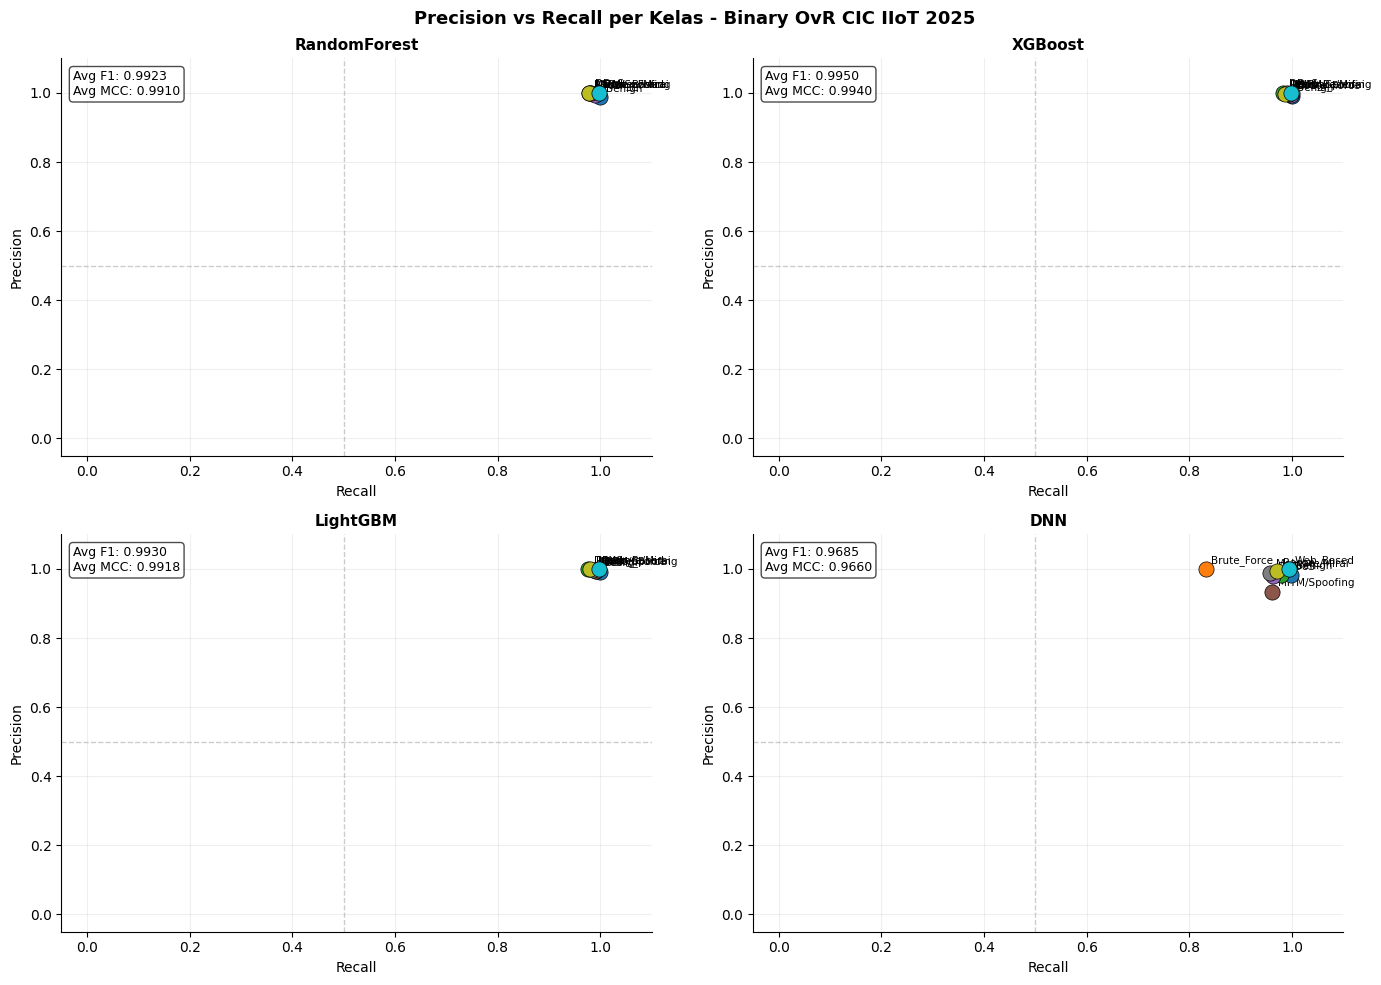

  Figure 5 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/Visualizations/Langkah10B_Precision_Recall_Scatter.png


In [ ]:
colors_model = {
    'RandomForest': '#2196F3',
    'XGBoost'     : '#FF9800',
    'LightGBM'    : '#4CAF50',
    'DNN'         : '#9C27B0',
}

# Figure 1: F1 per kelas grouped bar
fig1, ax1 = plt.subplots(figsize=(16, 6))
x      = np.arange(N_CLASSES)
width  = 0.2
offset = np.linspace(-1.5, 1.5, len(model_names_bin)) * width

for i, m in enumerate(model_names_bin):
    f1_vals = [binary_results[m][c]['f1'] for c in label_list]
    bars    = ax1.bar(x + offset[i], f1_vals, width,
                      label=m, color=colors_model[m],
                      edgecolor='black', linewidth=0.4, alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(label_list, rotation=25, ha='right', fontsize=10)
ax1.set_ylabel('F1 Score')
ax1.set_ylim(0, 1.15)
ax1.set_title('Per-class F1 Score - Binary OvR CIC IIoT 2025',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
path_fig1 = BINARY_VIZ_DIR_IIOT + 'Langkah10B_F1_PerKelas_Grouped.png'
plt.savefig(path_fig1, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 1 tersimpan: {path_fig1}")

# Figure 2: Heatmap F1 per kelas vs model
f1_mat = np.zeros((len(model_names_bin), N_CLASSES))
for i, m in enumerate(model_names_bin):
    for j, c in enumerate(label_list):
        f1_mat[i, j] = binary_results[m][c]['f1']

fig2, ax2 = plt.subplots(figsize=(14, 5))
im2 = ax2.imshow(f1_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax2.set_xticks(range(N_CLASSES))
ax2.set_yticks(range(len(model_names_bin)))
ax2.set_xticklabels(label_list, rotation=30, ha='right', fontsize=10)
ax2.set_yticklabels(model_names_bin, fontsize=11)
ax2.set_title('Heatmap F1 Score per Kelas - Binary OvR CIC IIoT 2025',
              fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='F1 Score')
for i in range(len(model_names_bin)):
    for j in range(N_CLASSES):
        val   = f1_mat[i, j]
        color = 'black' if 0.3 < val < 0.85 else 'white'
        ax2.text(j, i, f'{val:.3f}', ha='center', va='center',
                 fontsize=9, color=color, fontweight='bold')
plt.tight_layout()
path_fig2 = BINARY_VIZ_DIR_IIOT + 'Langkah10B_Heatmap_F1.png'
plt.savefig(path_fig2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 2 tersimpan: {path_fig2}")

# Figure 3: ROC-AUC per kelas
roc_mat = np.zeros((len(model_names_bin), N_CLASSES))
for i, m in enumerate(model_names_bin):
    for j, c in enumerate(label_list):
        roc_mat[i, j] = binary_results[m][c].get('roc_auc', 0) or 0

fig3, ax3 = plt.subplots(figsize=(14, 5))
im3 = ax3.imshow(roc_mat, cmap='RdYlGn', vmin=0.5, vmax=1, aspect='auto')
ax3.set_xticks(range(N_CLASSES))
ax3.set_yticks(range(len(model_names_bin)))
ax3.set_xticklabels(label_list, rotation=30, ha='right', fontsize=10)
ax3.set_yticklabels(model_names_bin, fontsize=11)
ax3.set_title('Heatmap ROC-AUC per Kelas - Binary OvR CIC IIoT 2025',
              fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=ax3, label='ROC-AUC')
for i in range(len(model_names_bin)):
    for j in range(N_CLASSES):
        val   = roc_mat[i, j]
        color = 'black' if val < 0.92 else 'white'
        ax3.text(j, i, f'{val:.3f}', ha='center', va='center',
                 fontsize=9, color=color, fontweight='bold')
plt.tight_layout()
path_fig3 = BINARY_VIZ_DIR_IIOT + 'Langkah10B_Heatmap_ROCAUC.png'
plt.savefig(path_fig3, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 3 tersimpan: {path_fig3}")

# Figure 4: Macro avg per model (bar)
fig4, axes4 = plt.subplots(1, 3, figsize=(14, 5))
fig4.suptitle('Macro Avg Metrik - Binary OvR CIC IIoT 2025',
              fontsize=13, fontweight='bold')

avg_metrics = {
    'Macro F1'   : [np.mean([binary_results[m][c]['f1']  for c in label_list]) for m in model_names_bin],
    'Macro MCC'  : [np.mean([binary_results[m][c]['mcc'] for c in label_list]) for m in model_names_bin],
    'Macro ROC-AUC': [np.mean([binary_results[m][c].get('roc_auc', 0) or 0 for c in label_list])
                      for m in model_names_bin],
}
bar_colors = [colors_model[m] for m in model_names_bin]

for ax, (metric_name, vals) in zip(axes4, avg_metrics.items()):
    bars = ax.bar(model_names_bin, vals, color=bar_colors,
                  edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_title(metric_name, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    best_idx = int(np.argmax(vals))
    for i, (bar, val) in enumerate(zip(bars, vals)):
        fw = 'bold' if i == best_idx else 'normal'
        bar.set_edgecolor('#B71C1C' if i == best_idx else 'black')
        bar.set_linewidth(2.5 if i == best_idx else 0.5)
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight=fw)
plt.tight_layout()
path_fig4 = BINARY_VIZ_DIR_IIOT + 'Langkah10B_MacroAvg_Permodel.png'
plt.savefig(path_fig4, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 4 tersimpan: {path_fig4}")

# Figure 5: Precision vs Recall scatter per model
fig5, axes5 = plt.subplots(2, 2, figsize=(14, 10))
fig5.suptitle('Precision vs Recall per Kelas - Binary OvR CIC IIoT 2025',
              fontsize=13, fontweight='bold')
class_colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, N_CLASSES))

for ax, m in zip(axes5.flatten(), model_names_bin):
    for j, class_name in enumerate(label_list):
        res  = binary_results[m][class_name]
        prec = res['precision']
        rec  = res['recall']
        ax.scatter(rec, prec, color=class_colors[j], s=120,
                   zorder=5, edgecolors='black', linewidths=0.5)
        ax.annotate(class_name, xy=(rec, prec),
                    xytext=(4, 4), textcoords='offset points', fontsize=7.5)
    ax.set_xlabel('Recall',    fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title(m, fontsize=11, fontweight='bold')
    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    avg_f1 = np.mean([binary_results[m][c]['f1'] for c in label_list])
    avg_mcc = np.mean([binary_results[m][c]['mcc'] for c in label_list])
    ax.text(0.02, 0.97, f'Avg F1: {avg_f1:.4f}\nAvg MCC: {avg_mcc:.4f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
path_fig5 = BINARY_VIZ_DIR_IIOT + 'Langkah10B_Precision_Recall_Scatter.png'
plt.savefig(path_fig5, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 5 tersimpan: {path_fig5}")

# Figure 6: Framework vs Baseline Binary (jika ada)
if has_baseline_bin:
    fig6, axes6 = plt.subplots(2, 4, figsize=(20, 10))
    fig6.suptitle('Framework vs Baseline - Binary OvR per Kelas CIC IIoT 2025',
                  fontsize=13, fontweight='bold')
    axes6_flat = axes6.flatten()
    x6   = np.arange(len(model_names_bin))
    w6   = 0.35
    for ax, class_name in zip(axes6_flat, label_list):
        base_vals = [baseline_binary.get(m, {}).get(class_name, {}).get('f1', 0)
                     for m in model_names_bin]
        fw_vals   = [binary_results[m][class_name]['f1'] for m in model_names_bin]
        b1 = ax.bar(x6 - w6/2, base_vals, w6, label='Baseline',
                    color='#90A4AE', edgecolor='black', linewidth=0.4, alpha=0.85)
        b2 = ax.bar(x6 + w6/2, fw_vals,   w6, label='Framework',
                    color='#1565C0', edgecolor='black', linewidth=0.4, alpha=0.85)
        ax.set_title(class_name, fontsize=10, fontweight='bold')
        ax.set_xticks(x6)
        ax.set_xticklabels([m[:3] for m in model_names_bin], fontsize=8)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel('F1')
        ax.legend(fontsize=7)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for bar, val in zip(b1, base_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)
        for bar, val in zip(b2, fw_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7,
                    fontweight='bold')
    plt.tight_layout()
    path_fig6 = BINARY_VIZ_DIR_IIOT + 'Langkah10B_Framework_vs_Baseline.png'
    plt.savefig(path_fig6, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Figure 6 tersimpan: {path_fig6}")

####**10.7 Simpan Laporan Evaluasi Binary Final**

In [ ]:
best_per_class_bin = {}
for class_name in label_list:
    best_model = max(model_names_bin,
                     key=lambda m: binary_results[m][class_name]['f1'])
    best_per_class_bin[class_name] = {
        'best_model': best_model,
        'f1'        : binary_results[best_model][class_name]['f1'],
        'mcc'       : binary_results[best_model][class_name]['mcc'],
    }

eval_report_bin = {
    'dataset'             : 'CIC IIoT 2025',
    'pendekatan'          : 'Binary One vs Rest (OvR)',
    'n_test_samples'      : int(len(y_test)),
    'n_classes'           : N_CLASSES,
    'label_list'          : label_list,
    'model_results'       : binary_results,
    'best_per_class'      : best_per_class_bin,
    'difficult_classes'   : [
        {'kelas': name, 'avg_f1': round(avg, 4)}
        for name, avg in difficult_bin
    ] if difficult_bin else [],
    'macro_avg_per_model' : {
        m: {
            'macro_f1'  : round(np.mean([binary_results[m][c]['f1']  for c in label_list]), 4),
            'macro_mcc' : round(np.mean([binary_results[m][c]['mcc'] for c in label_list]), 4),
            'macro_roc' : round(np.mean([binary_results[m][c].get('roc_auc', 0) or 0
                                         for c in label_list]), 4),
        }
        for m in model_names_bin
    },
    'has_baseline_comparison': has_baseline_bin,
}

report_path_bin = os.path.join(BINARY_RESULTS_DIR_IIOT,
                               'langkah10_binary_evaluation_report.json')
with open(report_path_bin, 'w') as f:
    json.dump(eval_report_bin, f, indent=4)
print(f"  Laporan JSON tersimpan: {report_path_bin}")

# Simpan full CSV
rows_bin = []
for m in model_names_bin:
    for class_name in label_list:
        res = binary_results[m][class_name]
        rows_bin.append({
            'Model'      : m,
            'Kelas'      : class_name,
            'Precision'  : res['precision'],
            'Recall'     : res['recall'],
            'F1'         : res['f1'],
            'MCC'        : res['mcc'],
            'ROC-AUC'    : res.get('roc_auc', None),
            'Accuracy'   : res['accuracy'],
            'Support Pos': res['support_pos'],
            'Support Neg': res['support_neg'],
            'Train Time(s)': res.get('train_time_s', None),
        })

df_bin_full = pd.DataFrame(rows_bin)
full_csv_bin = os.path.join(BINARY_RESULTS_DIR_IIOT,
                            'langkah10_binary_full_metrics.csv')
df_bin_full.to_csv(full_csv_bin, index=False)
print(f"  Full metrics CSV tersimpan: {full_csv_bin}")

  Laporan JSON tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/langkah10_binary_evaluation_report.json
  Full metrics CSV tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Binary/Results/langkah10_binary_full_metrics.csv


####**10.8 Ringkasan Final Binary**

In [ ]:
print(f"Dataset    : CIC IIoT 2025")
print(f"  Pendekatan : Binary One vs Rest (OvR)")
print(f"  Test set   : {len(y_test):,} samples")
print(f"  Total model: {N_CLASSES * len(model_names_bin)}")

print(f"\n  Macro Avg per Model:")
print(f"\n  {'Model':<14} {'Macro F1':>10} {'Macro MCC':>11} {'Macro ROC-AUC':>14}")
print(f"  {'-'*52}")
for m in model_names_bin:
    avg_f1  = np.mean([binary_results[m][c]['f1']  for c in label_list])
    avg_mcc = np.mean([binary_results[m][c]['mcc'] for c in label_list])
    avg_roc = np.mean([binary_results[m][c].get('roc_auc', 0) or 0
                       for c in label_list])
    print(f"  {m:<14} {avg_f1:>10.4f} {avg_mcc:>11.4f} {avg_roc:>14.4f}")
print(f"  {'-'*52}")

print(f"\n  Model terbaik per kelas (berdasarkan F1):")
for class_name in label_list:
    best = best_per_class_bin[class_name]
    print(f"    {class_name:<20} : {best['best_model']:<14} (F1={best['f1']:.4f})")

if difficult_bin:
    print(f"\n  Kelas yang masih perlu perhatian (avg F1 < 0.7):")
    for name, avg in sorted(difficult_bin, key=lambda x: x[1]):
        print(f"    {name:<20} : avg F1 = {avg:.4f}")

print(f"\n  File tersimpan di {BINARY_RESULTS_DIR_IIOT}:")
for fname in [
    'langkah9_binary_results.json',
    'langkah9_binary_summary.csv',
    'langkah10_binary_evaluation_report.json',
    'langkah10_binary_full_metrics.csv',
]:
    fpath = os.path.join(BINARY_RESULTS_DIR_IIOT, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024**2
        print(f"    {fname:<45} ({size:.2f} MB)")

print(f"\n  Visualisasi tersimpan di {BINARY_VIZ_DIR_IIOT}:")
viz_files_bin = [
    'Langkah10B_F1_PerKelas_Grouped.png',
    'Langkah10B_Heatmap_F1.png',
    'Langkah10B_Heatmap_ROCAUC.png',
    'Langkah10B_MacroAvg_Permodel.png',
    'Langkah10B_Precision_Recall_Scatter.png',
]
if has_baseline_bin:
    viz_files_bin.append('Langkah10B_Framework_vs_Baseline.png')
for fname in viz_files_bin:
    fpath = os.path.join(BINARY_VIZ_DIR_IIOT, fname)
    if os.path.exists(fpath):
        print(f"    {fname}")

mem = psutil.virtual_memory()
print(f"\n  RAM tersisa: {mem.available / 1024**3:.2f} GB")
gc.collect()

print("\n  Seluruh pipeline CIC IIoT 2025 selesai.")
print("  Multiclass + Binary OvR keduanya sudah selesai.")
print("=" * 75)

Dataset    : CIC IIoT 2025
  Pendekatan : Binary One vs Rest (OvR)
  Test set   : 45,319 samples
  Total model: 32

  Macro Avg per Model:

  Model            Macro F1   Macro MCC  Macro ROC-AUC
  ----------------------------------------------------
  RandomForest       0.9923      0.9910         0.9998
  XGBoost            0.9950      0.9940         0.9999
  LightGBM           0.9930      0.9918         0.9999
  DNN                0.9685      0.9660         0.9993
  ----------------------------------------------------

  Model terbaik per kelas (berdasarkan F1):
    Benign               : LightGBM       (F1=0.9951)
    Brute_Force          : XGBoost        (F1=0.9991)
    DDoS                 : XGBoost        (F1=0.9908)
    DoS                  : XGBoost        (F1=0.9955)
    MITM/Spoofing        : XGBoost        (F1=0.9953)
    Malware/Mirai        : XGBoost        (F1=0.9938)
    Recon                : XGBoost        (F1=0.9918)
    Web_Based            : RandomForest   (F1=0.9984